# Aliyun Manual Scenarios step-by-step

This notebook walks through:
1) load manual scenarios as true graphs (each scenario is an assessor)
2) load expert/model traces as observations
3) build HPO inputs (multi-assessor)
4) run MCMC and evaluate against the true graphs


In [1]:
# Bootstrap: locate project root and add it to sys.path
import sys
import pkgutil
from pathlib import Path

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root from {current_dir}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

src_dir = project_root / "src"
utils_dir = src_dir / "utils"
if not utils_dir.is_dir():
    raise FileNotFoundError(f"Expected utils package at {utils_dir}")

print("Project root:", project_root)
print("src package found?", pkgutil.find_loader("src") is not None)


Project root: /Users/dongqing/Desktop/hpo_inference_agent
src package found? True


In [2]:
import json
from typing import Dict, List, Any, Tuple

import numpy as np

from src.utils.po_fun import BasicUtils, StatisticalUtils
from src.utils.hpo_model_evaluation import precision_recall, f1_score, structural_hamming_distance
from src.mcmc.hpo_po_hm_mcmc_k_optim import mcmc_simulation_hpo_k_optim
from src.utils.po_fun_plot import PO_plot



In [3]:
from src.utils.cloud_iac_dataset import (
    resolve_cloud_iac_data_root,
    resolve_cloud_iac_ground_truth_dir,
)

data_root = resolve_cloud_iac_data_root(project_root)
manual_dir = resolve_cloud_iac_ground_truth_dir(data_root)
expert_dir = data_root / "expert_traces"
trace_dir = data_root / "traces"


def load_manual_scenarios(path: Path) -> Dict[str, Dict[str, Any]]:
    scenarios = {}
    for p in sorted(path.glob("*.json")):
        scenarios[p.stem] = json.loads(p.read_text())
    return scenarios


scenarios = load_manual_scenarios(manual_dir)
print("manual scenarios:", sorted(scenarios.keys()))


manual scenarios: ['dual_zone_ecs_slb', 'dual_zone_ecs_slb_rds', 'eip_slb_ecs', 'simple_ecs', 'slb_ecs_rds', 'slb_ecs_redis']


assessors (scenario ids): ['dual_zone_ecs_slb', 'dual_zone_ecs_slb_rds', 'eip_slb_ecs', 'simple_ecs', 'slb_ecs_rds', 'slb_ecs_redis']
global tasks: 16
dual_zone_ecs_slb: tasks=7 edges=8


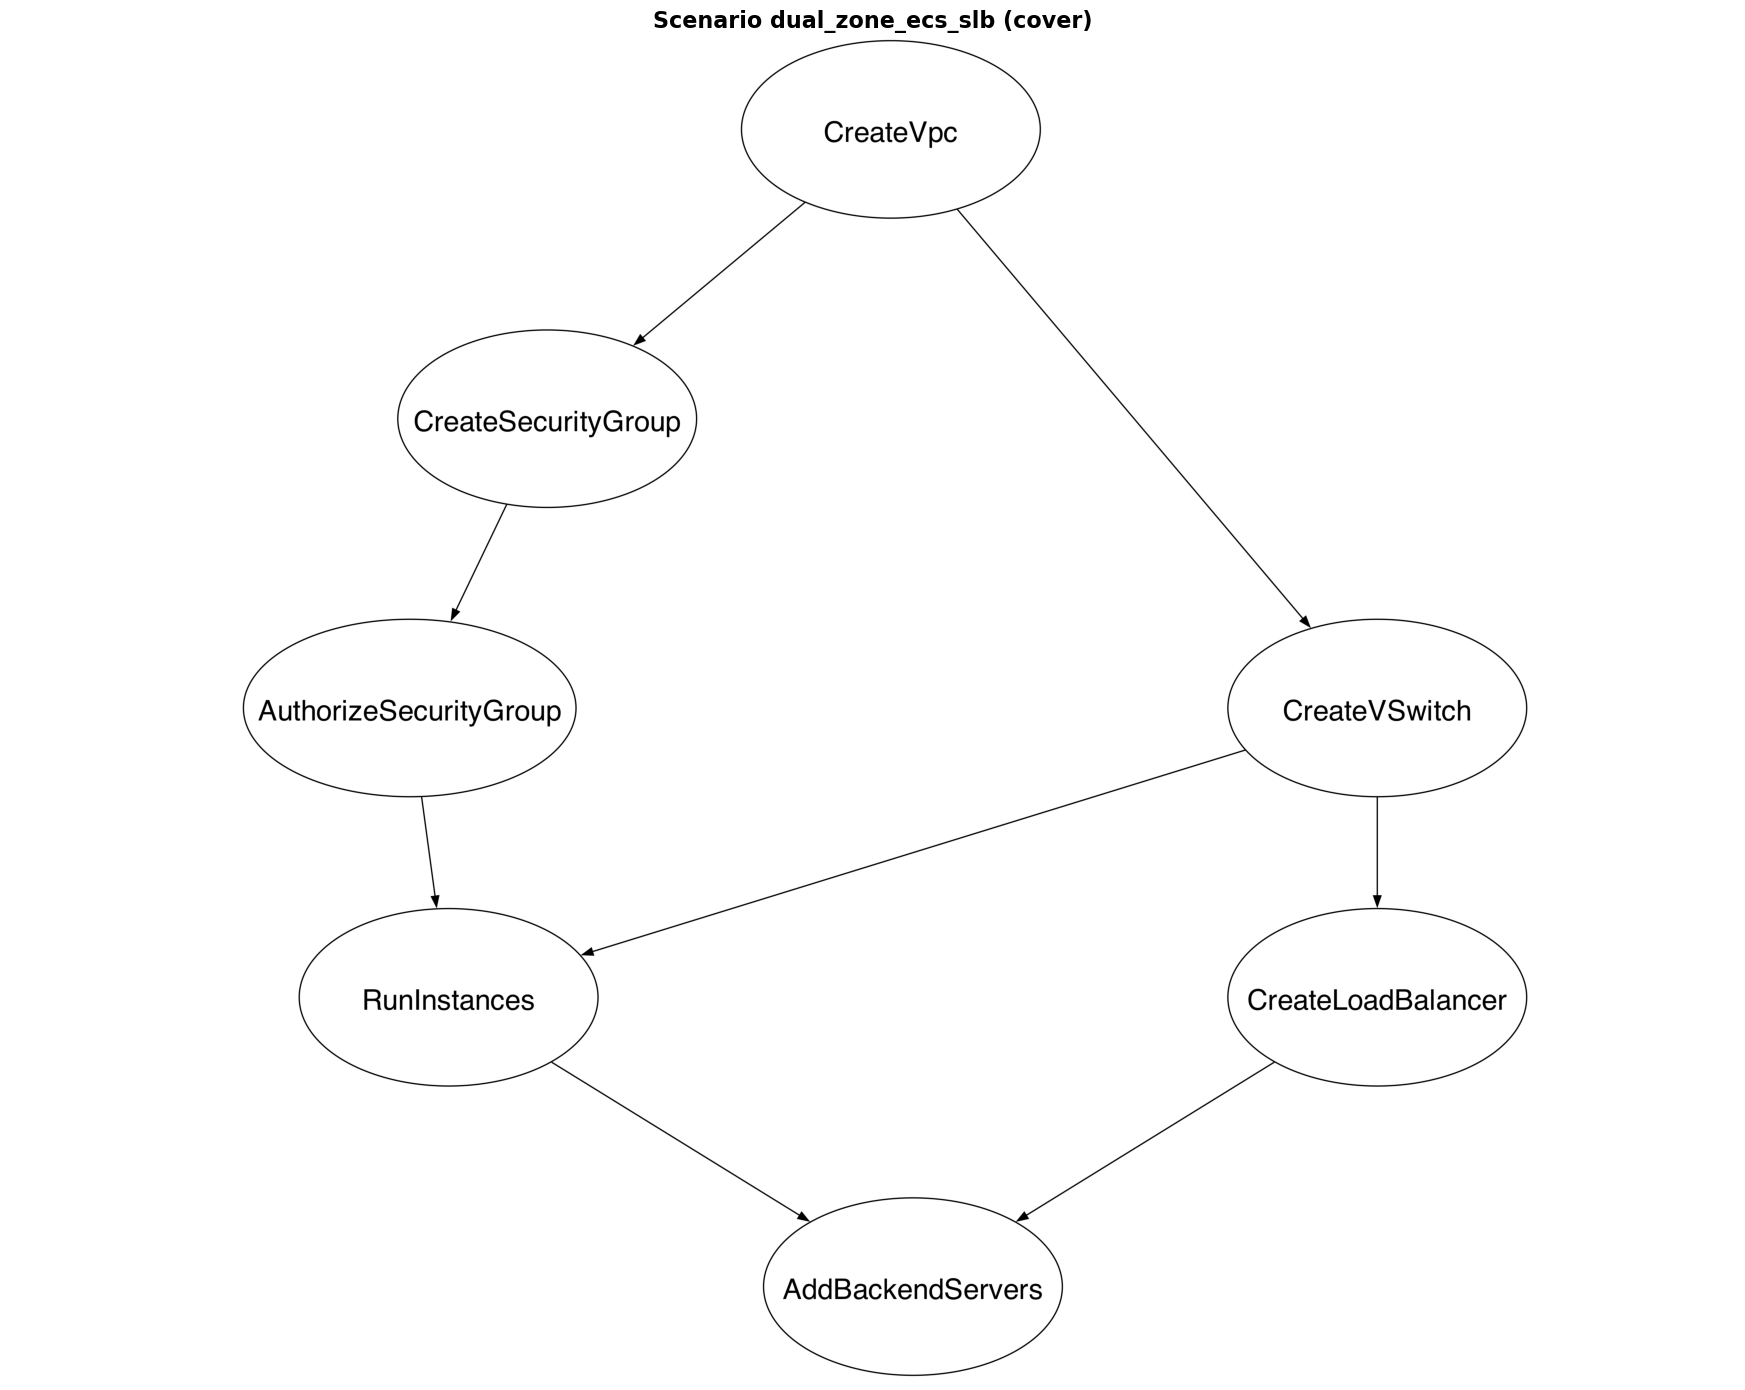

dual_zone_ecs_slb_rds: tasks=10 edges=12


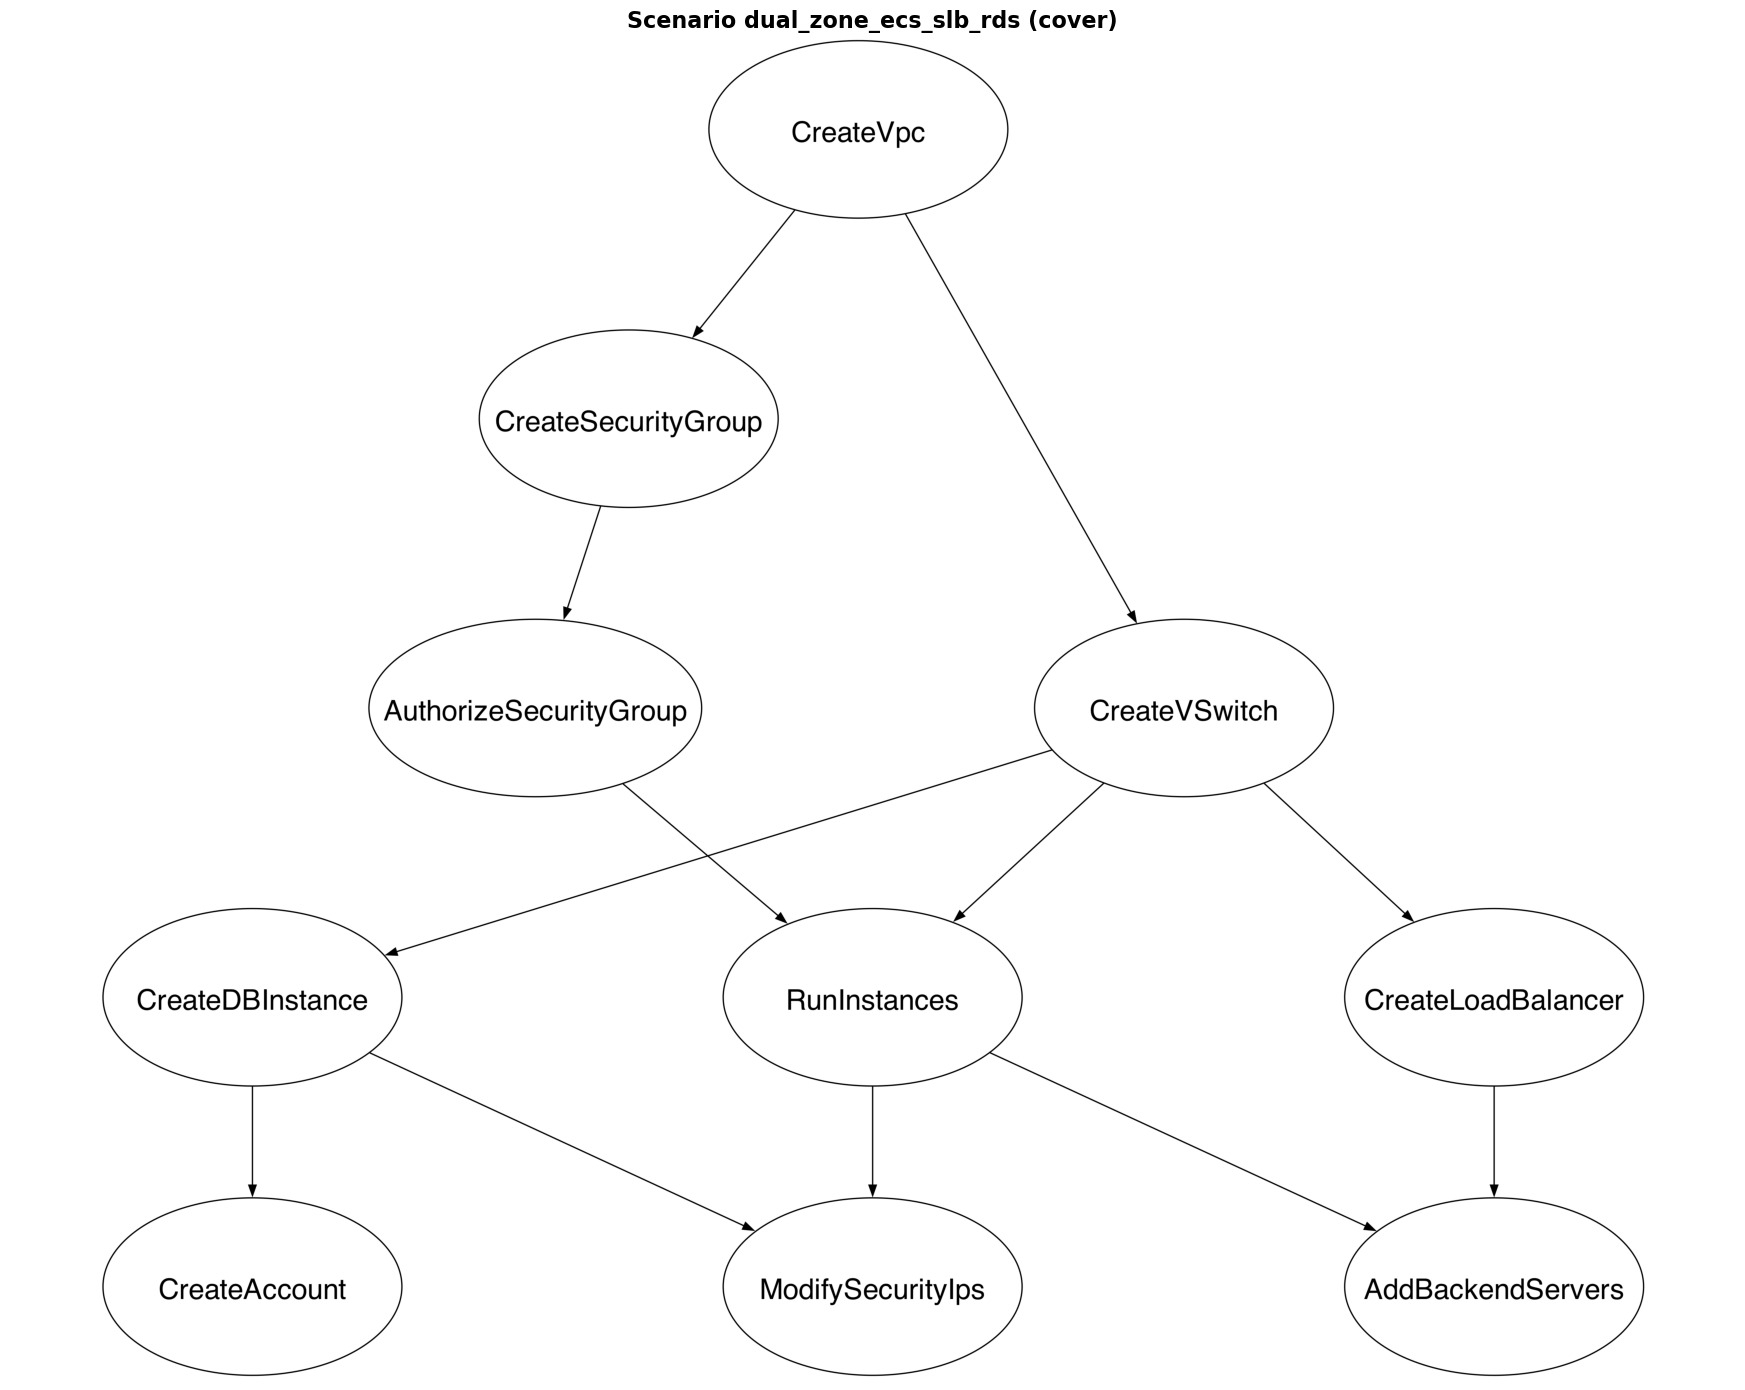

eip_slb_ecs: tasks=9 edges=10


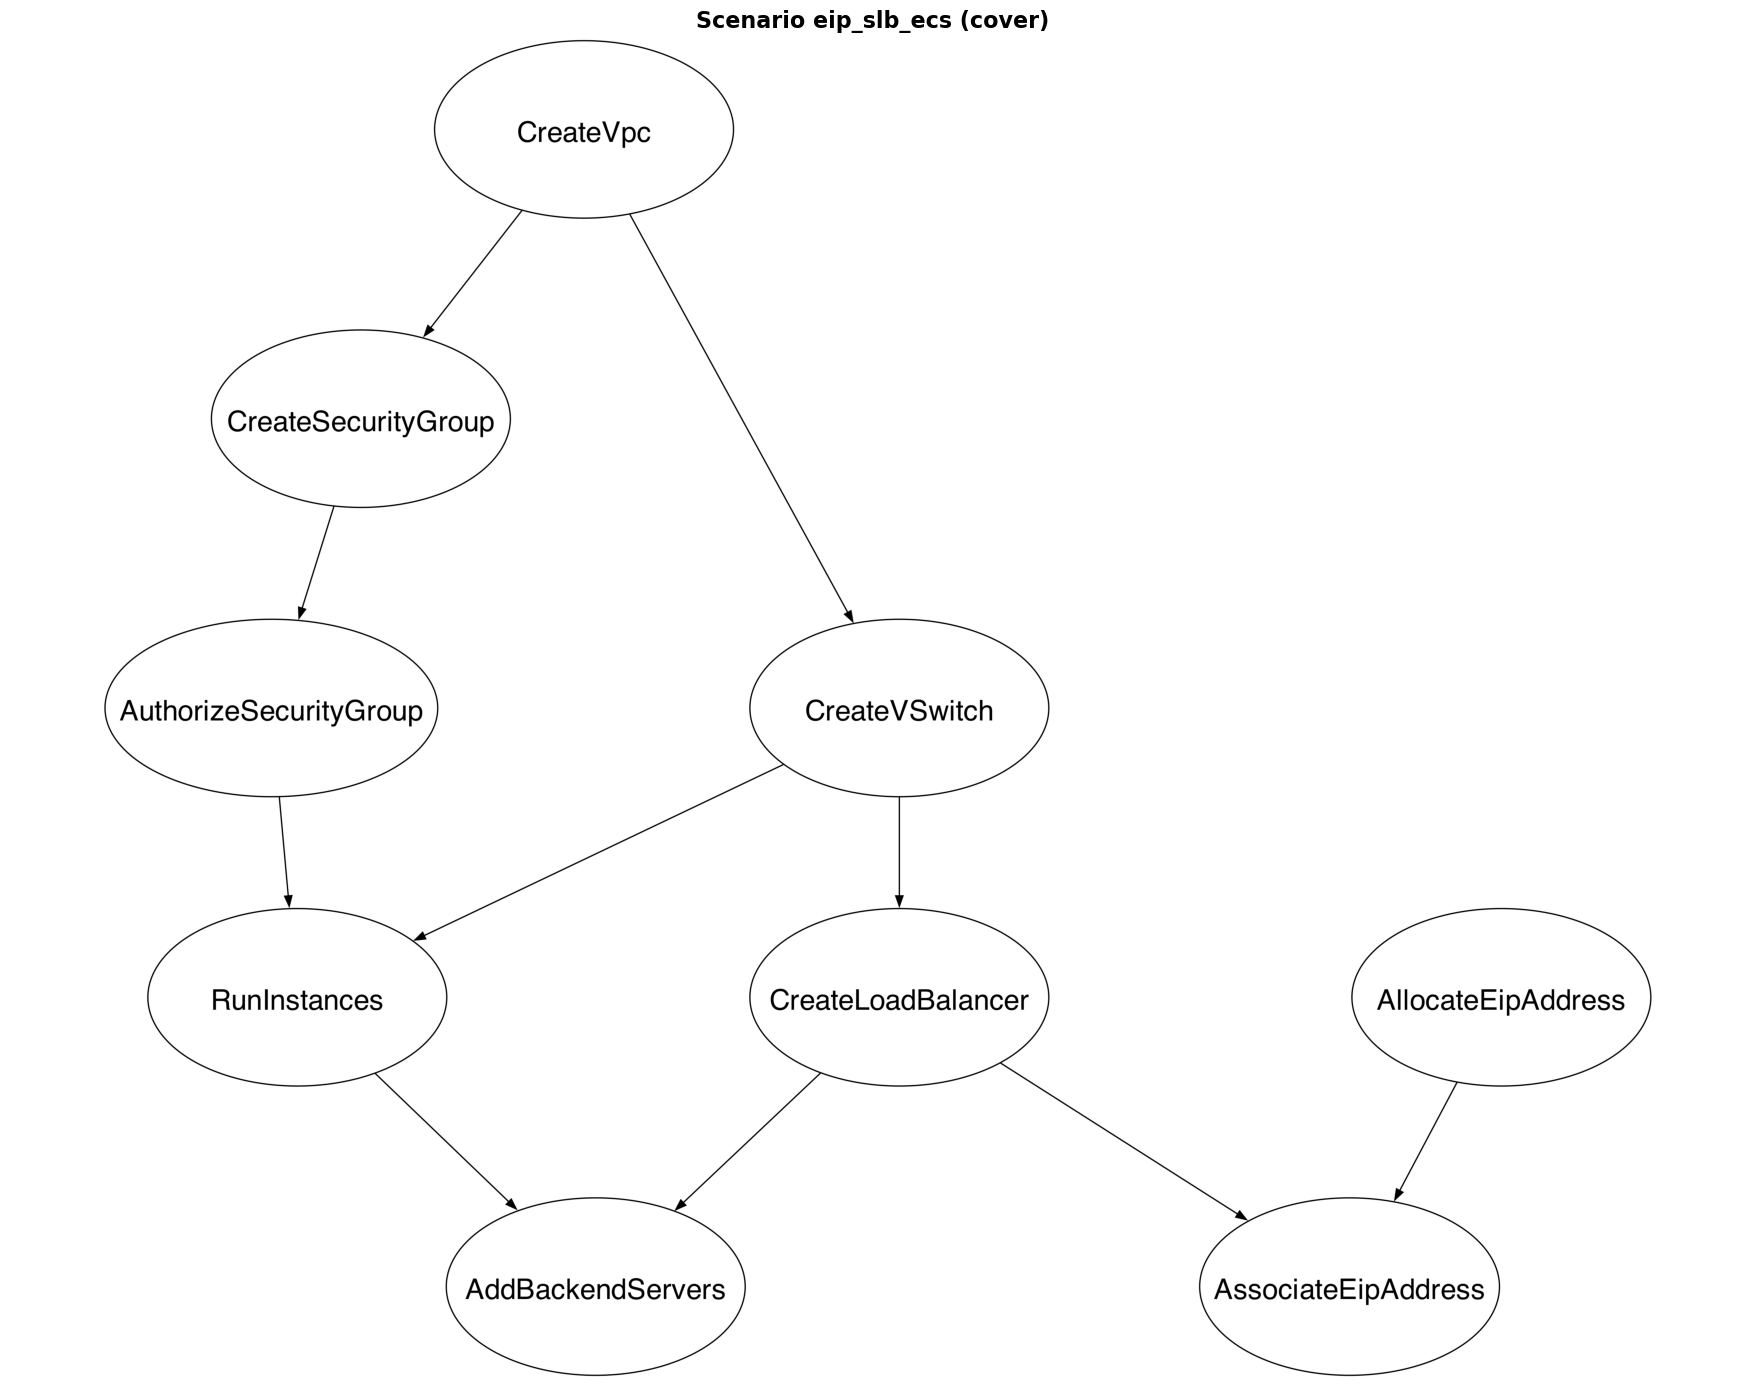

simple_ecs: tasks=5 edges=5


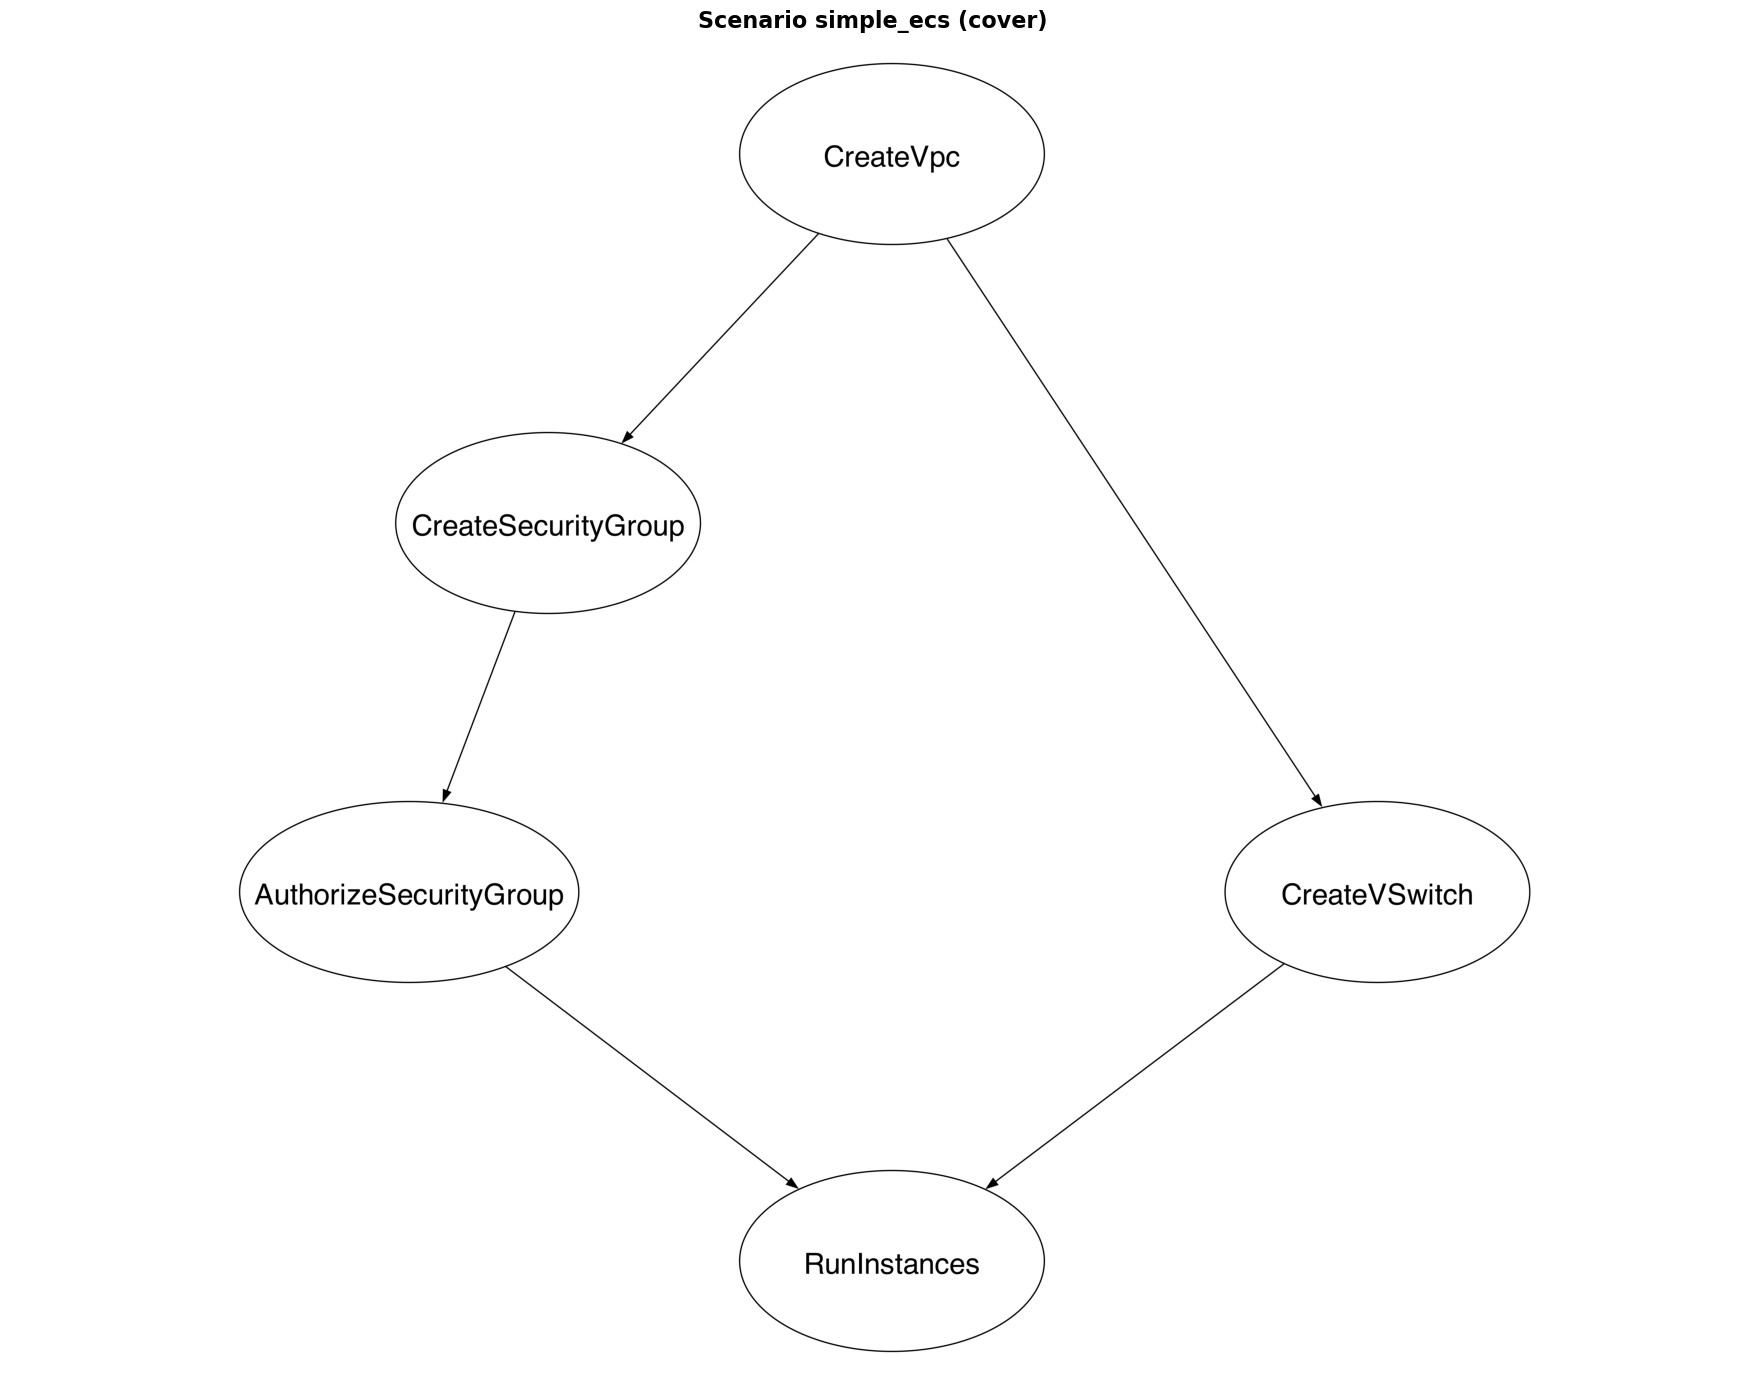

slb_ecs_rds: tasks=12 edges=14


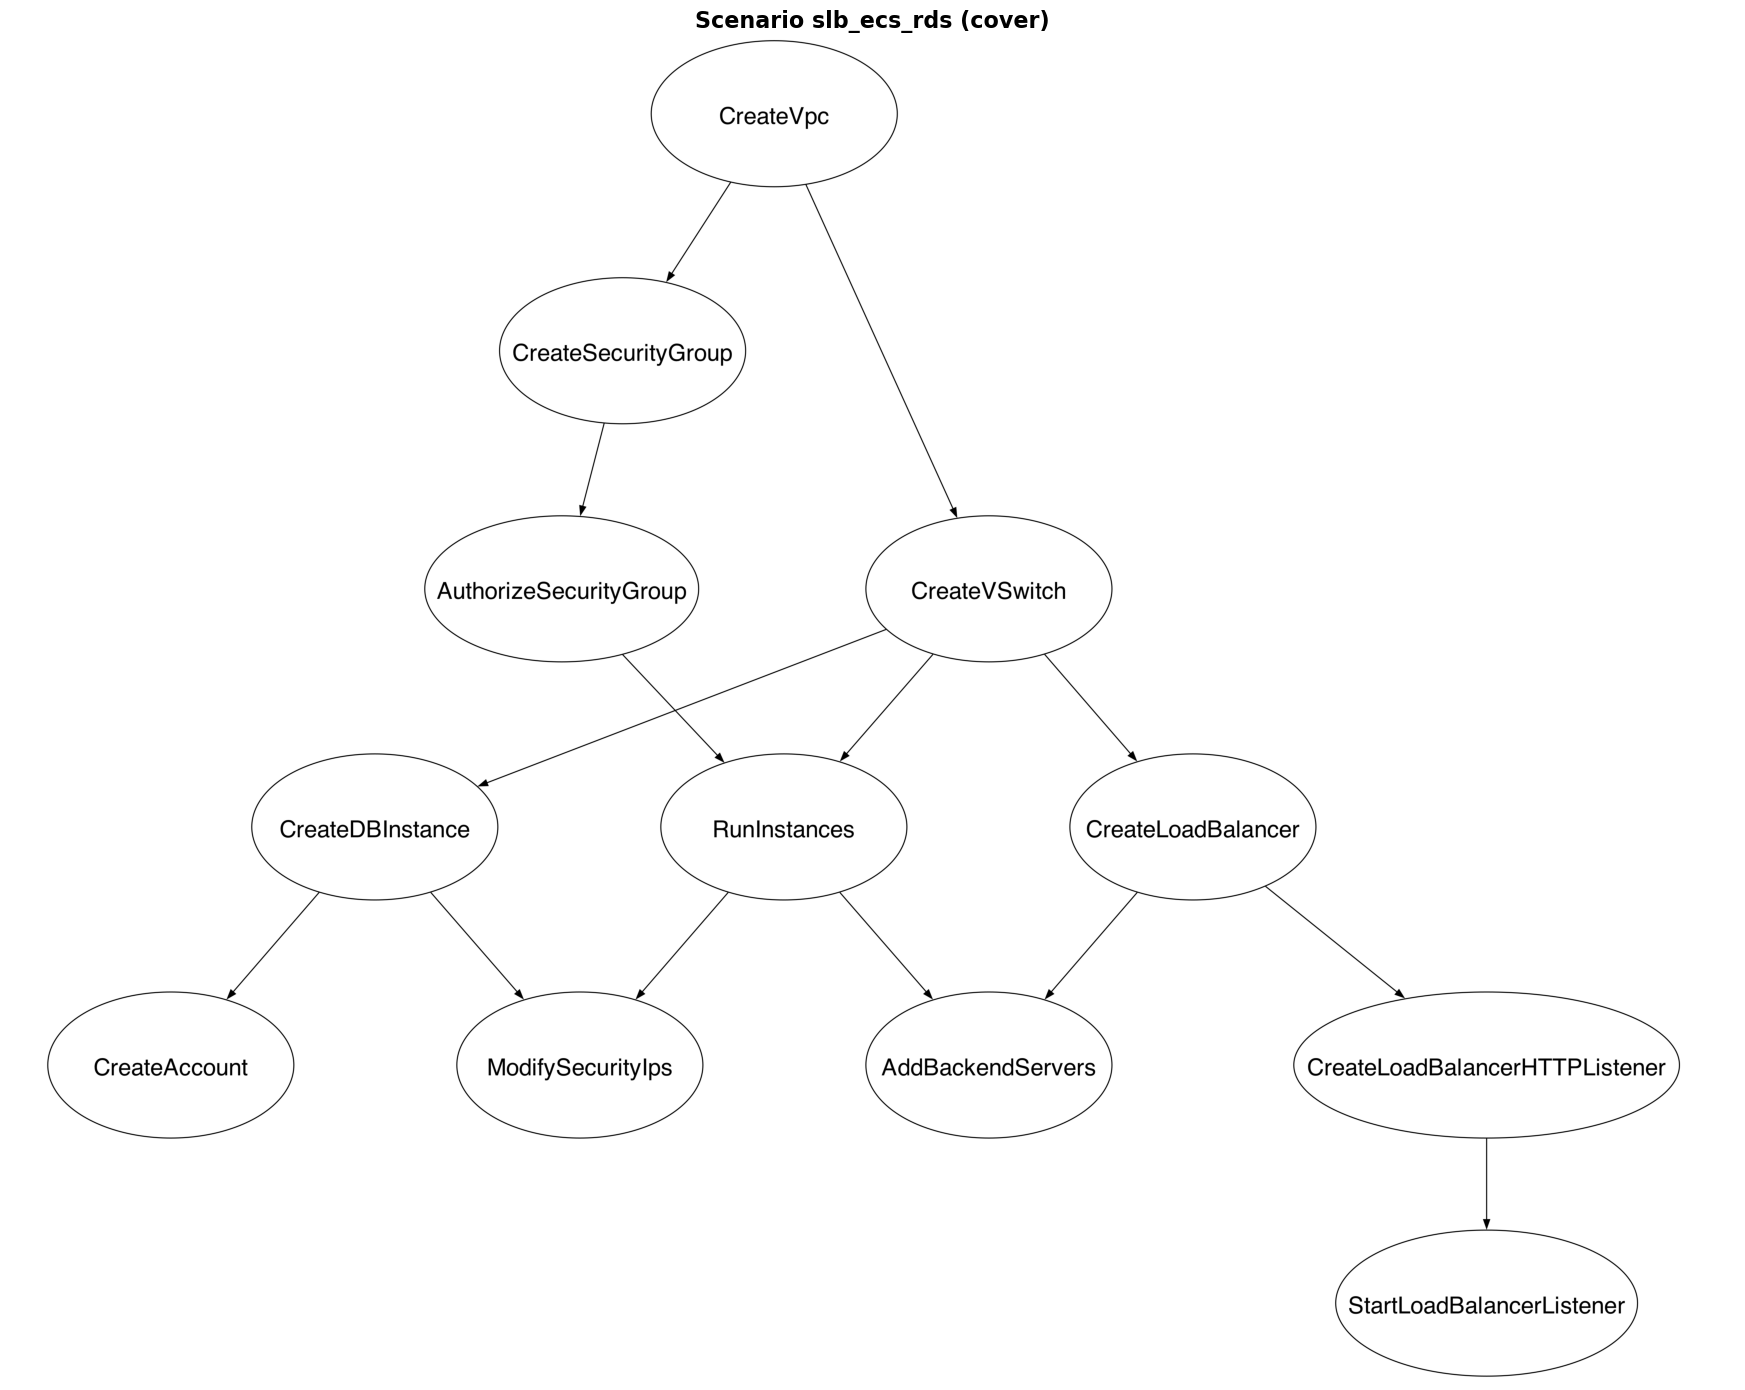

slb_ecs_redis: tasks=9 edges=10


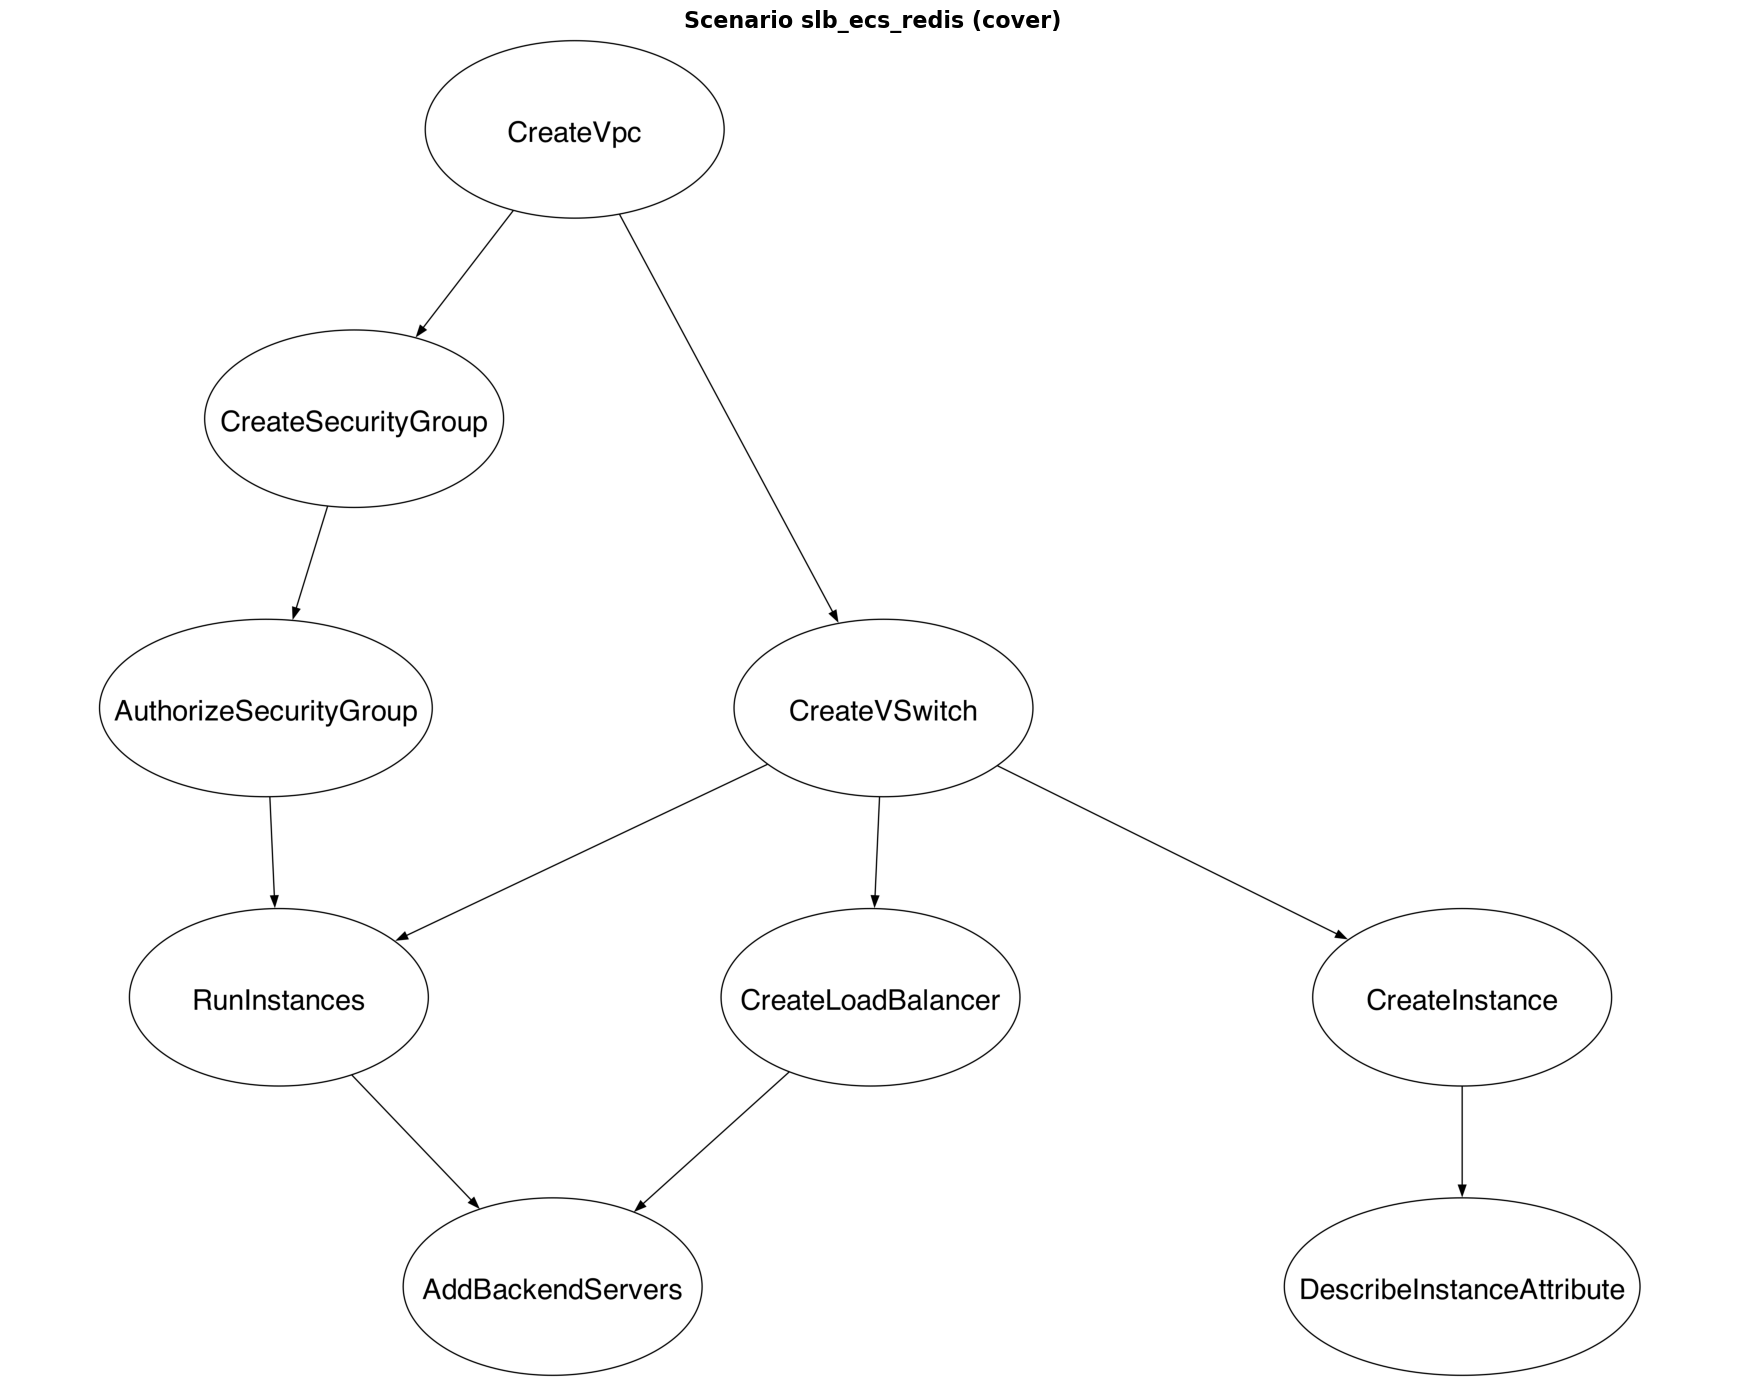

In [4]:
%matplotlib inline
# Build per-scenario true graphs (each scenario is an assessor)
scenario_ids = sorted(scenarios.keys())
assessors = list(scenario_ids)


def scenario_to_adj(scenario: Dict[str, Any]) -> Tuple[np.ndarray, List[str], Dict[str, int]]:
    edges = scenario.get("edges", [])
    tasks = sorted({t for edge in edges for t in edge})
    task_to_idx = {t: i for i, t in enumerate(tasks)}
    adj = np.zeros((len(tasks), len(tasks)), dtype=np.int8)
    for parent, child in edges:
        if parent in task_to_idx and child in task_to_idx:
            adj[task_to_idx[parent], task_to_idx[child]] = 1
    return adj, tasks, task_to_idx


scenario_data = {}
all_tasks = set()

for scenario_id in scenario_ids:
    scenario = scenarios[scenario_id]
    true_adj, task_ids, task_to_idx = scenario_to_adj(scenario)
    true_closure = BasicUtils.transitive_closure(true_adj.astype(np.int8))
    true_cover = BasicUtils.transitive_reduction_optimized(true_closure.astype(np.int8))

    scenario_data[scenario_id] = {
        "scenario": scenario,
        "task_ids": task_ids,
        "task_to_idx": task_to_idx,
        "true_adj": true_adj,
        "true_closure": true_closure,
        "true_cover": true_cover,
    }
    all_tasks.update(task_ids)

# Global item space (union of all tasks)
global_task_ids = sorted(all_tasks)
global_task_to_idx = {t: i for i, t in enumerate(global_task_ids)}
M0 = list(range(len(global_task_ids)))

# Store true cover matrices in global index space (for evaluation)
true_cover_global = {}
for scenario_id in scenario_ids:
    cover_local = scenario_data[scenario_id]["true_cover"]
    labels_local = scenario_data[scenario_id]["task_ids"]
    cover = np.zeros((len(global_task_ids), len(global_task_ids)), dtype=np.int8)
    for i, src in enumerate(labels_local):
        for j, dst in enumerate(labels_local):
            if cover_local[i, j]:
                cover[global_task_to_idx[src], global_task_to_idx[dst]] = 1
    true_cover_global[scenario_id] = cover

print("assessors (scenario ids):", assessors)
print("global tasks:", len(global_task_ids))
for scenario_id in scenario_ids:
    info = scenario_data[scenario_id]
    print(f"{scenario_id}: tasks={len(info['task_ids'])} edges={int(info['true_adj'].sum())}")
    PO_plot.visualize_partial_order(info["true_cover"], info["task_ids"], title=f"Scenario {scenario_id} (cover)")


In [16]:
def load_traces(dir_path: Path) -> List[Dict[str, Any]]:
    traces = []
    for p in sorted(dir_path.glob("*.json")):
        traces.append(json.loads(p.read_text()))
    return traces


def select_traces(traces: List[Dict[str, Any]], intent_type: str, only_success: bool) -> List[Dict[str, Any]]:
    selected = []
    for trace in traces:
        intent = (trace.get("intent") or {}).get("intent_type")
        if intent_type and intent != intent_type:
            continue
        if only_success and trace.get("status") not in (None, "success"):
            continue
        seq = trace.get("action_sequence") or []
        if not seq:
            continue
        selected.append(trace)
    return selected


def normalize_sequence(
    seq: List[str],
    task_set: set,
    *,
    drop_unknown: bool = True,
    dedup: bool = True,
) -> List[str]:
    out = []
    seen = set()
    for action in seq:
        if drop_unknown and action not in task_set:
            continue
        if dedup and action in seen:
            continue
        seen.add(action)
        out.append(action)
    return out


expert_traces = load_traces(expert_dir)
model_traces = load_traces(trace_dir)

TRACE_SOURCE = "combined"  # expert | model | combined
ONLY_SUCCESS = True
DROP_UNKNOWN_ACTIONS = True
DEDUP_ACTIONS = True

orders_by_assessor = {}
orders_local_by_assessor = {}
choice_sets_by_assessor = {}
trace_meta_by_assessor = {}

for scenario_id in scenario_ids:
    task_ids = scenario_data[scenario_id]["task_ids"]
    task_set = set(task_ids)
    local_task_to_idx = scenario_data[scenario_id]["task_to_idx"]

    selected_traces = []
    if TRACE_SOURCE in ("expert", "combined"):
        selected_traces.extend(select_traces(expert_traces, scenario_id, ONLY_SUCCESS))
    if TRACE_SOURCE in ("model", "combined"):
        selected_traces.extend(select_traces(model_traces, scenario_id, ONLY_SUCCESS))

    orders_global = []
    orders_local = []
    choice_sets = []
    trace_meta = []

    for trace in selected_traces:
        raw_seq = trace.get("action_sequence") or []
        norm = normalize_sequence(
            raw_seq,
            task_set,
            drop_unknown=DROP_UNKNOWN_ACTIONS,
            dedup=DEDUP_ACTIONS,
        )
        if not norm:
            continue
        order_global = [global_task_to_idx[action] for action in norm]
        order_local = [local_task_to_idx[action] for action in norm]
        orders_global.append(order_global)
        orders_local.append(order_local)
        choice_sets.append(sorted(set(order_global)))
        trace_meta.append(
            {
                "trace_id": trace.get("trace_id"),
                "intent_type": (trace.get("intent") or {}).get("intent_type"),
                "source_mode": trace.get("mode"),
                "raw_length": len(raw_seq),
                "used_length": len(order_global),
            }
        )

    if orders_global:
        orders_by_assessor[scenario_id] = orders_global
        orders_local_by_assessor[scenario_id] = orders_local
        choice_sets_by_assessor[scenario_id] = choice_sets
        trace_meta_by_assessor[scenario_id] = trace_meta

original_trace_counts = {sid: len(orders_local_by_assessor.get(sid, [])) for sid in scenario_ids}

print("trace_source:", TRACE_SOURCE)
for scenario_id in scenario_ids:
    count = len(orders_by_assessor.get(scenario_id, []))
    print(f"{scenario_id}: traces={count}")


trace_source: combined
dual_zone_ecs_slb: traces=9
dual_zone_ecs_slb_rds: traces=8
eip_slb_ecs: traces=11
simple_ecs: traces=11
slb_ecs_rds: traces=10
slb_ecs_redis: traces=11


### 
calculate the critical paris for each true partial order, and find the 

In [23]:
from typing import Dict, List, Tuple
import numpy as np

def true_critical_pairs_unordered(true_closure: np.ndarray) -> Tuple[List[Tuple[int, int]], Dict[Tuple[int, int], int]]:
    """
    Compute TRUE (poset-theoretic) critical pairs.

    Returns:
      pairs: list of unordered pairs (i,j) with i<j, included if (i,j) is critical OR (j,i) is critical.
      crit_dir[(i,j)] bitmask:
        1 => (i -> j) is a critical orientation
        2 => (j -> i) is a critical orientation
        3 => both orientations are critical (rare, but possible in some degenerate cases)
    """
    C = (true_closure.astype(np.int8) != 0)
    n = int(C.shape[0])

    pairs: List[Tuple[int, int]] = []
    crit_dir: Dict[Tuple[int, int], int] = {}

    def is_critical(x: int, y: int) -> bool:
        # requires x || y incomparable; caller ensures that
        # Pred(x) ⊆ Pred(y): C[:,x] <= C[:,y]
        # Succ(y) ⊆ Succ(x): C[y,:] <= C[x,:]
        return bool(np.all(C[:, x] <= C[:, y]) and np.all(C[y, :] <= C[x, :]))

    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] or C[j, i]:
                continue  # comparable -> not a critical pair candidate

            m = 0
            if is_critical(i, j):
                m |= 1
            if is_critical(j, i):
                m |= 2

            if m != 0:
                pairs.append((i, j))
                crit_dir[(i, j)] = m

    return pairs, crit_dir


def cp_cov_true_critical_pairs_both_orientations(
    orders_local: List[List[int]],
    true_closure: np.ndarray
) -> Tuple[int, int, float, Dict[Tuple[int, int], int], Dict[Tuple[int, int], int]]:
    """
    CP-Cov over TRUE critical pairs (unordered pairs), measuring whether BOTH i<j and j<i
    are observed across the trace set.

    Returns:
      covered_pairs, total_pairs, ratio, seen_mask, crit_dir

    seen_mask[(i,j)] is a bitmask:
      0 = never co-occur
      1 = saw i before j
      2 = saw j before i
      3 = saw both orientations
    crit_dir[(i,j)] is a bitmask:
      1 => (i->j) is critical orientation
      2 => (j->i) is critical orientation
    """
    pairs, crit_dir = true_critical_pairs_unordered(true_closure)
    total = len(pairs)
    if total == 0:
        return 0, 0, 1.0, {}, {}

    seen: Dict[Tuple[int, int], int] = {p: 0 for p in pairs}

    for order in orders_local:
        pos = {a: t for t, a in enumerate(order)}
        for (i, j) in pairs:
            if i in pos and j in pos:
                seen[(i, j)] |= 1 if pos[i] < pos[j] else 2

    covered = sum(mask == 3 for mask in seen.values())
    ratio = covered / total
    return covered, total, ratio, seen, crit_dir


def report_cp_cov_true_critical_pairs(
    orders_local: List[List[int]],
    true_closure: np.ndarray,
    *,
    max_examples: int = 10,
) -> None:
    n = int(true_closure.shape[0])
    covered, total, ratio, seen, crit_dir = cp_cov_true_critical_pairs_both_orientations(orders_local, true_closure)

    print(f"CP-Cov (TRUE critical pairs, both orientations): {covered}/{total} = {ratio:.3f}")

    never_cooccur = [p for p, m in seen.items() if m == 0]
    one_sided = [p for p, m in seen.items() if m in (1, 2)]

    print(f"Pairs without both orientations: {len(never_cooccur) + len(one_sided)}")
    print(f"  - never co-occur in any trace: {len(never_cooccur)}")
    print(f"  - co-occur but only one order seen: {len(one_sided)}")

    if one_sided:
        # show which critical direction(s) these pairs have
        ex = one_sided[:max_examples]
        ex_info = [(p, seen[p], crit_dir.get(p, 0)) for p in ex]
        print(f"Examples (one-sided): (pair, seen_mask, critical_dir_mask) = {ex_info}")

    lengths = [len(o) for o in orders_local]
    if lengths:
        print(f"Trace lengths: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.2f}")
        if min(lengths) != max(lengths) or min(lengths) != n:
            print("[Note] Traces are not all full-length permutations of n items. "
                  "Coverage is still well-defined, but missing co-occurrence may reflect subset traces.")
for scenario_id in scenario_ids:
    true_closure = scenario_data[scenario_id]["true_closure"]
    all_orders_local = orders_local_by_assessor.get(scenario_id, [])

    print(f"\n{'='*60}")
    print(f"{scenario_id}")
    print(f"{'='*60}")

    report_cp_cov_true_critical_pairs(all_orders_local, true_closure)



dual_zone_ecs_slb
CP-Cov (TRUE critical pairs, both orientations): 3/3 = 1.000
Pairs without both orientations: 0
  - never co-occur in any trace: 0
  - co-occur but only one order seen: 0
Trace lengths: min=5, max=7, mean=6.38
[Note] Traces are not all full-length permutations of n items. Coverage is still well-defined, but missing co-occurrence may reflect subset traces.

dual_zone_ecs_slb_rds
CP-Cov (TRUE critical pairs, both orientations): 7/7 = 1.000
Pairs without both orientations: 0
  - never co-occur in any trace: 0
  - co-occur but only one order seen: 0
Trace lengths: min=7, max=10, mean=9.33
[Note] Traces are not all full-length permutations of n items. Coverage is still well-defined, but missing co-occurrence may reflect subset traces.

eip_slb_ecs
CP-Cov (TRUE critical pairs, both orientations): 5/5 = 1.000
Pairs without both orientations: 0
  - never co-occur in any trace: 0
  - co-occur but only one order seen: 0
Trace lengths: min=7, max=9, mean=8.35
[Note] Traces are 

In [18]:
# ----------------------------------------------------------------------
# Synthetic trace augmentation (true poset) to improve critical-pair coverage
# ----------------------------------------------------------------------
SYNTHETIC_TARGET_COV = 1.0  # set to 0.95 for partial coverage
SYNTHETIC_MAX_TRACES = 1000
SYNTHETIC_METHOD = "kahn"  # frontier_softmax | kahn
SYNTHETIC_SEED = 42
SOFTMAX_BETA = 1.0
SOFTMAX_EPSILON = 0.01
ALLOW_DUPES = False

rng = np.random.default_rng(SYNTHETIC_SEED)


def _critical_pair_coverage(orders, closure):
    n = closure.shape[0]
    pairs = set()
    for i in range(n):
        for j in range(i + 1, n):
            if closure[i, j] or closure[j, i]:
                continue
            pairs.add((i, j))
    if not pairs:
        return 0, 0, 1.0

    seen = {}
    for order in orders:
        pos = {t: i for i, t in enumerate(order)}
        items = list(pos.keys())
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                a, b = items[i], items[j]
                pair = (a, b) if a < b else (b, a)
                if pair not in pairs:
                    continue
                u, v = pair
                mask = 1 if pos[u] < pos[v] else 2
                seen[pair] = seen.get(pair, 0) | mask

    covered = sum(1 for pair in pairs if seen.get(pair, 0) == 3)
    return covered, len(pairs), covered / max(1, len(pairs))


def _canonical_toposort(cover_adj):
    import heapq

    n = cover_adj.shape[0]
    succ = [np.flatnonzero(cover_adj[u]).tolist() for u in range(n)]
    indeg = cover_adj.sum(axis=0).astype(int).tolist()
    heap = [i for i in range(n) if indeg[i] == 0]
    heapq.heapify(heap)
    order = []
    while heap:
        node = heapq.heappop(heap)
        order.append(node)
        for nxt in succ[node]:
            indeg[nxt] -= 1
            if indeg[nxt] == 0:
                heapq.heappush(heap, nxt)
    if len(order) != n:
        raise ValueError("Adjacency matrix contains a cycle.")
    return order


def _sample_kahn(cover_adj, rng):
    n = cover_adj.shape[0]
    succ = [np.flatnonzero(cover_adj[u]).tolist() for u in range(n)]
    indeg = cover_adj.sum(axis=0).astype(int)
    frontier = [i for i in range(n) if indeg[i] == 0]
    order = []
    while frontier:
        idx = rng.integers(0, len(frontier))
        node = frontier.pop(idx)
        order.append(node)
        for nxt in succ[node]:
            indeg[nxt] -= 1
            if indeg[nxt] == 0:
                frontier.append(nxt)
    if len(order) != n:
        raise ValueError("Adjacency matrix contains a cycle.")
    return order


def _sample_frontier_softmax(cover_adj, rng, *, beta=1.0, epsilon=0.0):
    n = cover_adj.shape[0]
    succ = [np.flatnonzero(cover_adj[u]).tolist() for u in range(n)]
    indeg = cover_adj.sum(axis=0).astype(int)
    frontier = [i for i in range(n) if indeg[i] == 0]
    canonical = _canonical_toposort(cover_adj)
    rank = {a: i for i, a in enumerate(canonical)}

    order = []
    while frontier:
        if rng.random() < epsilon:
            idx = rng.integers(0, len(frontier))
            node = frontier.pop(idx)
        else:
            scores = np.array([-beta * rank[a] for a in frontier], dtype=float)
            scores -= scores.max()
            w = np.exp(scores)
            w /= w.sum()
            node = rng.choice(frontier, p=w)
            frontier.remove(node)
        order.append(node)
        for nxt in succ[node]:
            indeg[nxt] -= 1
            if indeg[nxt] == 0:
                frontier.append(nxt)
    if len(order) != n:
        raise ValueError("Adjacency matrix contains a cycle.")
    return order


def _sample_extension(cover_adj, rng):
    if SYNTHETIC_METHOD == "kahn":
        return _sample_kahn(cover_adj, rng)
    if SYNTHETIC_METHOD == "frontier_softmax":
        return _sample_frontier_softmax(
            cover_adj, rng, beta=SOFTMAX_BETA, epsilon=SOFTMAX_EPSILON
        )
    raise ValueError(f"Unknown SYNTHETIC_METHOD={SYNTHETIC_METHOD}")


for scenario_id in scenario_ids:
    true_cover = scenario_data[scenario_id]["true_cover"]
    true_closure = scenario_data[scenario_id]["true_closure"]
    task_ids = scenario_data[scenario_id]["task_ids"]

    orders_local = orders_local_by_assessor.get(scenario_id, [])
    orders_global = orders_by_assessor.get(scenario_id, [])
    choice_sets = choice_sets_by_assessor.get(scenario_id, [])
    meta = trace_meta_by_assessor.get(scenario_id, [])

    seen = {tuple(o) for o in orders_local} if not ALLOW_DUPES else set()
    covered_before, total_pairs, cov_before = _critical_pair_coverage(orders_local, true_closure)

    added = 0
    while cov_before < SYNTHETIC_TARGET_COV and added < SYNTHETIC_MAX_TRACES:
        order_local = _sample_extension(true_cover, rng)
        if not ALLOW_DUPES:
            key = tuple(order_local)
            if key in seen:
                continue
            seen.add(key)

        orders_local.append(order_local)
        order_global = [global_task_to_idx[task_ids[i]] for i in order_local]
        orders_global.append(order_global)
        choice_sets.append(sorted(set(order_global)))
        meta.append(
            {
                "trace_id": f"synthetic_{scenario_id}_{added}",
                "intent_type": scenario_id,
                "source_mode": "synthetic",
                "raw_length": len(order_local),
                "used_length": len(order_local),
            }
        )
        added += 1
        covered_before, total_pairs, cov_before = _critical_pair_coverage(orders_local, true_closure)

    orders_local_by_assessor[scenario_id] = orders_local
    orders_by_assessor[scenario_id] = orders_global
    choice_sets_by_assessor[scenario_id] = choice_sets
    trace_meta_by_assessor[scenario_id] = meta

    print(
        f"{scenario_id}: added={added}  crit_pairs={total_pairs}  "
        f"coverage={cov_before:.3f} (target={SYNTHETIC_TARGET_COV})"
    )


dual_zone_ecs_slb: added=4  crit_pairs=5  coverage=1.000 (target=1.0)
dual_zone_ecs_slb_rds: added=16  crit_pairs=18  coverage=1.000 (target=1.0)
eip_slb_ecs: added=6  crit_pairs=16  coverage=1.000 (target=1.0)
simple_ecs: added=2  crit_pairs=2  coverage=1.000 (target=1.0)
slb_ecs_rds: added=23  crit_pairs=32  coverage=1.000 (target=1.0)
slb_ecs_redis: added=19  crit_pairs=15  coverage=1.000 (target=1.0)


In [8]:
# Corrected Critical-Pair Coverage Analysis using ORIGINAL traces only
print("=== Cloud-IaC-6 Critical-Pair Coverage (Original Dataset) ===")
print()

# Scenario mapping to match table order
scenario_mapping = {
    'simple_ecs': 'S1',
    'slb_ecs_rds': 'S2',
    'slb_ecs_redis': 'S3',
    'eip_slb_ecs': 'S4',
    'dual_zone_ecs_slb': 'S5',
    'dual_zone_ecs_slb_rds': 'S6'
}



results = []

for scenario_id in sorted(scenario_mapping.keys(), key=lambda x: scenario_mapping[x]):
    info = scenario_data[scenario_id]
    true_closure = info["true_closure"]
    num_nodes = len(info["task_ids"])
    num_edges = int(info["true_adj"].sum())
    
    # Get ORIGINAL observation orders for this scenario (before synthetic augmentation)
    # The synthetic traces are added to the end, so take only the first N original traces
    all_orders_local = orders_local_by_assessor.get(scenario_id, [])
    if 'original_trace_counts' in globals():
        original_count = original_trace_counts.get(scenario_id, len(all_orders_local))
    else:
        original_meta = trace_meta_by_assessor.get(scenario_id, [])
        original_count = sum(1 for m in original_meta if m.get('source_mode') != 'synthetic')
        if original_count == 0:
            original_count = len(all_orders_local)
    orders_local = all_orders_local[:original_count]
    
    # Calculate critical pair coverage
    covered_pairs, total_pairs, coverage_ratio = _critical_pair_coverage(orders_local, true_closure)
    
    scenario_name = scenario_mapping[scenario_id]
    
    results.append({
        'scenario': scenario_name,
        'id': scenario_id,
        'nodes': num_nodes,
        'edges': num_edges,
        'traces': original_count,
        'covered_pairs': covered_pairs,
        'total_pairs': total_pairs,
        'coverage_ratio': coverage_ratio
    })
    
    print(f"{scenario_name} ({scenario_id}):")
    print(f"  |V| = {num_nodes}, |E| = {num_edges}, N = {original_count}")
    print(f"  Critical pairs covered: {covered_pairs}/{total_pairs} ({coverage_ratio:.3f})")
    print()

# Print summary table for the paper
print("=== Summary Table (Cloud-IaC-6 Dataset) ===")
print("Scenario | |V| | |E| | N | CP-Cov")
print("---------|-----|-----|----|-------")
for r in results:
    cp_cov_str = f"{r['covered_pairs']}/{r['total_pairs']} ({r['coverage_ratio']:.3f})"
    print(f"{r['scenario']:8s} | {r['nodes']:3d} | {r['edges']:3d} | {r['traces']:2d} | {cp_cov_str}")


=== Cloud-IaC-6 Critical-Pair Coverage (Original Dataset) ===

S1 (simple_ecs):
  |V| = 5, |E| = 5, N = 10
  Critical pairs covered: 0/2 (0.000)

S2 (slb_ecs_rds):
  |V| = 12, |E| = 14, N = 9
  Critical pairs covered: 8/32 (0.250)

S3 (slb_ecs_redis):
  |V| = 9, |E| = 10, N = 10
  Critical pairs covered: 8/15 (0.533)

S4 (eip_slb_ecs):
  |V| = 9, |E| = 10, N = 10
  Critical pairs covered: 9/16 (0.562)

S5 (dual_zone_ecs_slb):
  |V| = 7, |E| = 8, N = 8
  Critical pairs covered: 1/5 (0.200)

S6 (dual_zone_ecs_slb_rds):
  |V| = 10, |E| = 12, N = 7
  Critical pairs covered: 6/18 (0.333)

=== Summary Table (Cloud-IaC-6 Dataset) ===
Scenario | |V| | |E| | N | CP-Cov
---------|-----|-----|----|-------
8s
8s
8s
8s
8s
8s


In [9]:
assessors = [sid for sid in scenario_ids if orders_by_assessor.get(sid)]
if not assessors:
    raise ValueError("No traces found for any scenario.")

M_a_dict = {
    sid: [global_task_to_idx[t] for t in scenario_data[sid]["task_ids"]]
    for sid in assessors
}
O_a_i_dict = {sid: choice_sets_by_assessor[sid] for sid in assessors}
observed_orders = {sid: orders_by_assessor[sid] for sid in assessors}

print("assessors:", assessors)
for sid in assessors:
    print(f"{sid}: observations={len(observed_orders[sid])}, items={len(M_a_dict[sid])}")


assessors: ['dual_zone_ecs_slb', 'dual_zone_ecs_slb_rds', 'eip_slb_ecs', 'simple_ecs', 'slb_ecs_rds', 'slb_ecs_redis']
dual_zone_ecs_slb: observations=13, items=7
dual_zone_ecs_slb_rds: observations=24, items=10
eip_slb_ecs: observations=17, items=9
simple_ecs: observations=13, items=5
slb_ecs_rds: observations=33, items=12
slb_ecs_redis: observations=30, items=9


In [24]:
from typing import Optional

def _canonical_order_from_adj(adj: np.ndarray) -> List[int]:
    n = adj.shape[0]
    indeg = adj.sum(axis=0).astype(int)
    remaining = set(range(n))
    order = []
    while remaining:
        frontier = sorted(i for i in remaining if indeg[i] == 0)
        if not frontier:
            raise ValueError("Adjacency matrix contains a cycle.")
        node = frontier[0]
        order.append(node)
        remaining.remove(node)
        for succ in np.where(adj[node] > 0)[0]:
            indeg[int(succ)] -= 1
    return order


def _summarize_trace_distribution(
    orders_local: List[List[int]],
    n_items: int,
    *,
    true_cover: Optional[np.ndarray] = None,
    canonical_order: Optional[List[int]] = None,
) -> Dict[str, float]:
    num_traces = len(orders_local)
    lengths = [len(order) for order in orders_local]
    unique_orders = {tuple(order) for order in orders_local}
    total_pairs = max(1, n_items * (n_items - 1) // 2)
    trace_pair_coverage = [len(order) * (len(order) - 1) / 2 / total_pairs for order in orders_local]

    pair_counts: Dict[Tuple[int, int], List[int]] = {}
    for i in range(n_items):
        for j in range(i + 1, n_items):
            pair_counts[(i, j)] = [0, 0]

    for order in orders_local:
        pos = {item: idx for idx, item in enumerate(order)}
        for i in range(n_items):
            if i not in pos:
                continue
            for j in range(i + 1, n_items):
                if j not in pos:
                    continue
                if pos[i] < pos[j]:
                    pair_counts[(i, j)][0] += 1
                else:
                    pair_counts[(i, j)][1] += 1

    entropies = []
    for counts in pair_counts.values():
        total = sum(counts)
        if total == 0:
            continue
        probs = [count / total for count in counts if count > 0]
        entropy = -sum(prob * np.log2(prob) for prob in probs)
        entropies.append(float(entropy))

    edge_precedences = []
    if true_cover is not None:
        for i in range(n_items):
            for j in range(n_items):
                if i == j or true_cover[i, j] == 0:
                    continue
                counts = pair_counts[(min(i, j), max(i, j))]
                total = sum(counts)
                if total == 0:
                    continue
                forward = counts[0] if i < j else counts[1]
                edge_precedences.append(forward / total)

    nonedge_precedences = []
    canonical_pos = {node: idx for idx, node in enumerate(canonical_order or list(range(n_items)))}
    for (i, j), counts in pair_counts.items():
        if true_cover is not None and (true_cover[i, j] or true_cover[j, i]):
            continue
        total = sum(counts)
        if total == 0:
            continue
        canonical_forward = counts[0] if canonical_pos[i] < canonical_pos[j] else counts[1]
        nonedge_precedences.append(canonical_forward / total)

    return {
        "num_traces": num_traces,
        "num_unique": len(unique_orders),
        "unique_fraction": len(unique_orders) / max(1, num_traces),
        "length_min": min(lengths) if lengths else 0,
        "length_max": max(lengths) if lengths else 0,
        "length_mean": float(np.mean(lengths)) if lengths else 0.0,
        "pair_entropy_mean": float(np.mean(entropies)) if entropies else 0.0,
        "pair_entropy_std": float(np.std(entropies)) if entropies else 0.0,
        "pair_coverage_mean": float(np.mean(trace_pair_coverage)) if trace_pair_coverage else 0.0,
        "edge_precedence_mean": float(np.mean(edge_precedences)) if edge_precedences else 0.0,
        "nonedge_precedence_mean": float(np.mean(nonedge_precedences)) if nonedge_precedences else 0.0,
    }


summary_by_assessor = {}
for sid in assessors:
    orders_local = orders_local_by_assessor[sid]
    info = scenario_data[sid]
    canonical = _canonical_order_from_adj(info["true_closure"])
    trace_stats = _summarize_trace_distribution(
        orders_local,
        len(info["task_ids"]),
        true_cover=info["true_cover"],
        canonical_order=canonical,
    )
    summary_by_assessor[sid] = {k: trace_stats[k] for k in [
        "num_traces",
        "num_unique",
        "unique_fraction",
        "length_min",
        "length_max",
        "length_mean",
        "pair_entropy_mean",
        "pair_entropy_std",
        "pair_coverage_mean",
        "edge_precedence_mean",
        "nonedge_precedence_mean",
    ]}

print(json.dumps(summary_by_assessor, indent=2))


NameError: name '_canonical_order_from_adj' is not defined

In [ ]:
num_iterations = 400000
burn_in_fraction = 0.5
seed = 42

mcmc_results = mcmc_simulation_hpo_k_optim(
    num_iterations=num_iterations,
    M0=M0,
    assessors=assessors,
    M_a_dict=M_a_dict,
    O_a_i_dict=O_a_i_dict,
    observed_orders=observed_orders,
    dr=0.95,
    drrt=0.95,
    noise_option="log_successors_queue_jump",
    rho_prior=1.0,
    noise_beta_prior=1.0,
    K_prior=3,
    fixed_K=None,
    random_seed=seed,
    cycle_length=500,
    softmax_lambda=1.0,
    softmax_beta_prior=(2.0, 1.0),
    softmax_beta_stepsize=0.1,
)


📊 Update Schedule Frequencies: {'U0': 89, 'Ua': 273, 'rho': 11, 'tau': 16, 'rho_tau': 11, 'noise': 11, 'K': 89}
📋 Sequential update cycle length: 500
Iteration 20000/400000 - Accept Rate: 34.89%
Iteration 40000/400000 - Accept Rate: 36.24%
Iteration 60000/400000 - Accept Rate: 36.39%
Iteration 80000/400000 - Accept Rate: 36.12%
Iteration 100000/400000 - Accept Rate: 36.47%
Iteration 120000/400000 - Accept Rate: 36.97%
Iteration 140000/400000 - Accept Rate: 37.88%
Iteration 160000/400000 - Accept Rate: 38.34%
Iteration 180000/400000 - Accept Rate: 38.53%
Iteration 200000/400000 - Accept Rate: 38.92%
Iteration 220000/400000 - Accept Rate: 39.49%
Iteration 240000/400000 - Accept Rate: 39.83%
Iteration 260000/400000 - Accept Rate: 39.82%
Iteration 280000/400000 - Accept Rate: 39.92%
Iteration 300000/400000 - Accept Rate: 40.04%
Iteration 320000/400000 - Accept Rate: 39.98%
Iteration 340000/400000 - Accept Rate: 40.03%
Iteration 360000/400000 - Accept Rate: 40.10%
Iteration 380000/400000 - 

Excluding 25000 burn-in iterations


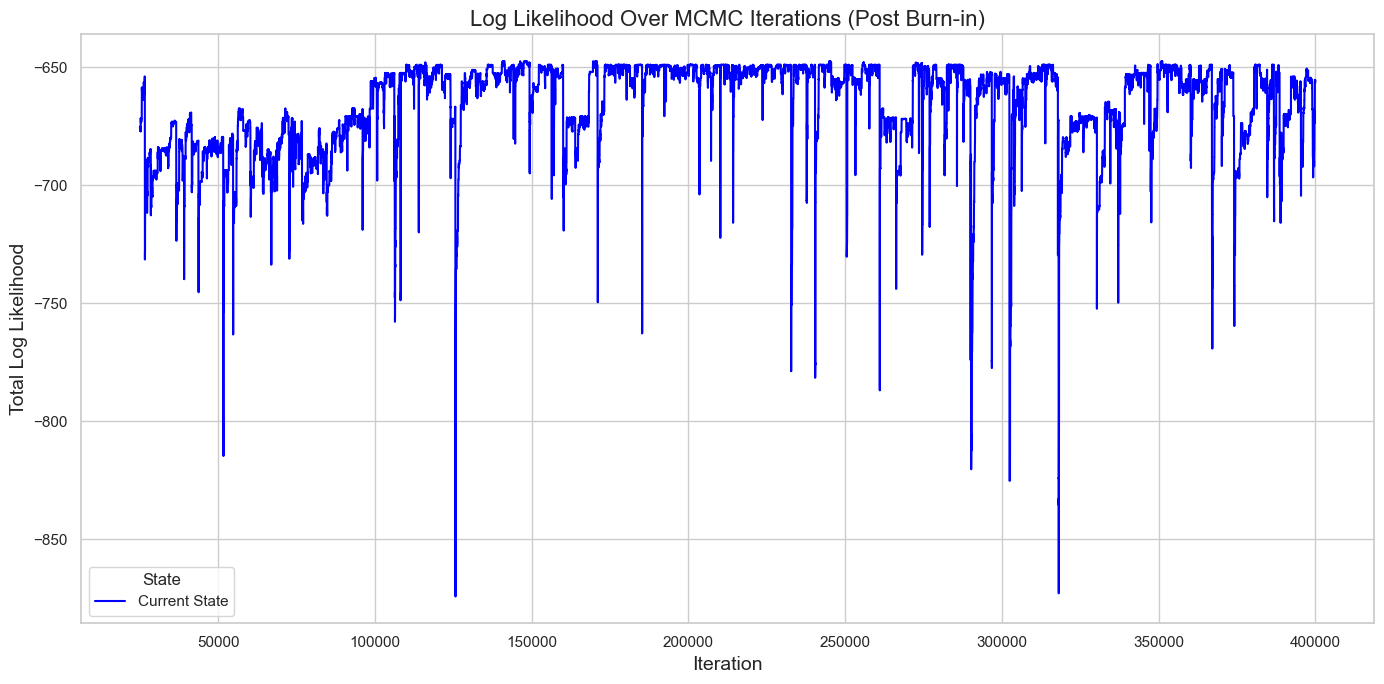

In [ ]:

log_likelihood_currents = mcmc_results.get('log_likelihood_currents', [])
PO_plot.plot_log_likelihood(log_likelihood_currents,burn_in=25000)

[INFO] Saved inferred parameters plot to './posterior_inference_result.pdf'


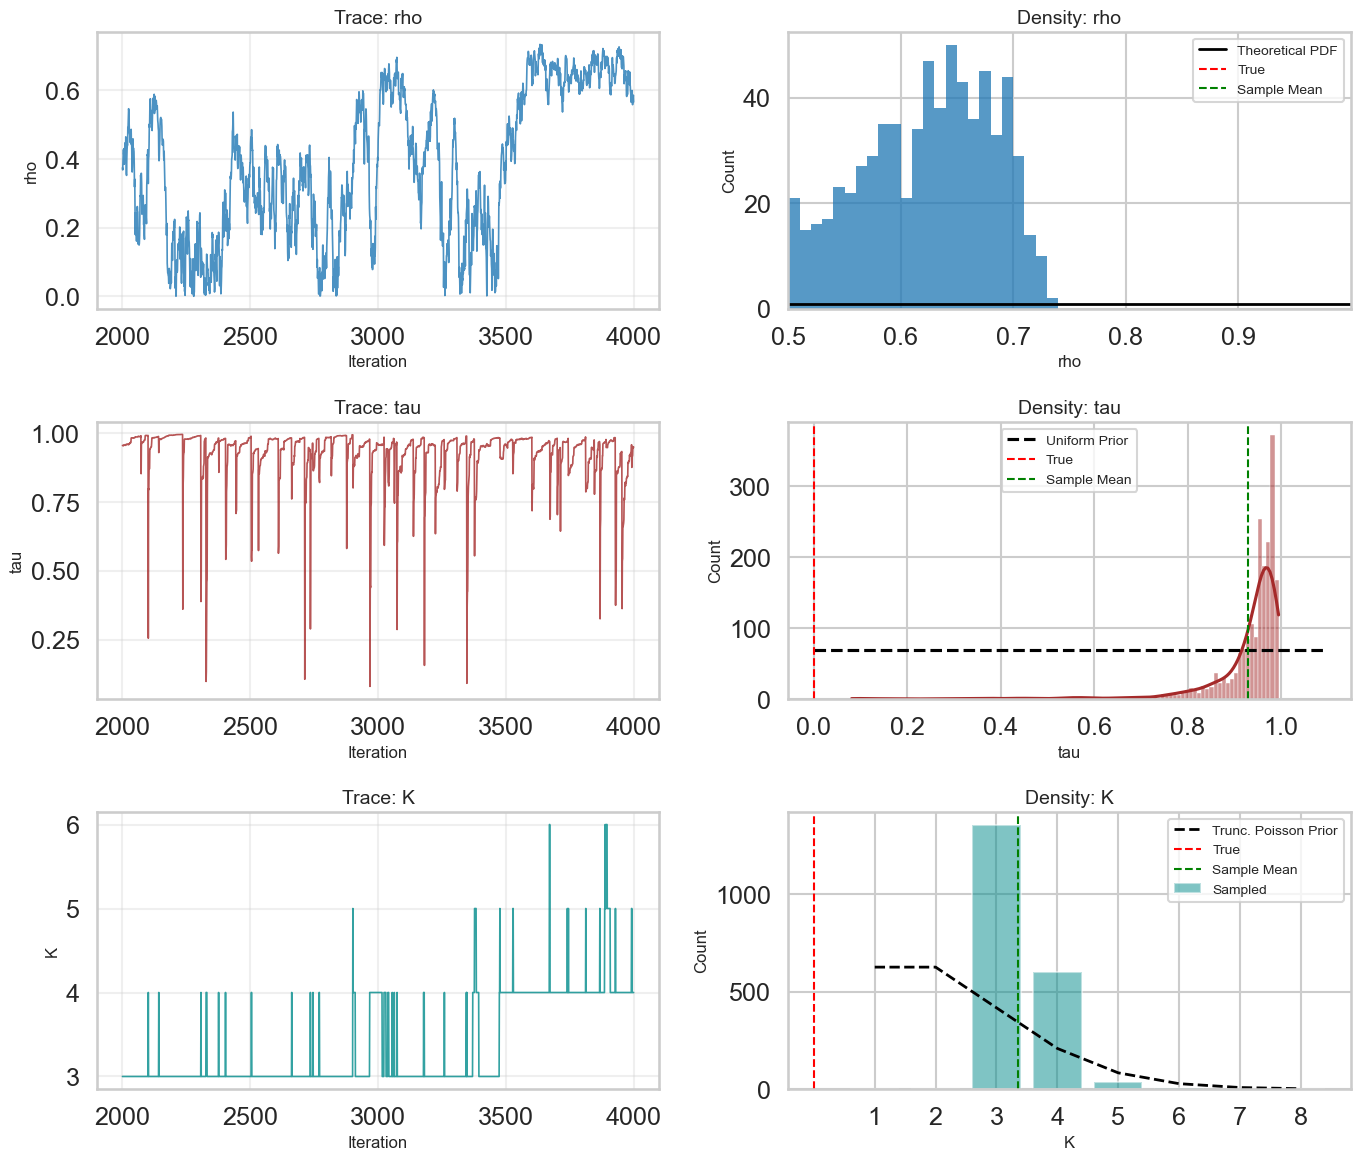

In [ ]:

from src.utils.po_fun_plot import PO_plot

config = {
    "prior": {
        "rho_prior": 1.0,
        "K_prior": 3,
        "noise_beta_prior": 1.0,
    },
    "noise": {
        "noise_option": "log_successors_queue_jump",
    },
}

burn_in_k = int(len(mcmc_results.get("H_trace", [])) * burn_in_fraction)

PO_plot.plot_inferred_variables(
    mcmc_results,
    config,
    burn_in=burn_in_k,
    output_filename="posterior_inference_result.pdf",
    assessors=assessors,
    M_a_dict=M_a_dict,
)



Text(0, 0.5, 'count')

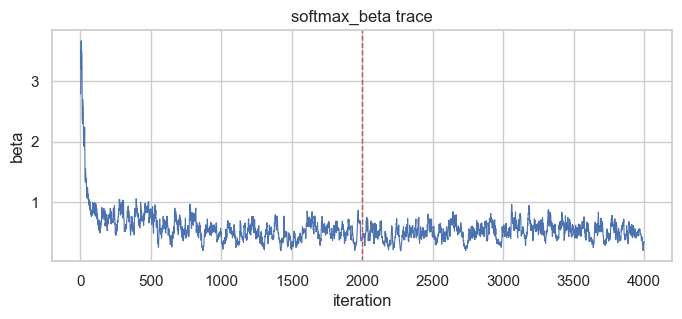

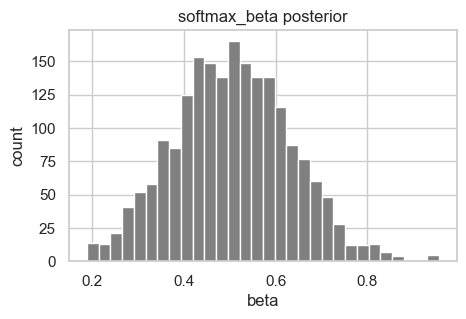

In [ ]:
beta = np.array(mcmc_results.get("softmax_beta_trace", []), dtype=float)
burn = int(len(beta) * 0.5)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.plot(beta, lw=0.8)
plt.axvline(burn, color="r", ls="--", lw=1)
plt.title("softmax_beta trace")
plt.xlabel("iteration"); plt.ylabel("beta")

plt.figure(figsize=(5, 3))
plt.hist(beta[burn:], bins=30, color="gray")
plt.title("softmax_beta posterior")
plt.xlabel("beta"); plt.ylabel("count")


## Data Check 

In [ ]:

from typing import List, Tuple, Set, Dict


def critical_pairs_from_closure(closure: np.ndarray) -> List[Tuple[int, int]]:
    """
    closure[i,j]=1 means i < j in the poset (strict).
    Returns oriented critical pairs (x,y) that must be reversed by some extension (i.e. y before x).
    """
    C = closure.astype(bool).copy()
    np.fill_diagonal(C, False)
    n = C.shape[0]

    # Down(x) = {z : z < x} = column x
    # Up(x)   = {z : x < z} = row x
    Down = C.T  # Down[x, z] == C[z, x]
    Up   = C

    crit: List[Tuple[int, int]] = []
    for x in range(n):
        Dx = Down[x]
        Ux = Up[x]
        for y in range(n):
            if x == y:
                continue
            if C[x, y] or C[y, x]:
                continue  # comparable => not critical
            Dy = Down[y]
            Uy = Up[y]

            # Dx ⊆ Dy  and  Uy ⊆ Ux
            if np.all(Dx <= Dy) and np.all(Uy <= Ux):
                crit.append((x, y))
    return crit


def _kahn_order_with_priority(
    cover_adj: np.ndarray,
    crit_pairs: List[Tuple[int, int]],
    rng: np.random.Generator,
    *,
    temperature: float = 0.0,
) -> List[int]:
    """
    Build ONE linear extension using a priority rule designed to reverse many critical pairs.
    cover_adj is a DAG adjacency (preferably transitively reduced, but any DAG works).
    crit_pairs are oriented (x,y) meaning we want y before x in this extension if possible.

    temperature=0 -> greedy max priority
    temperature>0 -> softmax sampling among frontier based on priority
    """
    A = (cover_adj != 0)
    n = A.shape[0]
    succ = [np.flatnonzero(A[u]).tolist() for u in range(n)]
    indeg = A.sum(axis=0).astype(int)

    # Build "desire" counts: for (x,y) we want y early and x late
    want_early = np.zeros(n, dtype=int)  # y appears here
    want_late  = np.zeros(n, dtype=int)  # x appears here
    for x, y in crit_pairs:
        want_early[y] += 1
        want_late[x]  += 1

    frontier = [i for i in range(n) if indeg[i] == 0]
    order: List[int] = []

    # Greedy/softmax selection from frontier
    while frontier:
        # Priority: push y early, delay x
        scores = np.array([want_early[v] - want_late[v] for v in frontier], dtype=float)

        if temperature <= 0.0:
            best = np.max(scores)
            candidates = [frontier[i] for i, s in enumerate(scores) if s == best]
            chosen = int(rng.choice(candidates))
        else:
            # softmax
            scores = scores - scores.max()
            w = np.exp(scores / temperature)
            w = w / w.sum()
            chosen = int(rng.choice(frontier, p=w))

        # remove chosen from frontier
        frontier.remove(chosen)
        order.append(chosen)

        # update graph
        for v in succ[chosen]:
            indeg[v] -= 1
            if indeg[v] == 0:
                frontier.append(v)

    if len(order) != n:
        raise ValueError("Graph had a cycle or was not fully processed.")
    return order


def _covered_critical_pairs(order: List[int], crit_pairs: List[Tuple[int, int]]) -> Set[int]:
    """Return indices of critical pairs (x,y) that are reversed in this order (i.e., y before x)."""
    pos = {v: i for i, v in enumerate(order)}
    covered: Set[int] = set()
    for k, (x, y) in enumerate(crit_pairs):
        if pos[y] < pos[x]:
            covered.add(k)
    return covered


def greedy_realizer(
    cover_adj: np.ndarray,
    closure: np.ndarray,
    *,
    seed: int = 0,
    max_extensions: int = 50,
    temperature: float = 0.5,
) -> List[List[int]]:
    """
    Greedy construction of a small realizer-like set:
      - compute critical pairs
      - iteratively add extensions that cover many uncovered critical pairs

    Not guaranteed minimal, but usually small and very informative.
    """
    rng = np.random.default_rng(seed)
    crit = critical_pairs_from_closure(closure)
    if not crit:
        # Total order already -> one extension is enough
        return [_kahn_order_with_priority(cover_adj, [], rng)]

    uncovered = set(range(len(crit)))
    realizers: List[List[int]] = []

    for _ in range(max_extensions):
        # build an extension guided by ALL critical pairs (heuristic)
        order = _kahn_order_with_priority(cover_adj, crit, rng, temperature=temperature)
        cov = _covered_critical_pairs(order, crit)
        gain = cov & uncovered
        if gain:
            realizers.append(order)
            uncovered -= gain
        # stop if all critical pairs reversed somewhere
        if not uncovered:
            break

    return realizers


def intersection_poset_from_extensions(extensions: List[List[int]], n: int) -> np.ndarray:
    """
    Returns strict relation R where R[i,j]=1 iff i before j in *every* extension.
    """
    R = np.ones((n, n), dtype=bool)
    np.fill_diagonal(R, False)
    for order in extensions:
        pos = np.empty(n, dtype=int)
        pos[np.array(order, dtype=int)] = np.arange(n)
        before = pos[:, None] < pos[None, :]
        np.fill_diagonal(before, False)
        R &= before
    return R.astype(np.int8)


# Check if observed traces cover all critical pairs of the true partial order
results_by_scenario = {}

def covered_crit_pairs_by_trace(order, crit_pairs):
    """
    Check which critical pairs are covered (reversed) by this trace order.
    Returns set of indices of critical pairs that are covered.
    For critical pair (x, y), it's covered if y appears before x in the order.
    """
    pos = {v: i for i, v in enumerate(order)}
    covered = set()
    for k, (x, y) in enumerate(crit_pairs):
        # Only check if both x and y are present in the trace
        if x in pos and y in pos:
            if pos[y] < pos[x]:  # y before x means (x,y) is reversed
                covered.add(k)
    return covered

for scenario_id in scenario_ids:
    print(f"\n{'='*60}")
    print(f"Analyzing scenario: {scenario_id}")
    print(f"{'='*60}")
    
    true_closure = scenario_data[scenario_id]["true_closure"]
    task_ids = scenario_data[scenario_id]["task_ids"]
    observed_orders_local = orders_local_by_assessor.get(scenario_id, [])
    
    print(f"Number of tasks: {true_closure.shape[0]}")
    print(f"Number of observed traces: {len(observed_orders_local)}")
    
    # Get critical pairs for the true partial order
    crit = critical_pairs_from_closure(true_closure)
    print(f"Total critical pairs: {len(crit)}")
    
    if len(crit) == 0:
        print("No critical pairs - poset is a total order or has no incomparable pairs")
        results_by_scenario[scenario_id] = {
            "num_tasks": true_closure.shape[0],
            "num_traces": len(observed_orders_local),
            "num_critical_pairs": 0,
            "num_covered": 0,
            "coverage_fraction": 1.0,
            "missing_critical_pairs": [],
        }
        continue
    
    # Check which critical pairs are covered by each trace
    all_covered = set()
    trace_coverage = []
    
    for trace_idx, trace_order in enumerate(observed_orders_local):
        covered = covered_crit_pairs_by_trace(trace_order, crit)
        all_covered |= covered
        trace_coverage.append({
            "trace_idx": trace_idx,
            "covered": covered,
            "num_covered": len(covered),
        })
    
    coverage_frac = len(all_covered) / len(crit)
    missing_indices = set(range(len(crit))) - all_covered
    missing_crit_pairs = [crit[i] for i in sorted(missing_indices)]
    
    print(f"\nCritical pair coverage:")
    print(f"  Covered: {len(all_covered)}/{len(crit)} ({coverage_frac:.3f})")
    print(f"  Missing: {len(missing_crit_pairs)}")
    
    # Print missing critical pairs with task names
    if missing_crit_pairs:
        print(f"\nMissing critical pairs:")
        for x, y in missing_crit_pairs:
            x_name = task_ids[x] if x < len(task_ids) else f"task_{x}"
            y_name = task_ids[y] if y < len(task_ids) else f"task_{y}"
            print(f"  ({x}, {y}): {x_name} and {y_name} are incomparable, but no trace has {y_name} before {x_name}")
    else:
        print(f"\n✓ All critical pairs are covered by at least one trace!")
    
    # Print per-trace coverage
    print(f"\nPer-trace coverage:")
    for tc in trace_coverage:
        print(f"  Trace {tc['trace_idx']}: covers {tc['num_covered']}/{len(crit)} critical pairs")
    
    # Store results
    results_by_scenario[scenario_id] = {
        "num_tasks": true_closure.shape[0],
        "num_traces": len(observed_orders_local),
        "num_critical_pairs": len(crit),
        "num_covered": len(all_covered),
        "coverage_fraction": coverage_frac,
        "missing_critical_pairs": missing_crit_pairs,
        "missing_critical_pair_indices": sorted(missing_indices),
        "trace_coverage": trace_coverage,
    }

print(f"\n{'='*60}")
print("Summary across all scenarios:")
print(f"{'='*60}")
for sid, res in results_by_scenario.items():
    print(f"{sid}: traces={res['num_traces']}, "
          f"crit_pairs={res['num_critical_pairs']}, "
          f"covered={res['num_covered']}, "
          f"coverage={res['coverage_fraction']:.3f}, "
          f"missing={len(res['missing_critical_pairs'])}")




Analyzing scenario: dual_zone_ecs_slb
Number of tasks: 7
Number of observed traces: 13
Total critical pairs: 3

Critical pair coverage:
  Covered: 3/3 (1.000)
  Missing: 0

✓ All critical pairs are covered by at least one trace!

Per-trace coverage:
  Trace 0: covers 0/3 critical pairs
  Trace 1: covers 1/3 critical pairs
  Trace 2: covers 1/3 critical pairs
  Trace 3: covers 1/3 critical pairs
  Trace 4: covers 1/3 critical pairs
  Trace 5: covers 1/3 critical pairs
  Trace 6: covers 1/3 critical pairs
  Trace 7: covers 1/3 critical pairs
  Trace 8: covers 1/3 critical pairs
  Trace 9: covers 2/3 critical pairs
  Trace 10: covers 0/3 critical pairs
  Trace 11: covers 1/3 critical pairs
  Trace 12: covers 1/3 critical pairs

Analyzing scenario: dual_zone_ecs_slb_rds
Number of tasks: 10
Number of observed traces: 24
Total critical pairs: 7

Critical pair coverage:
  Covered: 7/7 (1.000)
  Missing: 0

✓ All critical pairs are covered by at least one trace!

Per-trace coverage:
  Trace 0

In [ ]:
# ------------------------------------------------------------
#  Evaluate Baselines for Comparison
# ------------------------------------------------------------
from src.utils.hpo_model_evaluation import evaluate_baselines

print(f"\n{'='*80}")
print("BASELINE EVALUATION")
print(f"{'='*80}")

# Create true_cover dictionary in LOCAL index space (as expected by evaluate_baselines)
# The function expects: Dict[assessor_id -> true cover matrix] where matrix is in LOCAL indices
# scenario_data[sid]["true_cover"] is already in local index space (n_items x n_items per assessor)
true_cover_local = {}
for sid in assessors:
    if sid not in scenario_data:
        print(f"Warning: {sid} not found in scenario_data, skipping")
        continue
    
    # Get the true cover matrix (already in local index space for this scenario)
    true_cover_local[sid] = scenario_data[sid]["true_cover"].copy()
    
    # Verify size matches M_a_dict for this assessor
    n_items = len(M_a_dict.get(sid, []))
    true_cover_shape = true_cover_local[sid].shape
    n_tasks = len(scenario_data[sid]["task_ids"])
    
    # All these should be equal
    if n_items != n_tasks or true_cover_shape[0] != n_items or true_cover_shape[1] != n_items:
        print(f"Warning: Size mismatch for {sid}: n_items={n_items}, n_tasks={n_tasks}, true_cover shape={true_cover_shape}")
        # Resize if needed (shouldn't happen, but safety check)
        if true_cover_shape[0] != n_items:
            print(f"  Resizing true_cover from {true_cover_shape} to ({n_items}, {n_items})")
            true_cover_local[sid] = true_cover_local[sid][:n_items, :n_items]

print(f"\nCreated true_cover_local for {len(true_cover_local)} assessors")
print(f"Assessor keys in true_cover_local: {sorted(true_cover_local.keys())}")
print(f"Assessor keys in observed_orders: {sorted(observed_orders.keys())}")
print(f"Assessor keys in M_a_dict: {sorted(M_a_dict.keys())}")

# Evaluate both baseline methods
baseline_results = evaluate_baselines(
    observed_orders=observed_orders,      # Dict[assessor_id -> list of traces (global indices)]
    M_a_dict=M_a_dict,                     # Dict[assessor_id -> list of items (global indices)]
    true_cover=true_cover_local,           # Dict[assessor_id -> true cover matrix (LOCAL indices)]
    baseline_method="both",                # "always_before", "majority", or "both"
    majority_threshold=0.5                 # Threshold for majority baseline
)

# Print baseline results
print("Baseline Performance Comparison:")
print("-" * 60)
for assessor_id, assessor_results in baseline_results.items():
    print(f"\n{assessor_id}:")
    if "always_before" in assessor_results:
        ab = assessor_results["always_before"]
        print(f"  Always-Before: F1={ab['f1']:.3f}, P={ab['precision']:.3f}, R={ab['recall']:.3f}, SHD={ab['shd']}")
    if "majority" in assessor_results:
        maj = assessor_results["majority"]
        print(f"  Majority:      F1={maj['f1']:.3f}, P={maj['precision']:.3f}, R={maj['recall']:.3f}, SHD={maj['shd']}")

print(f"\n{'='*80}")
print("NOTE: Compare these baseline results with your BHPOP MCMC results above")
print(f"{'='*80}")



BASELINE EVALUATION

Created true_cover_local for 6 assessors
Assessor keys in true_cover_local: ['dual_zone_ecs_slb', 'dual_zone_ecs_slb_rds', 'eip_slb_ecs', 'simple_ecs', 'slb_ecs_rds', 'slb_ecs_redis']
Assessor keys in observed_orders: ['dual_zone_ecs_slb', 'dual_zone_ecs_slb_rds', 'eip_slb_ecs', 'simple_ecs', 'slb_ecs_rds', 'slb_ecs_redis']
Assessor keys in M_a_dict: ['dual_zone_ecs_slb', 'dual_zone_ecs_slb_rds', 'eip_slb_ecs', 'simple_ecs', 'slb_ecs_rds', 'slb_ecs_redis']
Baseline Performance Comparison:
------------------------------------------------------------

dual_zone_ecs_slb:
  Always-Before: F1=0.615, P=0.800, R=0.500, SHD=5
  Majority:      F1=0.571, P=0.667, R=0.500, SHD=6

dual_zone_ecs_slb_rds:
  Always-Before: F1=0.700, P=0.875, R=0.583, SHD=6
  Majority:      F1=0.381, P=0.444, R=0.333, SHD=13

eip_slb_ecs:
  Always-Before: F1=0.706, P=0.857, R=0.600, SHD=5
  Majority:      F1=0.333, P=0.375, R=0.300, SHD=12

simple_ecs:
  Always-Before: F1=0.667, P=0.750, R=0.600,

Assessor 0: 3990 post‑burn samples


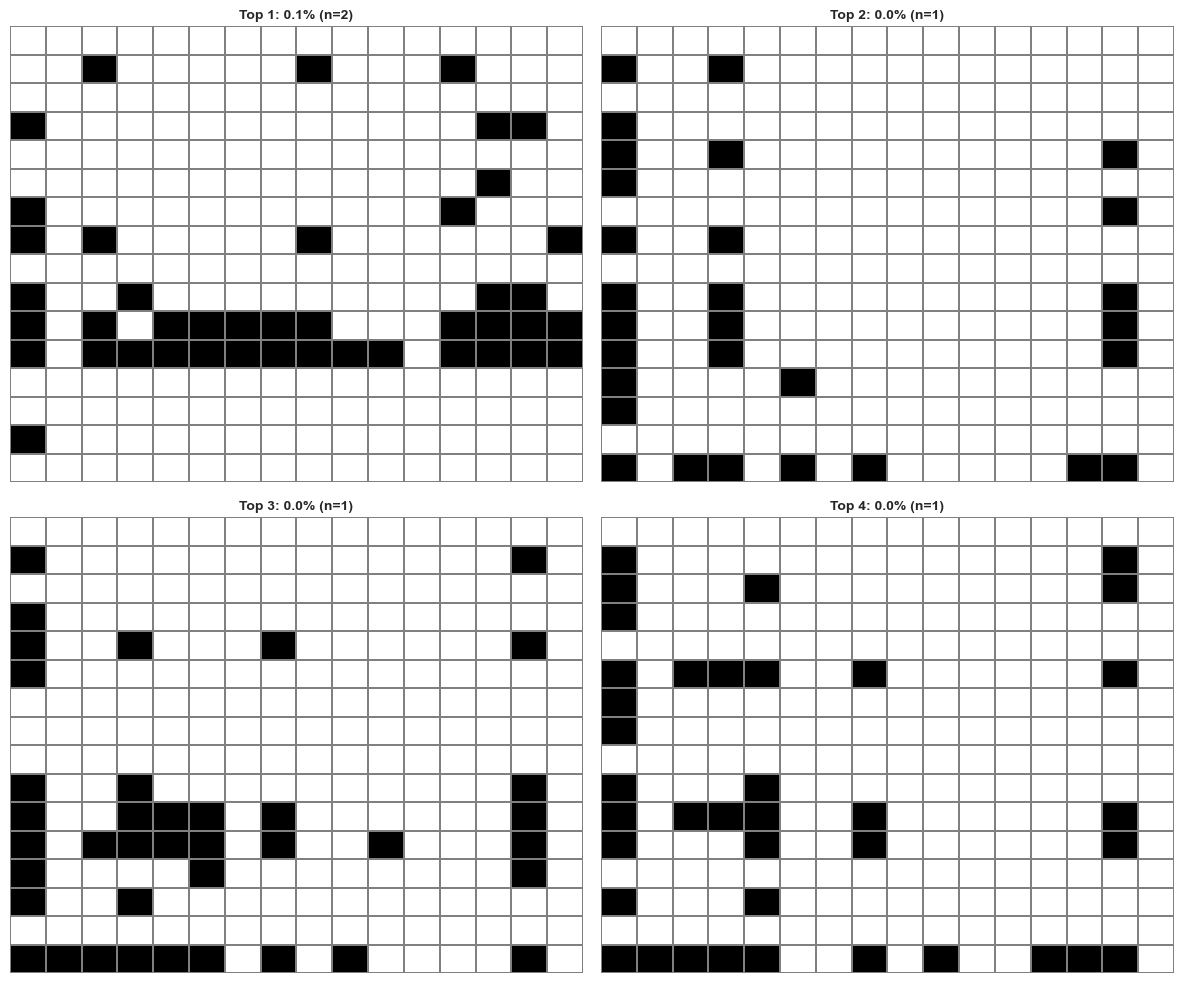

Assessor dual_zone_ecs_slb: 3990 post‑burn samples


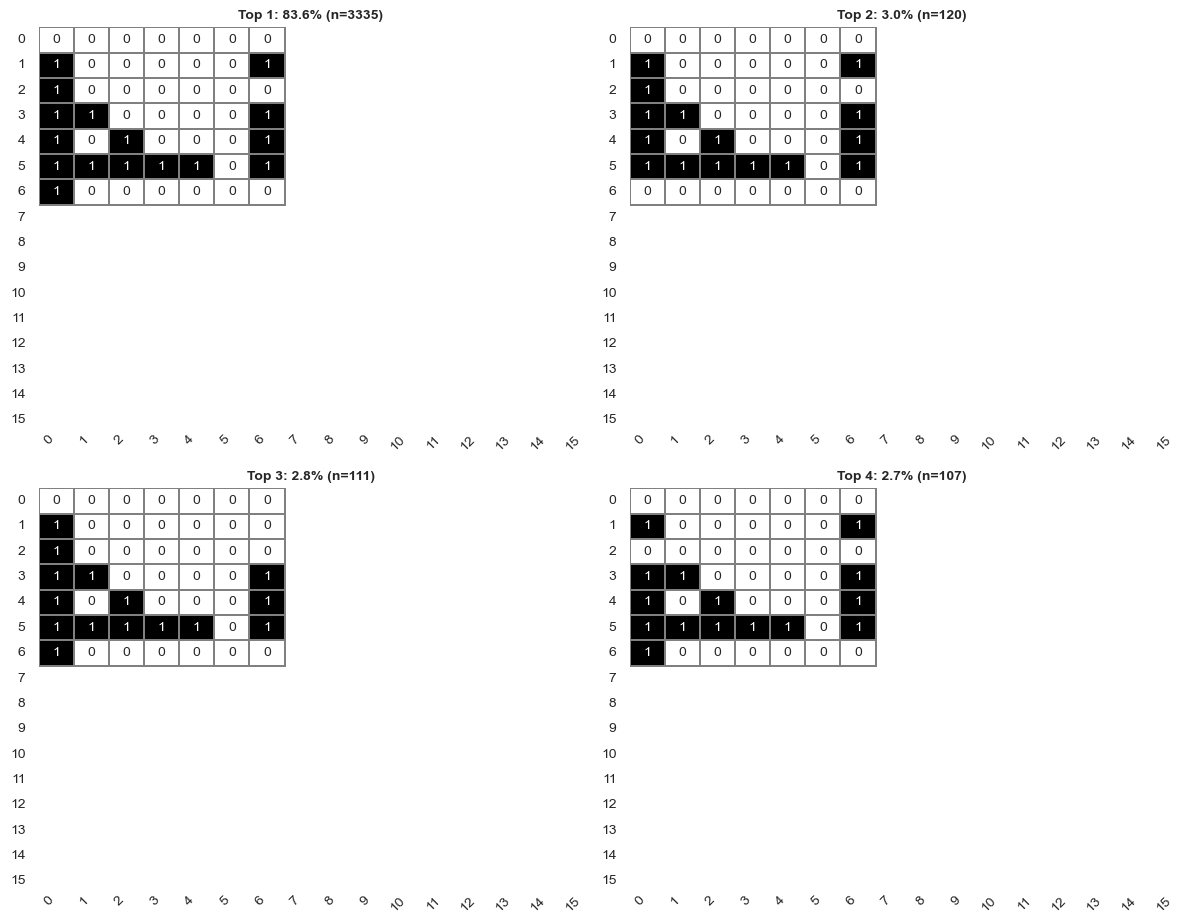

Assessor dual_zone_ecs_slb_rds: 3990 post‑burn samples


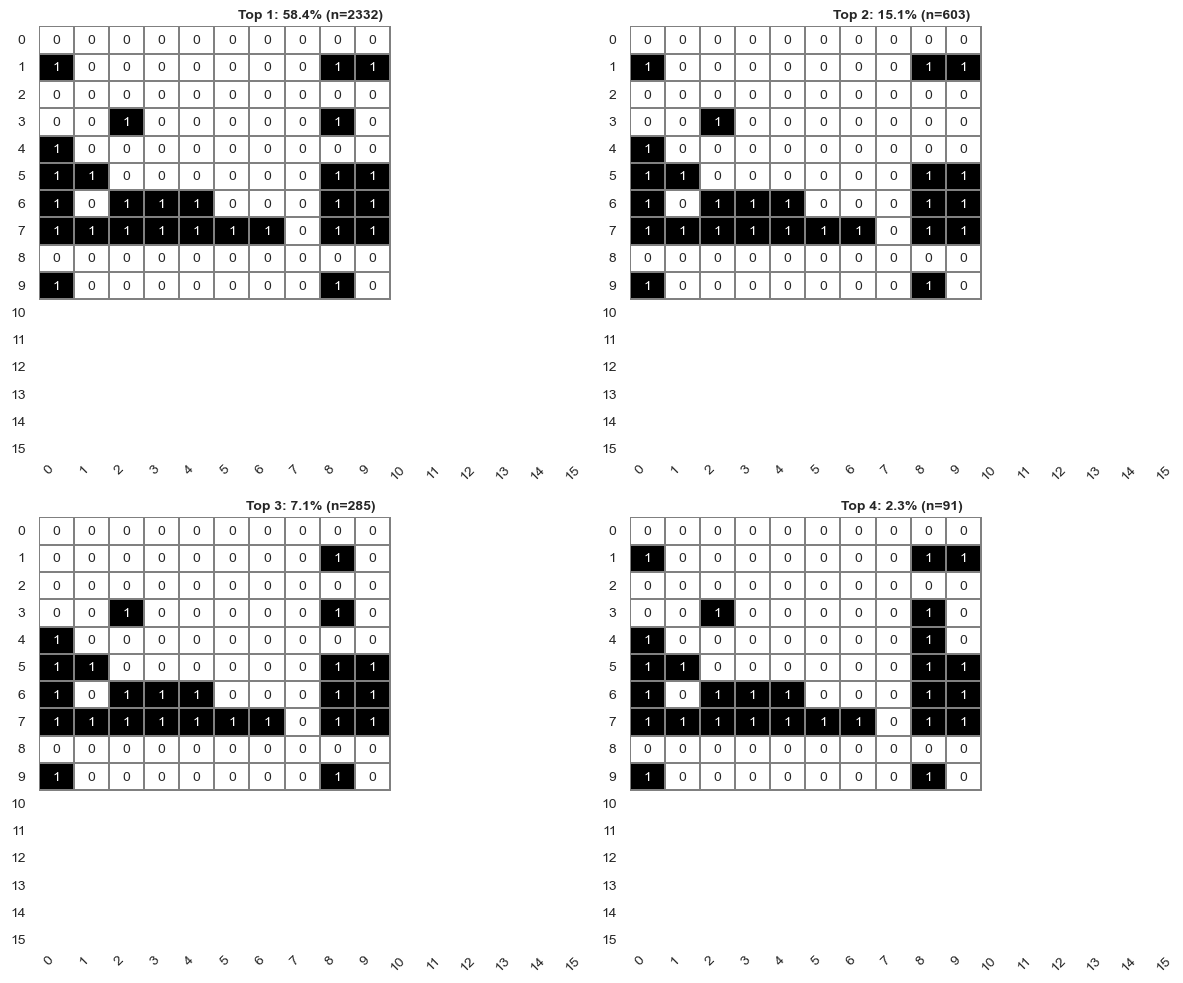

Assessor eip_slb_ecs: 3990 post‑burn samples


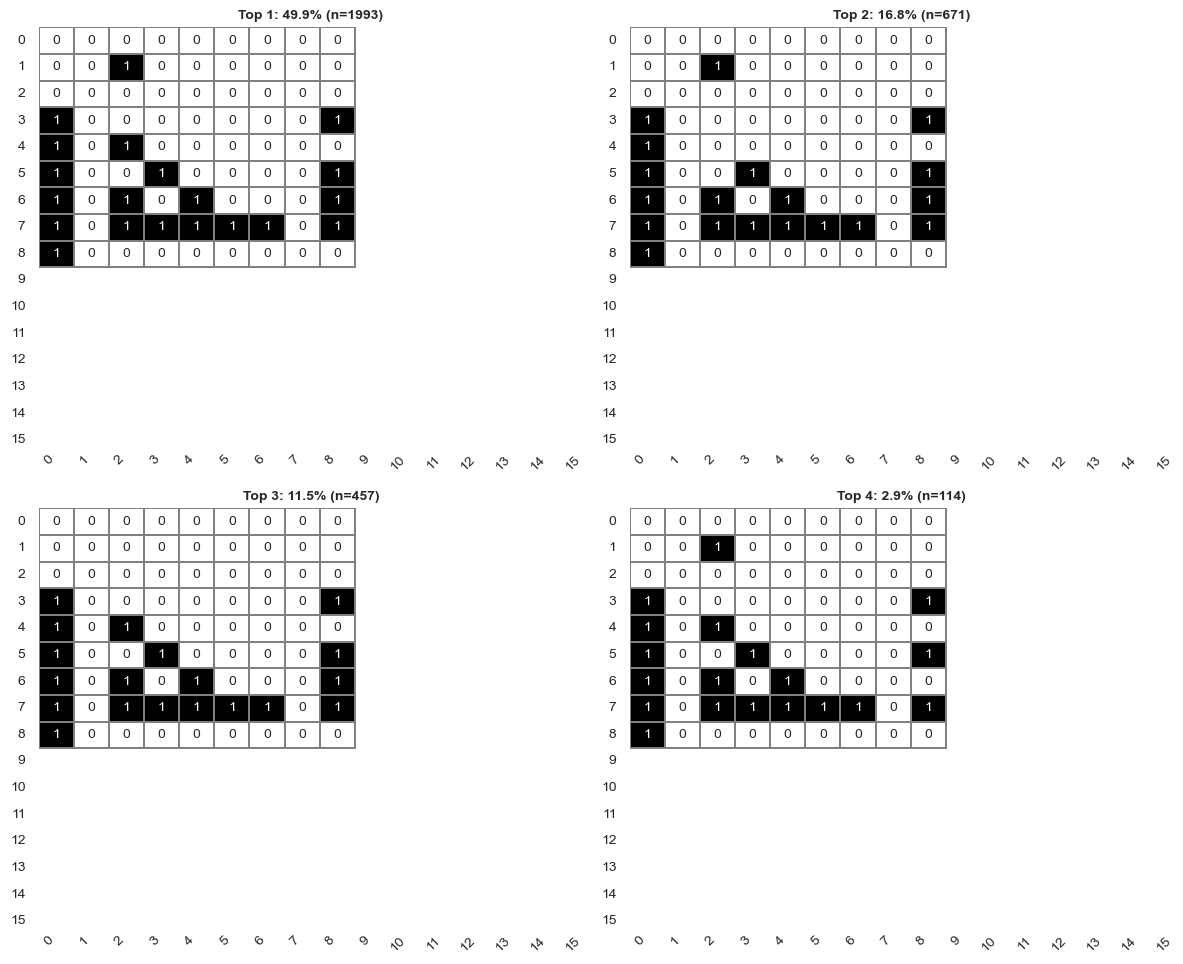

Assessor simple_ecs: 3990 post‑burn samples


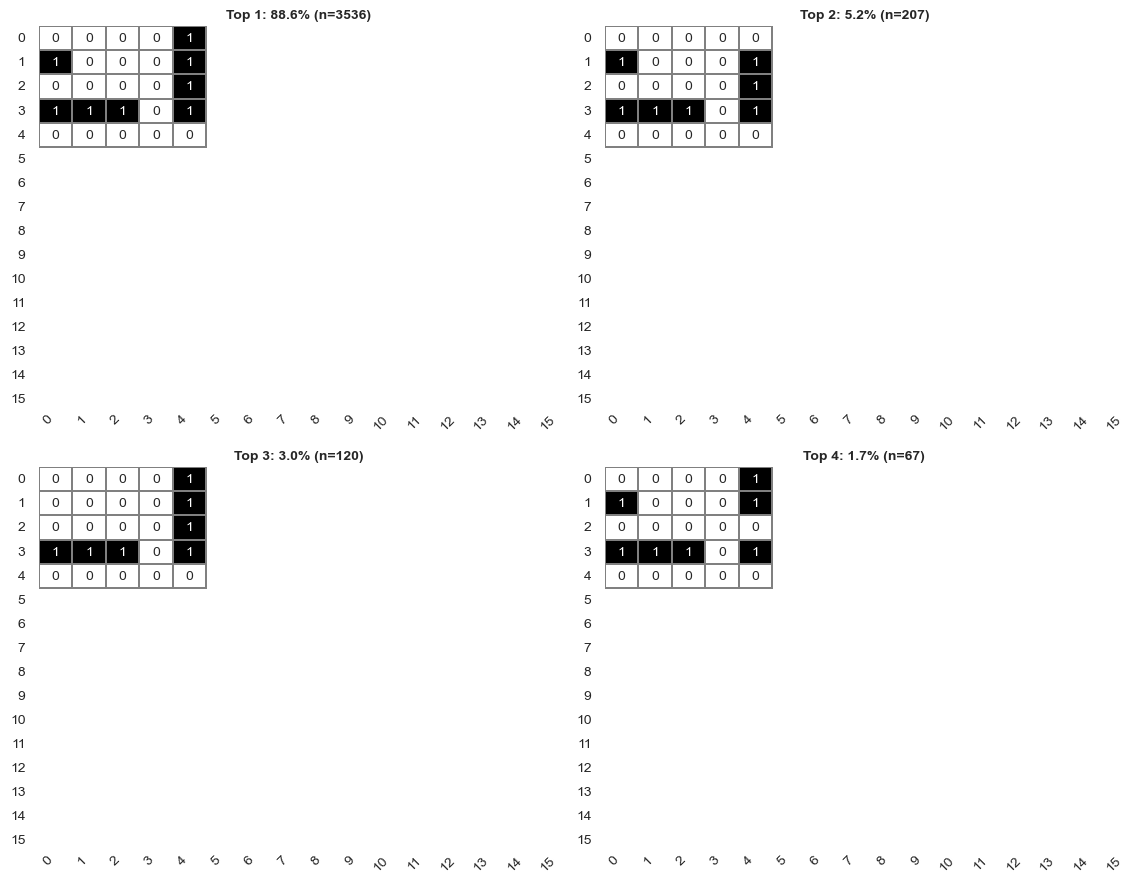

Assessor slb_ecs_rds: 3990 post‑burn samples


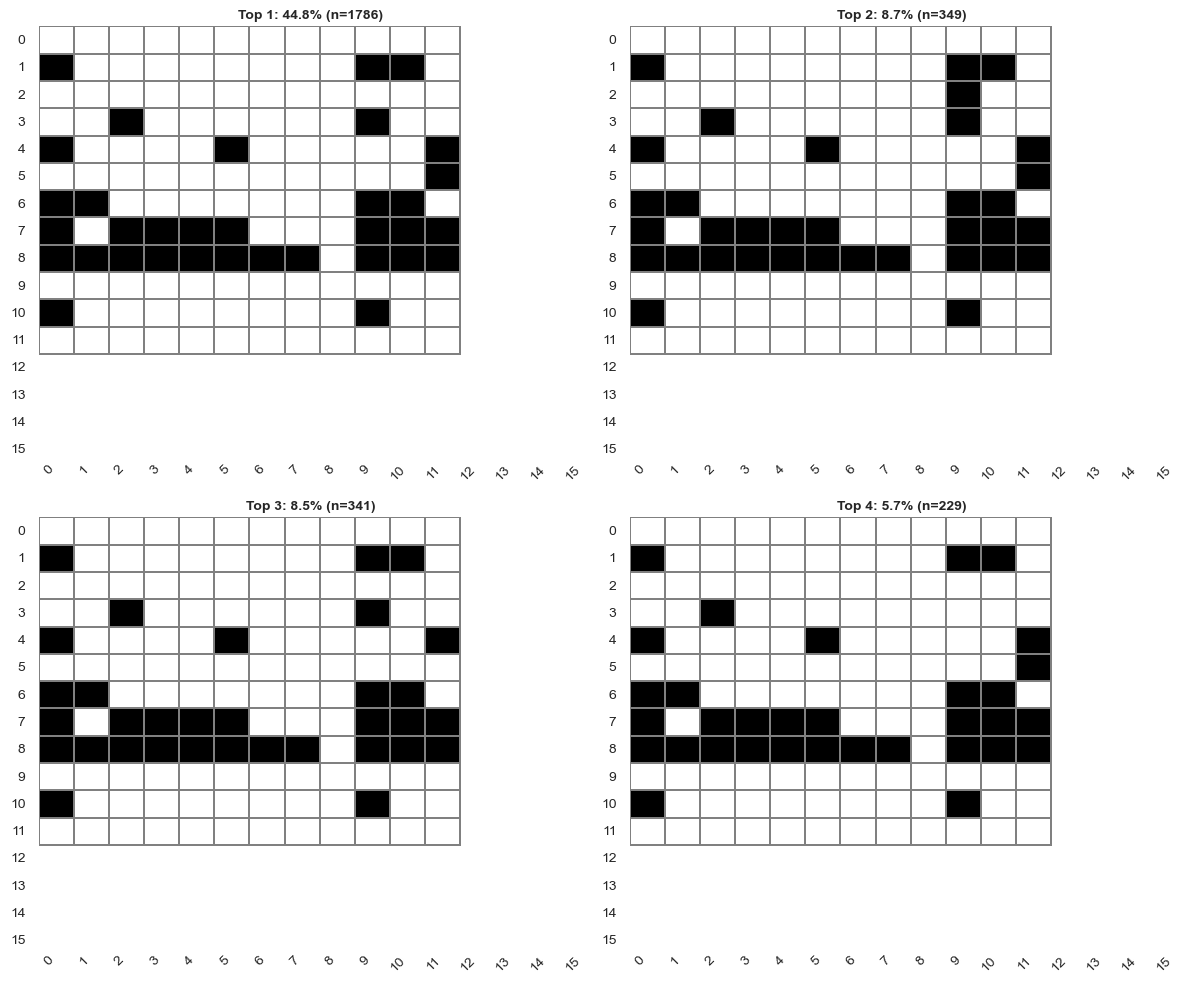

Assessor slb_ecs_redis: 3990 post‑burn samples


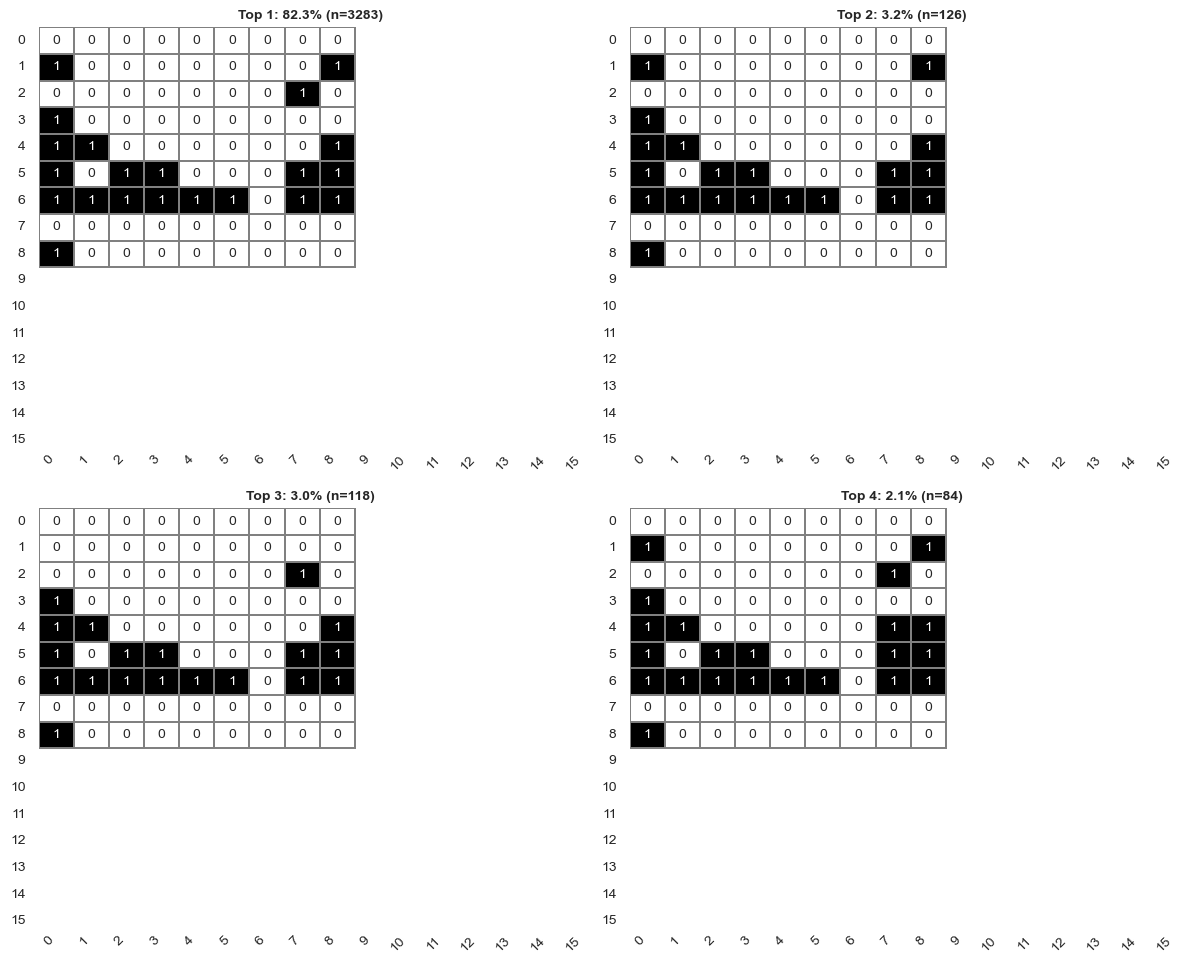

In [ ]:
from src.utils.po_fun import StatisticalUtils
burn_in_k = int(len(mcmc_results["H_trace"]) * burn_in_fraction)

h_trace_k       = mcmc_results["H_trace"][burn_in_k:]

filtered_mcmc_results_k = {
    key: trace[burn_in_k:] if isinstance(trace, np.ndarray) else trace
    for key, trace in mcmc_results.items()
}

threshold = 0.5

# Create a new dictionary to store the final inferred binary partial orders.
final_H_k = {}
# Get all assessor IDs from the first iteration
assessor_ids_k = h_trace_k[0].keys() 
for a in assessor_ids_k:
    # collect every iteration’s matrix for this assessor
    mats_a = [h_iter[a] for h_iter in h_trace_k if a in h_iter]

    mean_mat   = np.mean(mats_a, axis=0)
    bin_mat    = (mean_mat >= threshold).astype(int)
    h_final_a  = BasicUtils.transitive_reduction(bin_mat)
    final_H_k[a] = h_final_a

    # ---- frequency diagnostics --------------------------------
    sorted_hist = StatisticalUtils.count_unique_partial_orders(mats_a)
    total = sum(cnt for _, cnt in sorted_hist)
    print(f"Assessor {a}: {total} post‑burn samples")

    top_n = 4
    top_orders = sorted_hist[:top_n]
    top_perc   = [(m, c, 100*c/total) for m, c in top_orders]
    PO_plot.plot_top_partial_orders(top_perc, top_n=top_n, item_labels=M0)


In [ ]:

from collections import Counter, defaultdict
from typing import List, Dict, Any, Optional

def build_final_partial_orders(
    h_trace: List[Dict[Any, np.ndarray]],
    *,
    method: str = "mode",              # "mode" or "threshold"
    threshold: float = 0.3,            # used only when method="threshold"
    top_n: int = 4,
    item_labels: Optional[List[Any]] = None,
    plot_top: bool = True,
) -> Dict[Any, np.ndarray]:
    """
    Aggregate per-assessor partial orders into final H matrices.
    
    Parameters
    ----------
    h_trace : list of dict
        Each element is a dict {assessor_id -> adjacency matrix} for that iteration.
    method : {"mode", "threshold"}
        - "mode": choose the most frequent relationship per edge (i→j, j→i, incomparable).
        - "threshold": average probability and threshold at `threshold`.
    threshold : float
        Mean threshold when method="threshold".
    top_n : int
        Number of most frequent partial orders to show in diagnostics.
    item_labels : list, optional
        Labels to display in plots (falls back to 0..n-1).
    plot_top : bool
        Show top-N partial orders via `PO_plot` if available.
    
    Returns
    -------
    final_H : dict
        {assessor_id -> final adjacency matrix (after transitive reduction)}.
    """
    if not h_trace:
        raise ValueError("Empty H_trace provided.")

    assessor_ids = list(h_trace[0].keys())
    final_H = {}

    for assessor_id in assessor_ids:
        mats = [iter_dict[assessor_id] for iter_dict in h_trace if assessor_id in iter_dict]
        if not mats:
            continue

        T = len(mats)
        mats_arr = np.stack(mats, axis=0)  # (T, n, n)
        _, n, _ = mats_arr.shape

        if method == "threshold":
            mean_mat = np.mean(mats_arr, axis=0)
            agg_mat = (mean_mat >= float(threshold)).astype(np.int8)
        elif method == "mode":
            counts_ij = (mats_arr > 0).sum(axis=0)
            counts_ji = counts_ij.T
            counts_inc = T - counts_ij - counts_ji

            agg_mat = np.zeros((n, n), dtype=np.int8)
            iu = np.triu_indices(n, 1)
            for i, j in zip(*iu):
                votes = {
                    (i, j): counts_ij[i, j],
                    (j, i): counts_ji[i, j],
                    None:  counts_inc[i, j],
                }
                best = max(votes.items(), key=lambda kv: kv[1])[0]
                if best == (i, j):
                    agg_mat[i, j] = 1
                elif best == (j, i):
                    agg_mat[j, i] = 1
        else:
            raise ValueError(f"Unknown method '{method}'. Use 'mode' or 'threshold'.")

        # Direction-consistency cleanup (optional but keeps DAG tidy)
        if method == "mode":
            score = (counts_ij - counts_ji).sum(axis=1) / max(T, 1)
            order = np.argsort(-score)
            rank = np.empty(n, dtype=int); rank[order] = np.arange(n)
            for i in range(n):
                for j in range(n):
                    if agg_mat[i, j] and rank[i] >= rank[j]:
                        agg_mat[i, j] = 0

        np.fill_diagonal(agg_mat, 0)

        # Remove transitive edges / enforce DAG
        H_final = BasicUtils.transitive_reduction(agg_mat.astype(int))
        final_H[assessor_id] = H_final

        if plot_top:
            sorted_hist = StatisticalUtils.count_unique_partial_orders(mats)
            total = sum(cnt for _, cnt in sorted_hist)
            top = sorted_hist[:top_n]
            print(f"Assessor {assessor_id}: {total} post-burn samples")
            for idx, (mat, cnt) in enumerate(top, 1):
                pct = 100.0 * cnt / max(total, 1)
                print(f"  {idx}. count={cnt} ({pct:.1f}%)")

    return final_H

In [ ]:
burn_in_k = int(len(mcmc_results["H_trace"]) * burn_in_fraction)
h_trace_k       = mcmc_results["H_trace"][burn_in_k:]
final_H_mode = build_final_partial_orders(h_trace_k, method="threshold", threshold=0.5, top_n=4, item_labels=M0)


Assessor 0: 1000 post-burn samples
  1. count=1 (0.1%)
  2. count=1 (0.1%)
  3. count=1 (0.1%)
  4. count=1 (0.1%)
Assessor dual_zone_ecs_slb: 1000 post-burn samples
  1. count=709 (70.9%)
  2. count=88 (8.8%)
  3. count=47 (4.7%)
  4. count=39 (3.9%)
Assessor dual_zone_ecs_slb_rds: 1000 post-burn samples
  1. count=378 (37.8%)
  2. count=189 (18.9%)
  3. count=148 (14.8%)
  4. count=42 (4.2%)
Assessor eip_slb_ecs: 1000 post-burn samples
  1. count=484 (48.4%)
  2. count=138 (13.8%)
  3. count=75 (7.5%)
  4. count=45 (4.5%)
Assessor simple_ecs: 1000 post-burn samples
  1. count=749 (74.9%)
  2. count=137 (13.7%)
  3. count=61 (6.1%)
  4. count=30 (3.0%)
Assessor slb_ecs_rds: 1000 post-burn samples
  1. count=777 (77.7%)
  2. count=79 (7.9%)
  3. count=54 (5.4%)
  4. count=17 (1.7%)
Assessor slb_ecs_redis: 1000 post-burn samples
  1. count=476 (47.6%)
  2. count=449 (44.9%)
  3. count=18 (1.8%)
  4. count=12 (1.2%)


Probability matrices (posterior means):

0:
Shape: (16, 16)

Matrix:
[[0.000e+00 5.000e-04 5.000e-04 0.000e+00 0.000e+00 0.000e+00 1.000e-03
  0.000e+00 1.500e-03 0.000e+00 0.000e+00 0.000e+00 3.500e-03 3.350e-02
  2.500e-03 5.000e-03]
 [3.790e-01 0.000e+00 5.800e-01 5.000e-03 1.155e-01 3.200e-02 2.240e-01
  1.025e-01 2.700e-01 1.000e-03 3.500e-03 0.000e+00 4.060e-01 1.555e-01
  5.350e-02 4.630e-01]
 [1.150e-01 3.000e-03 0.000e+00 1.000e-03 2.200e-02 5.500e-03 1.400e-02
  9.000e-03 4.550e-02 0.000e+00 0.000e+00 0.000e+00 6.000e-02 4.700e-02
  7.500e-03 1.205e-01]
 [9.800e-01 5.000e-03 8.500e-02 0.000e+00 3.000e-02 8.000e-03 2.250e-02
  2.500e-03 3.750e-02 2.000e-03 5.000e-04 0.000e+00 6.800e-02 9.360e-01
  8.675e-01 7.950e-02]
 [4.100e-02 5.000e-04 8.350e-02 5.000e-04 0.000e+00 1.400e-02 6.000e-03
  5.000e-04 5.000e-03 0.000e+00 0.000e+00 0.000e+00 1.650e-02 1.435e-01
  7.000e-03 2.150e-02]
 [2.360e-01 1.500e-03 2.390e-01 2.000e-03 6.400e-01 0.000e+00 2.850e-02
  1.000e-02 6.450e-02 5.

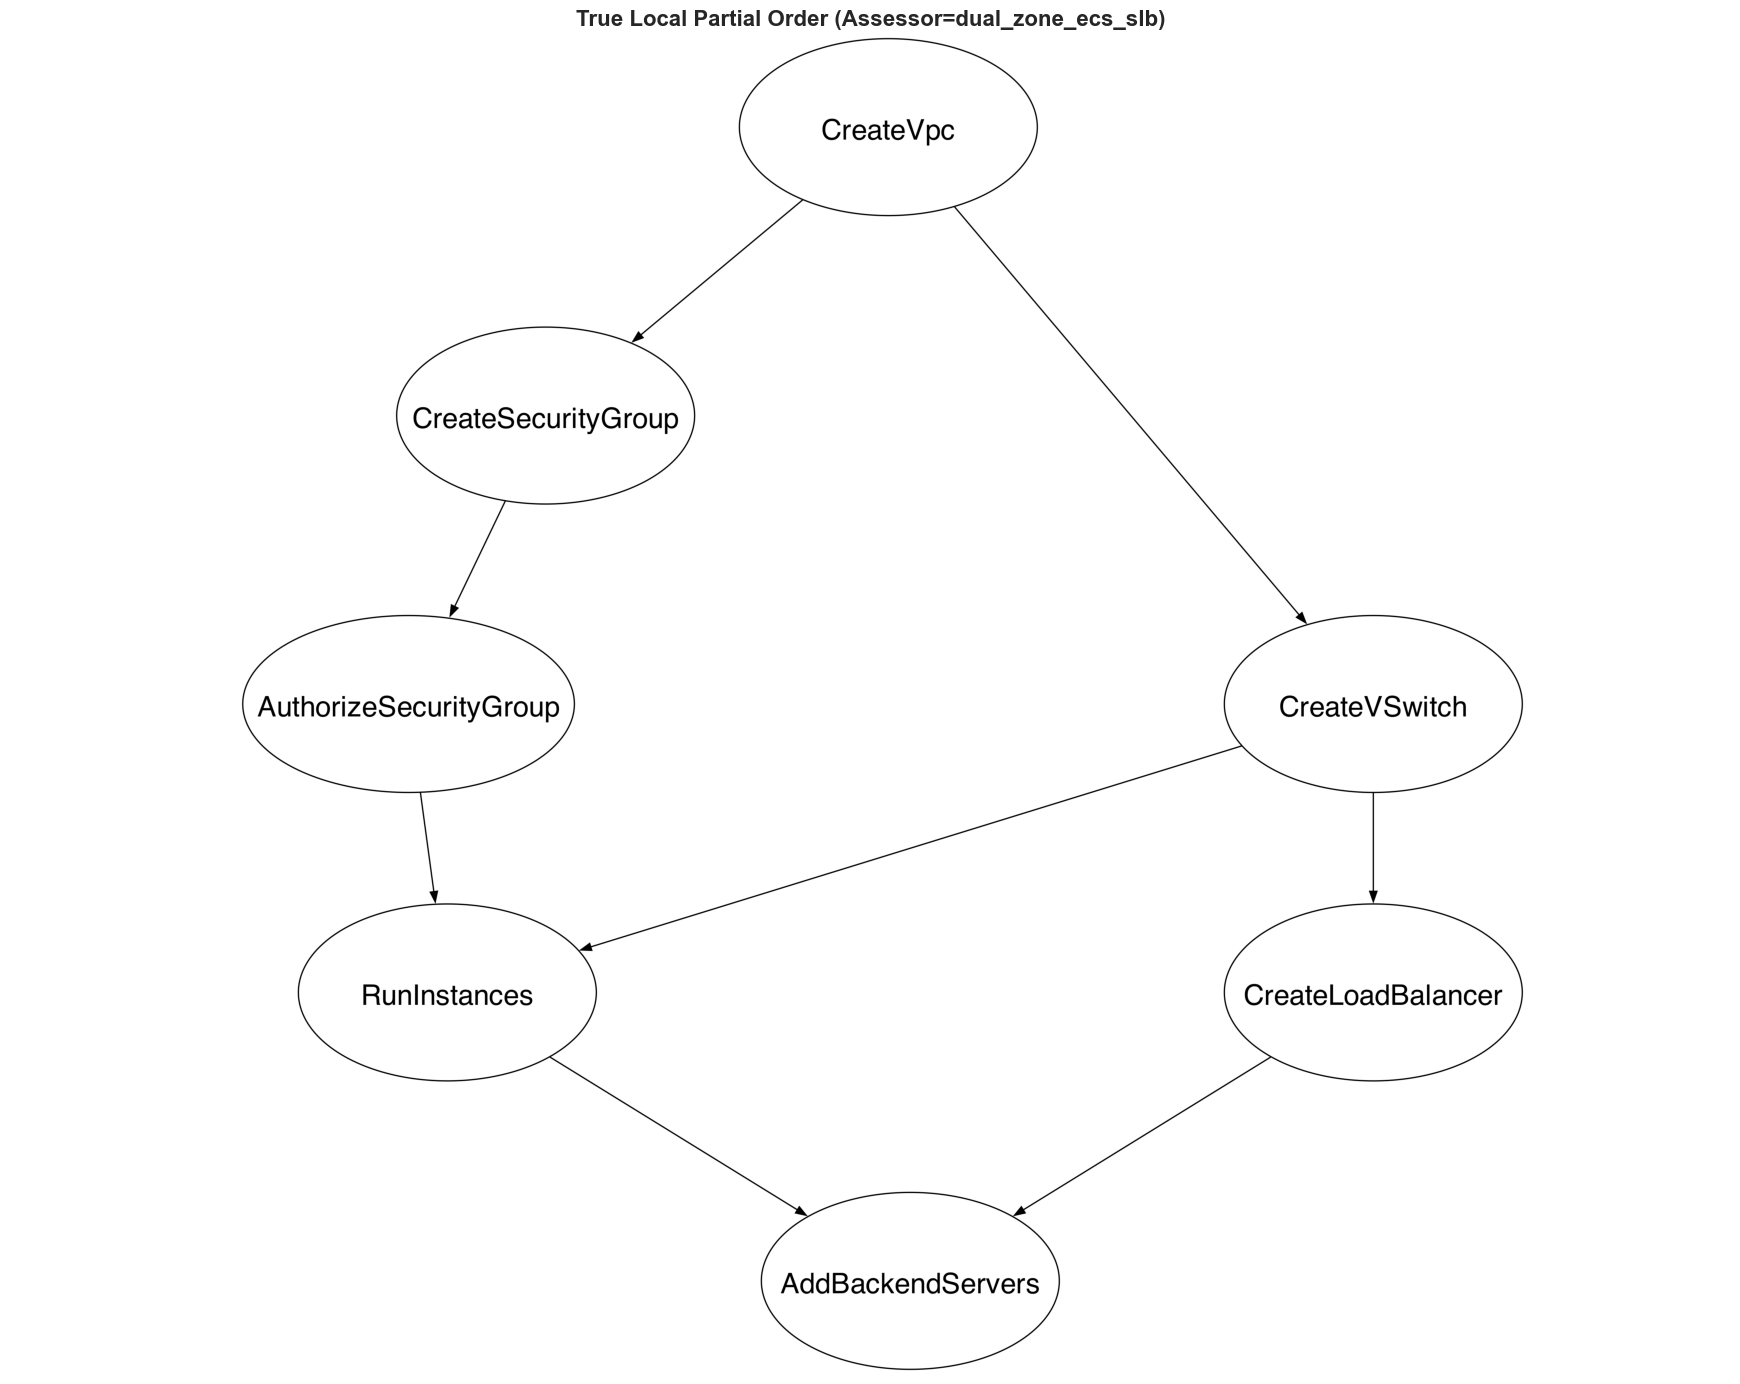

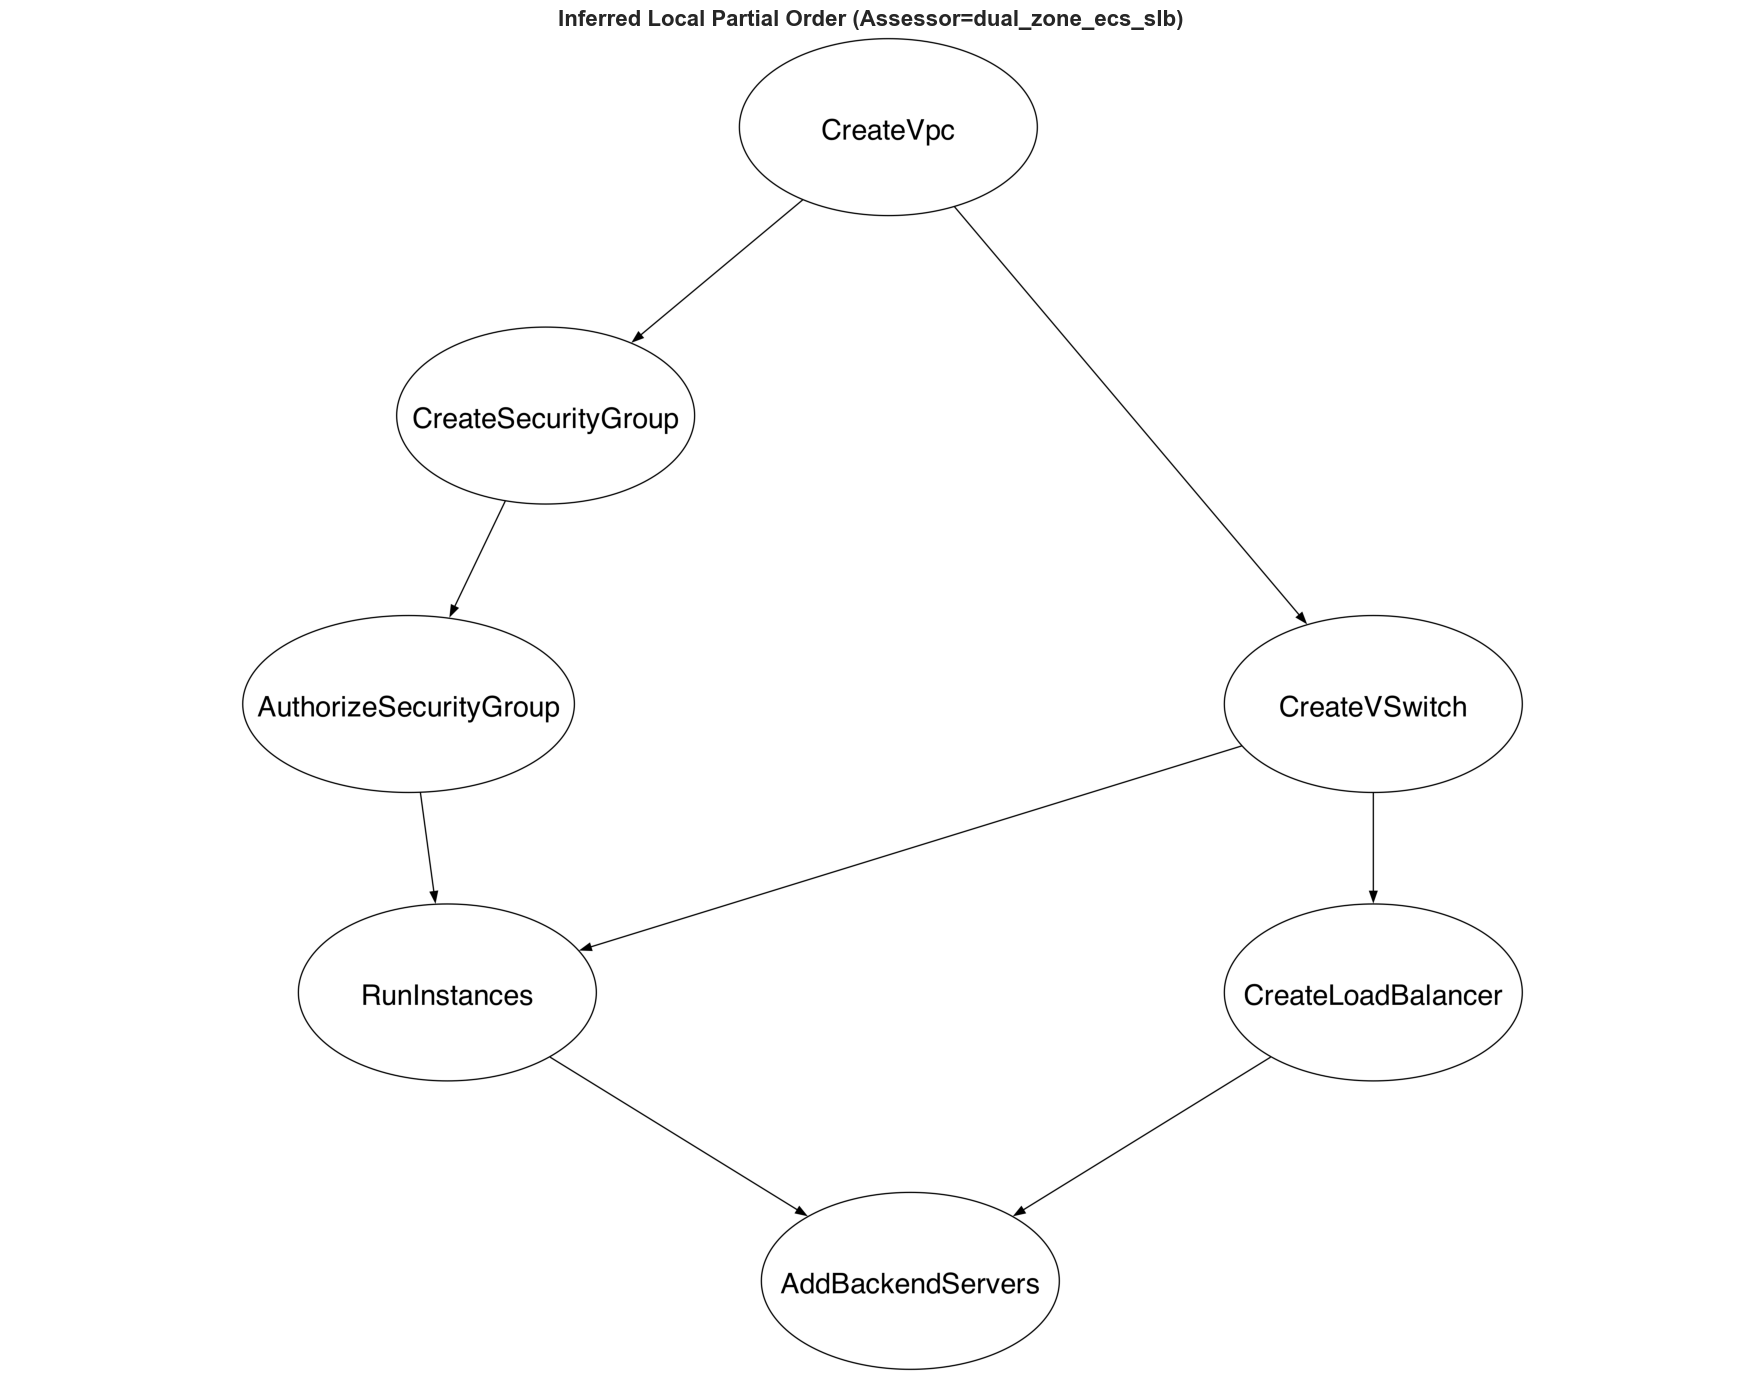


No missing edges for assessor dual_zone_ecs_slb.

No redundant edges for assessor dual_zone_ecs_slb.


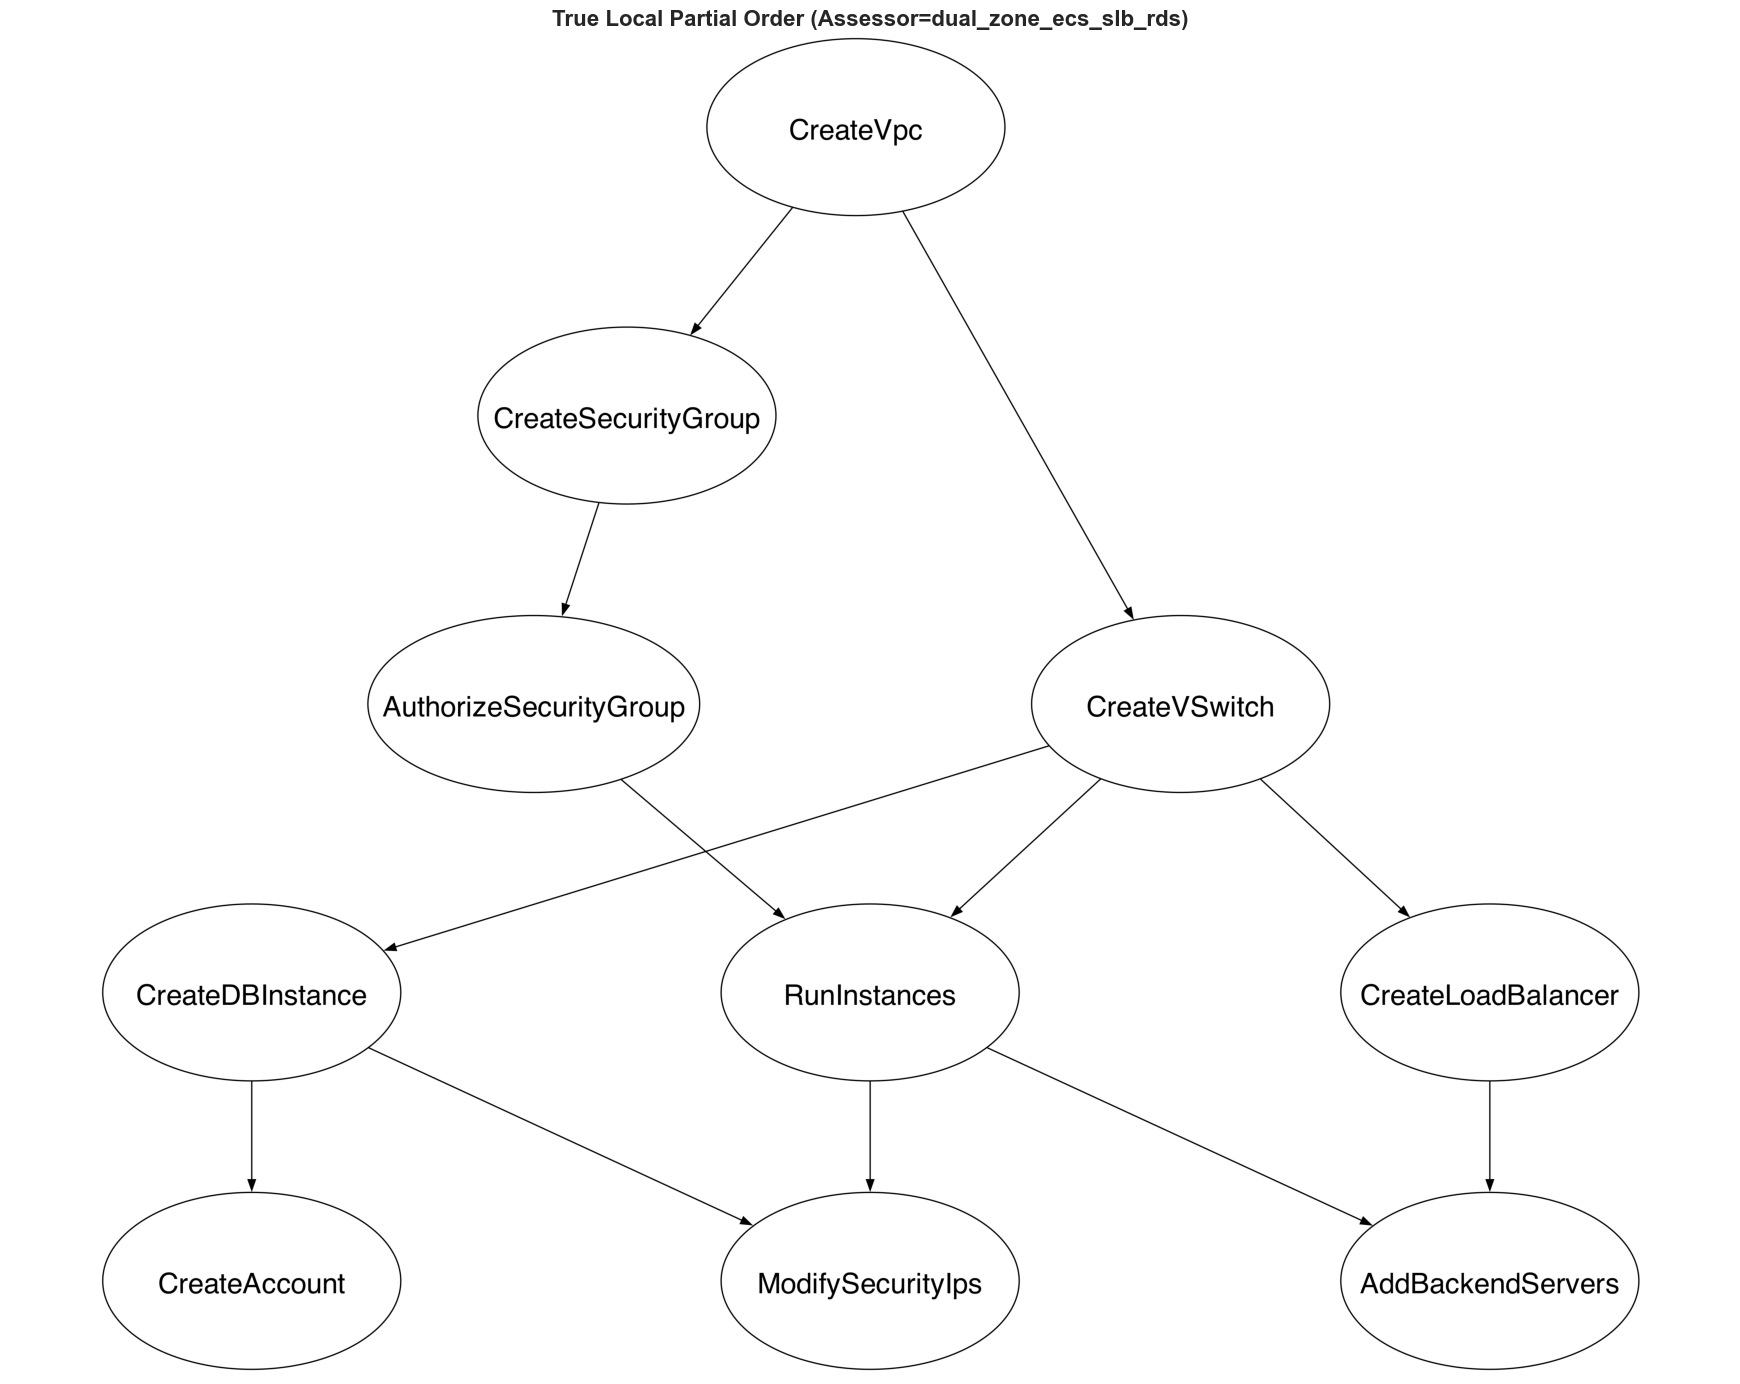

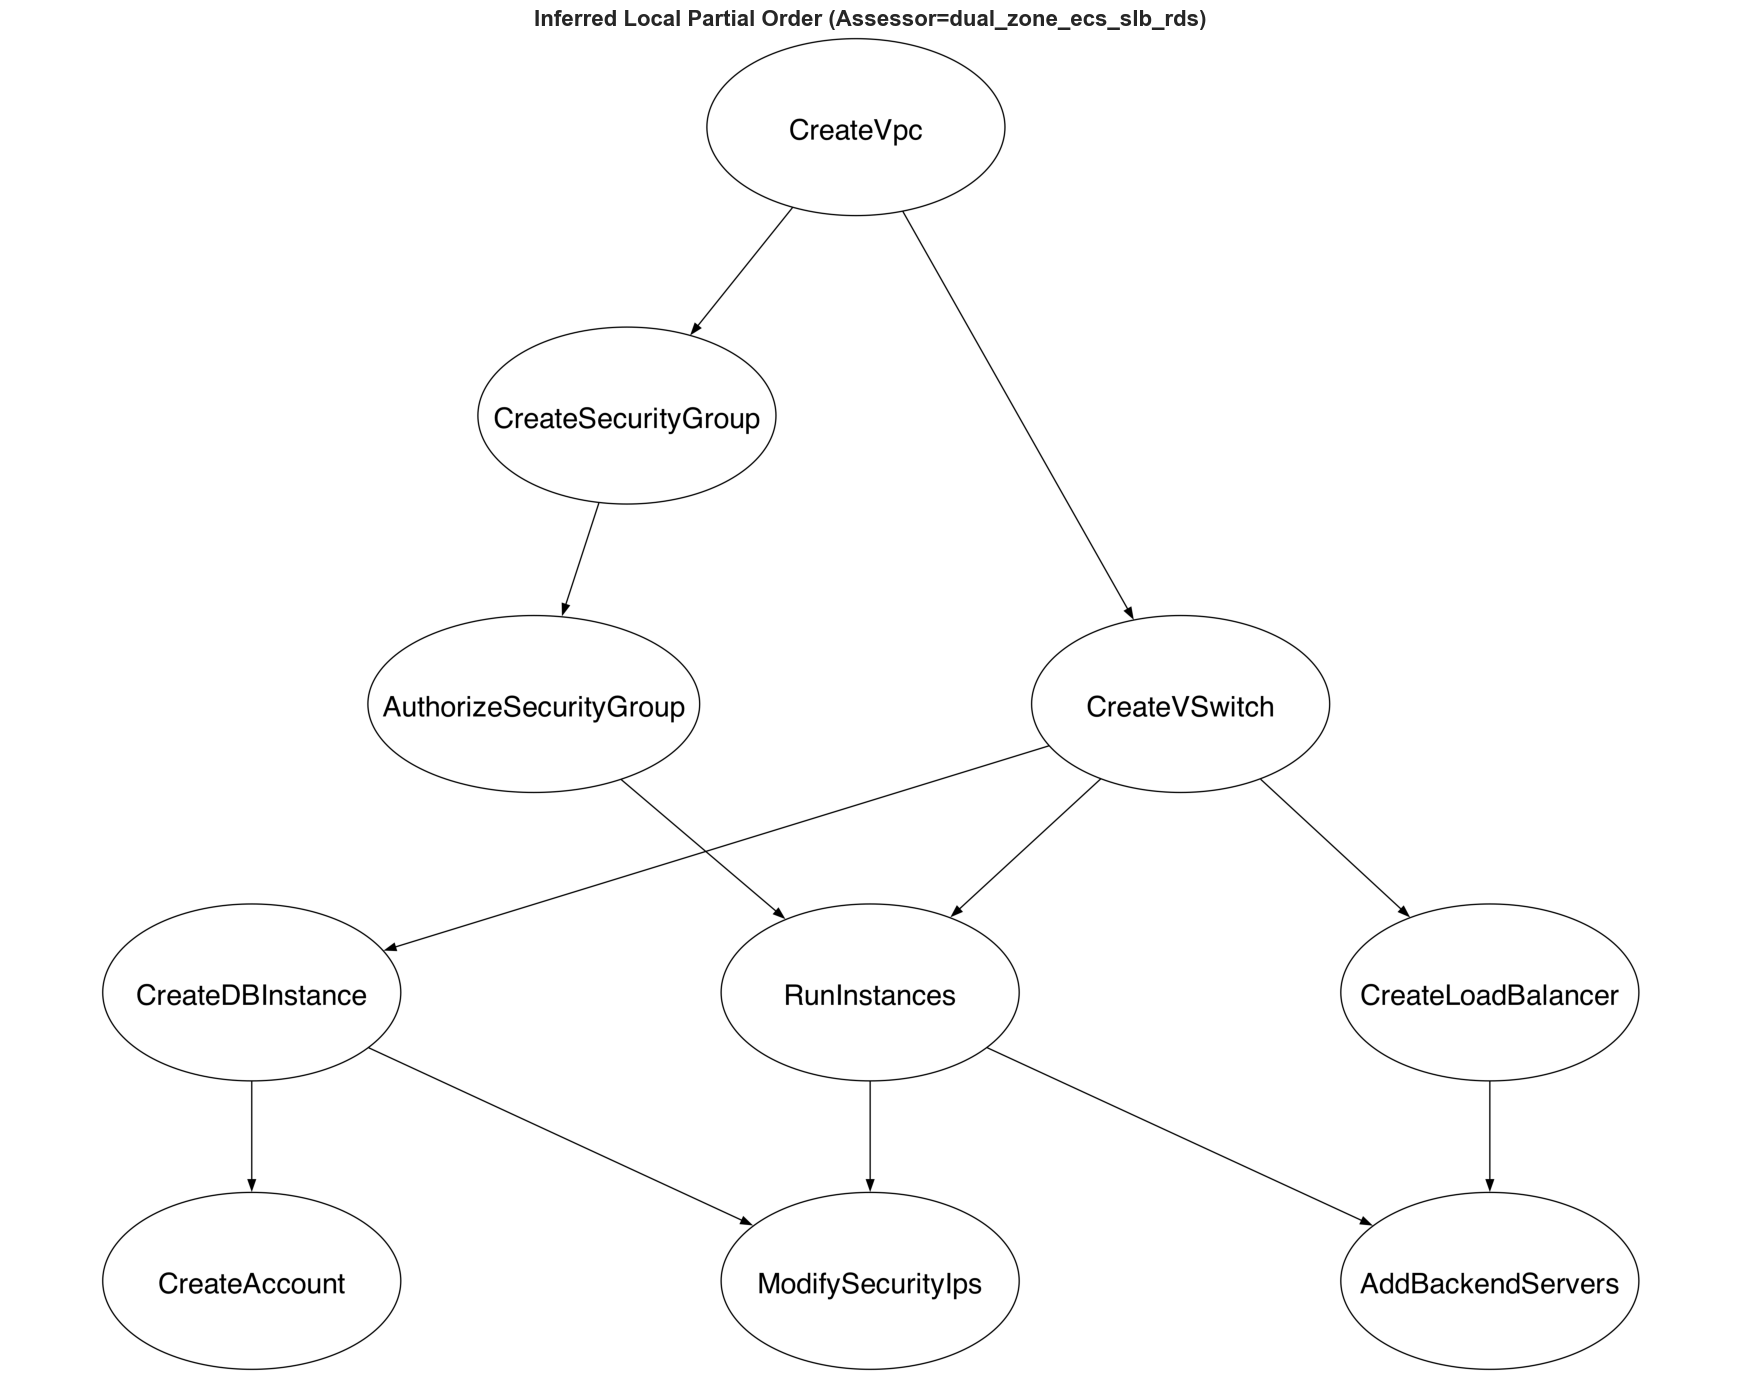


No missing edges for assessor dual_zone_ecs_slb_rds.

No redundant edges for assessor dual_zone_ecs_slb_rds.


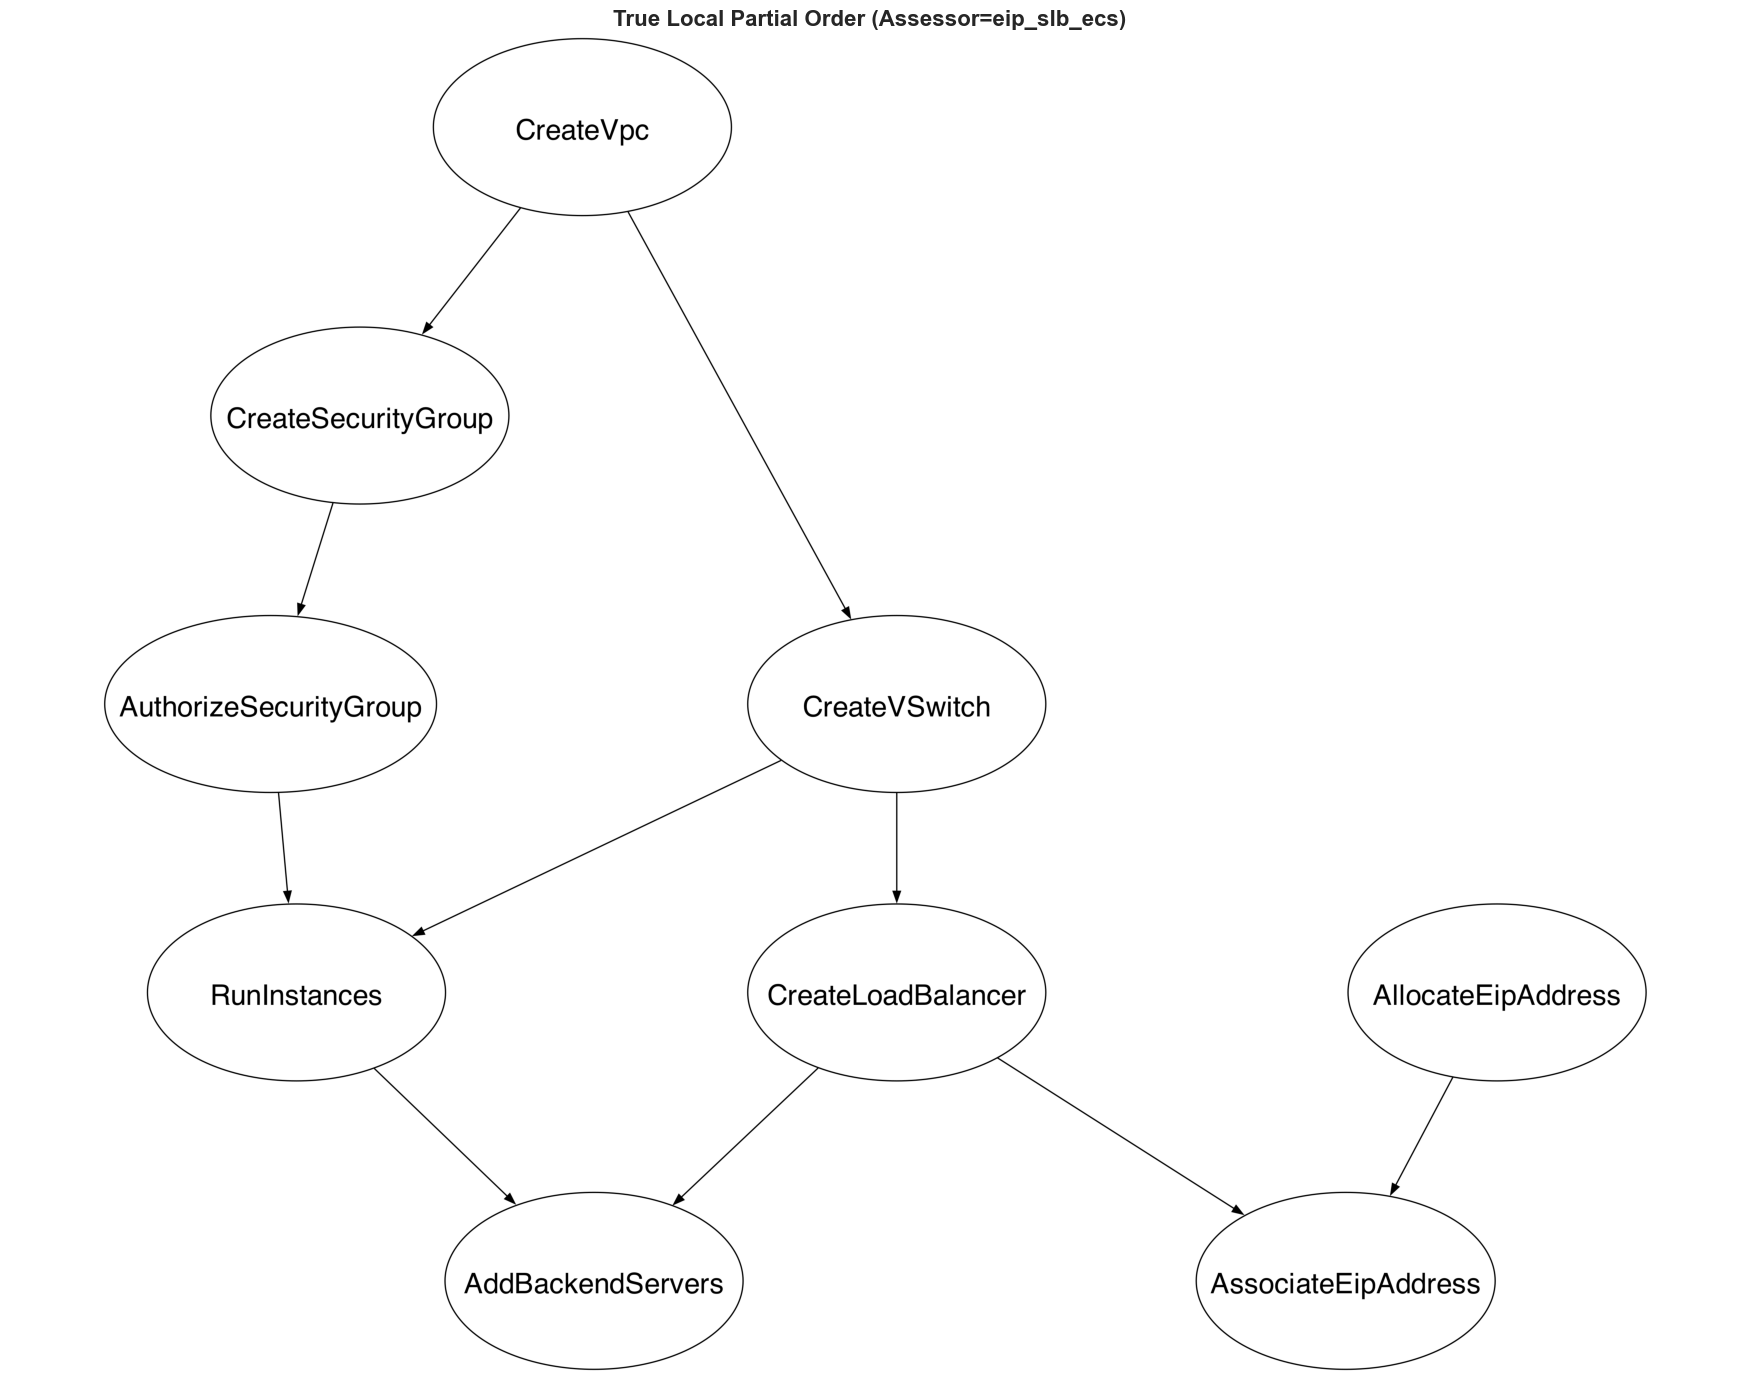

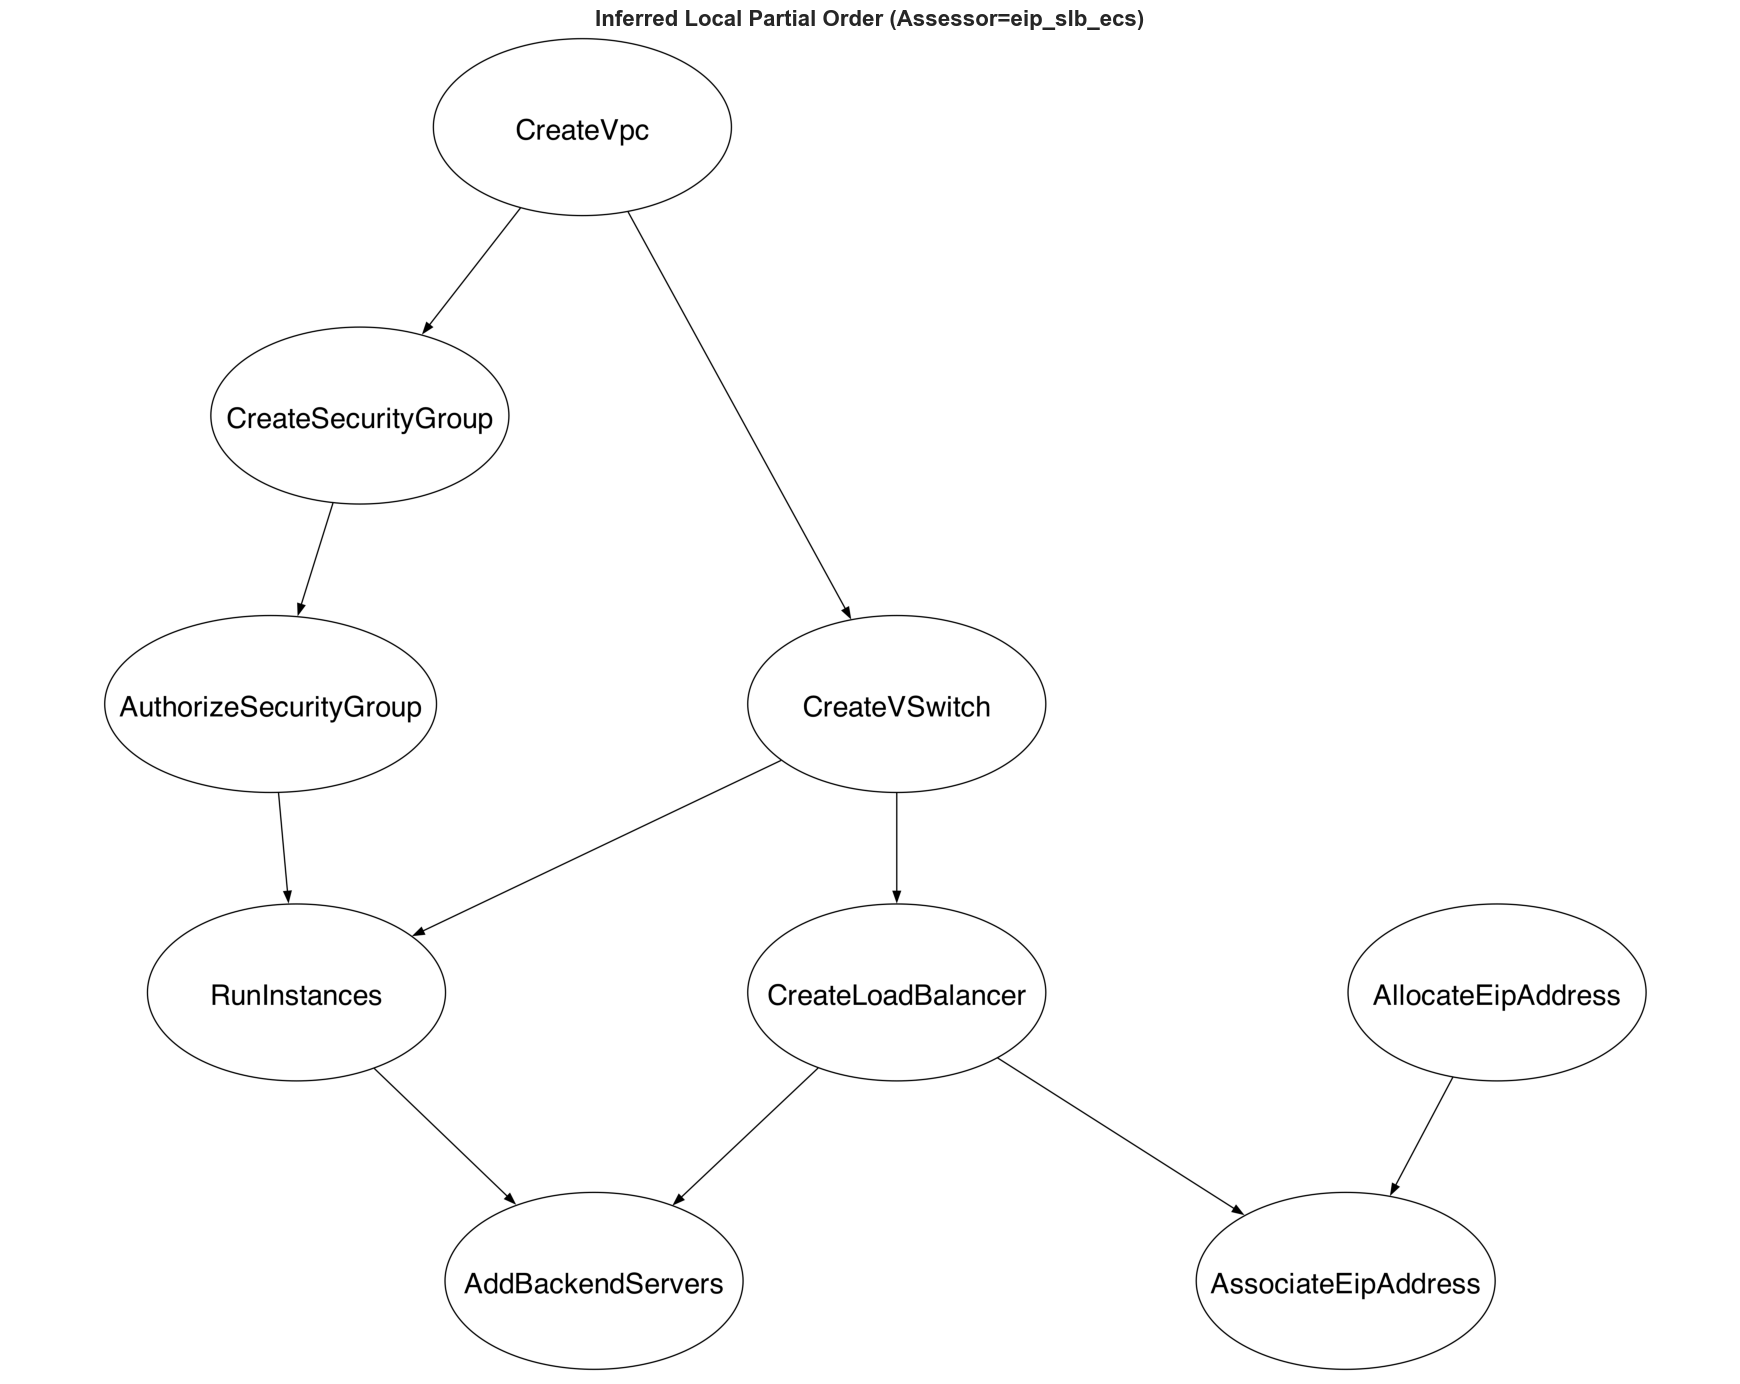


No missing edges for assessor eip_slb_ecs.

No redundant edges for assessor eip_slb_ecs.


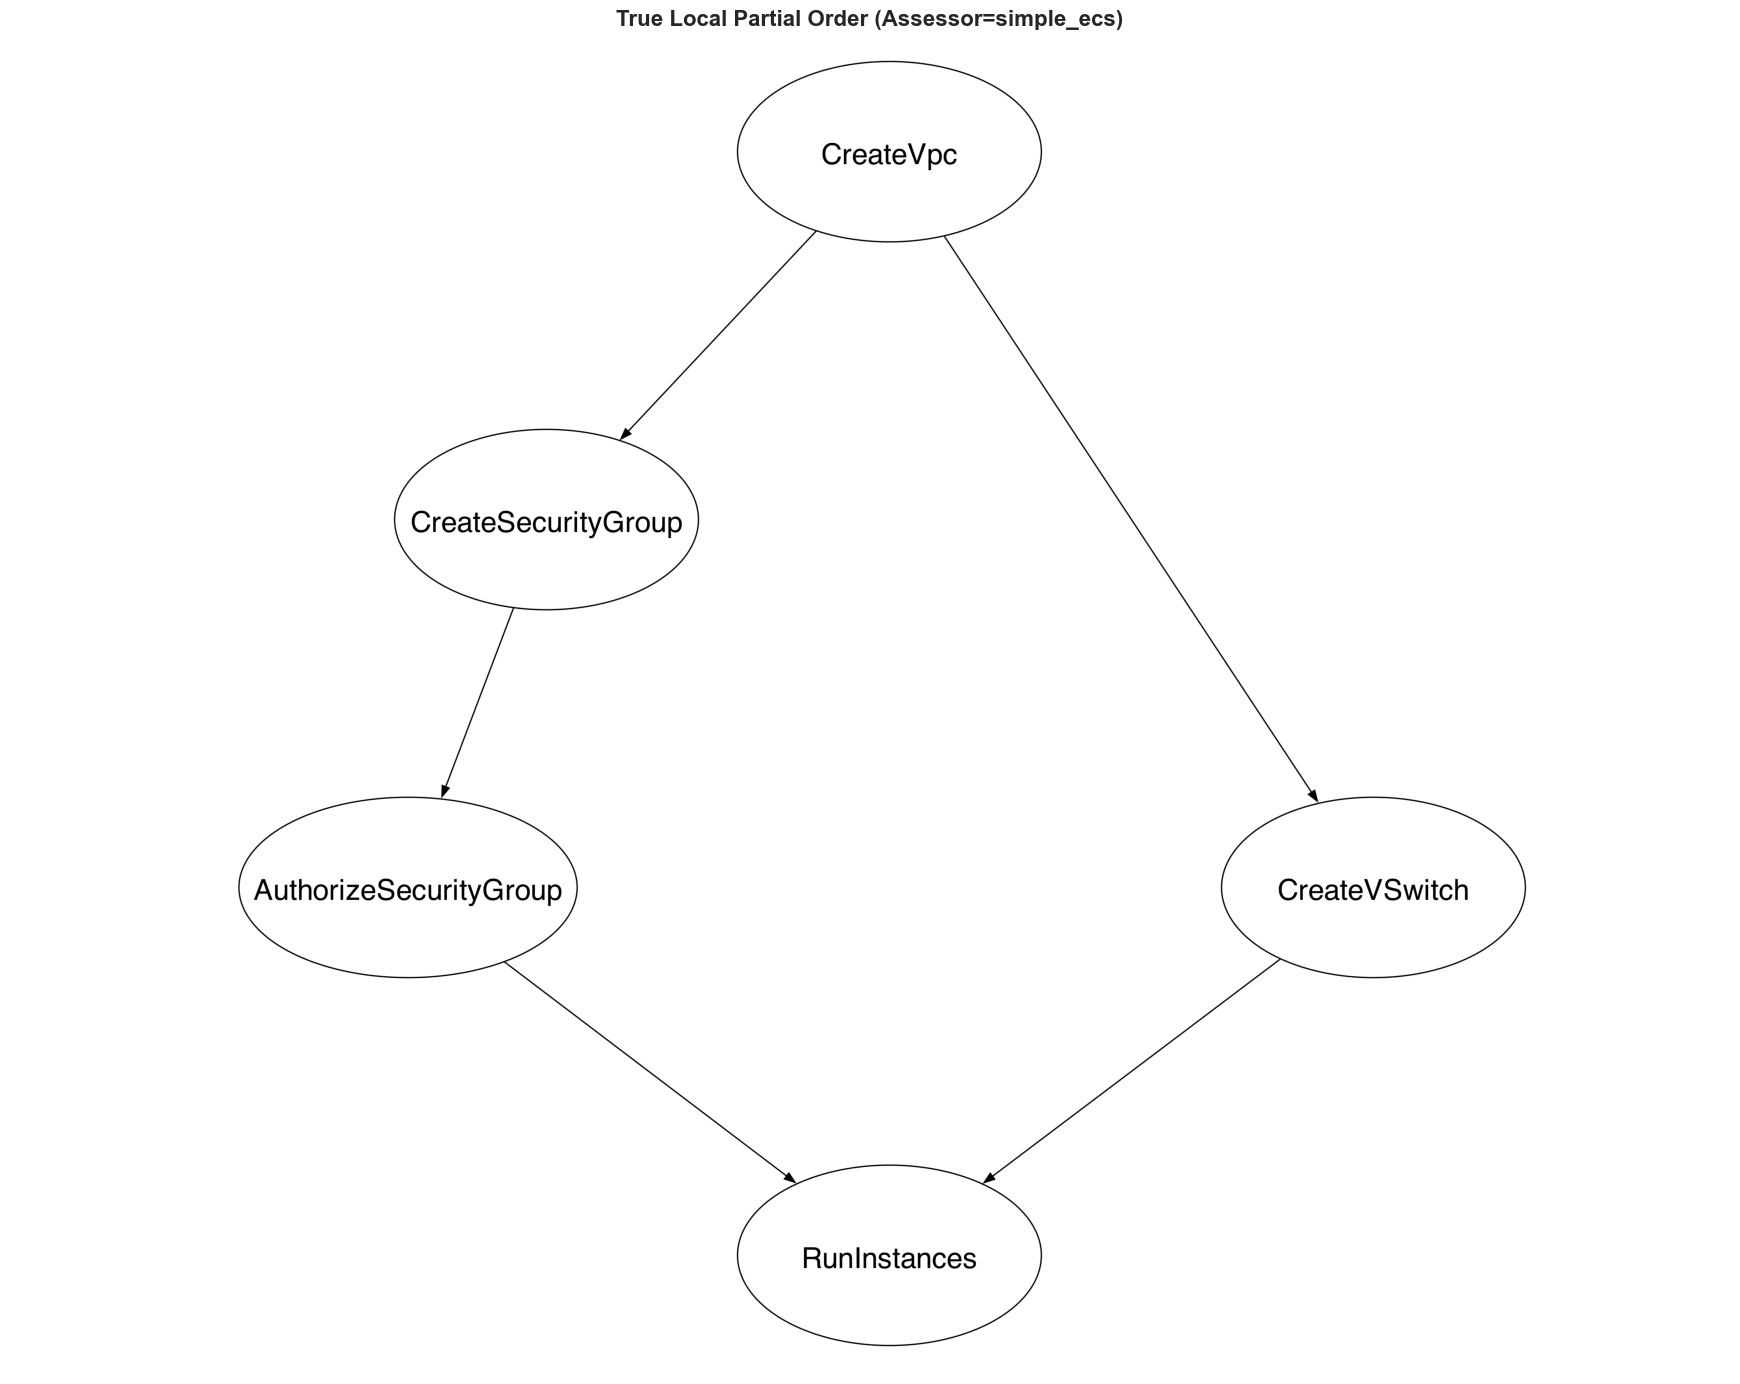

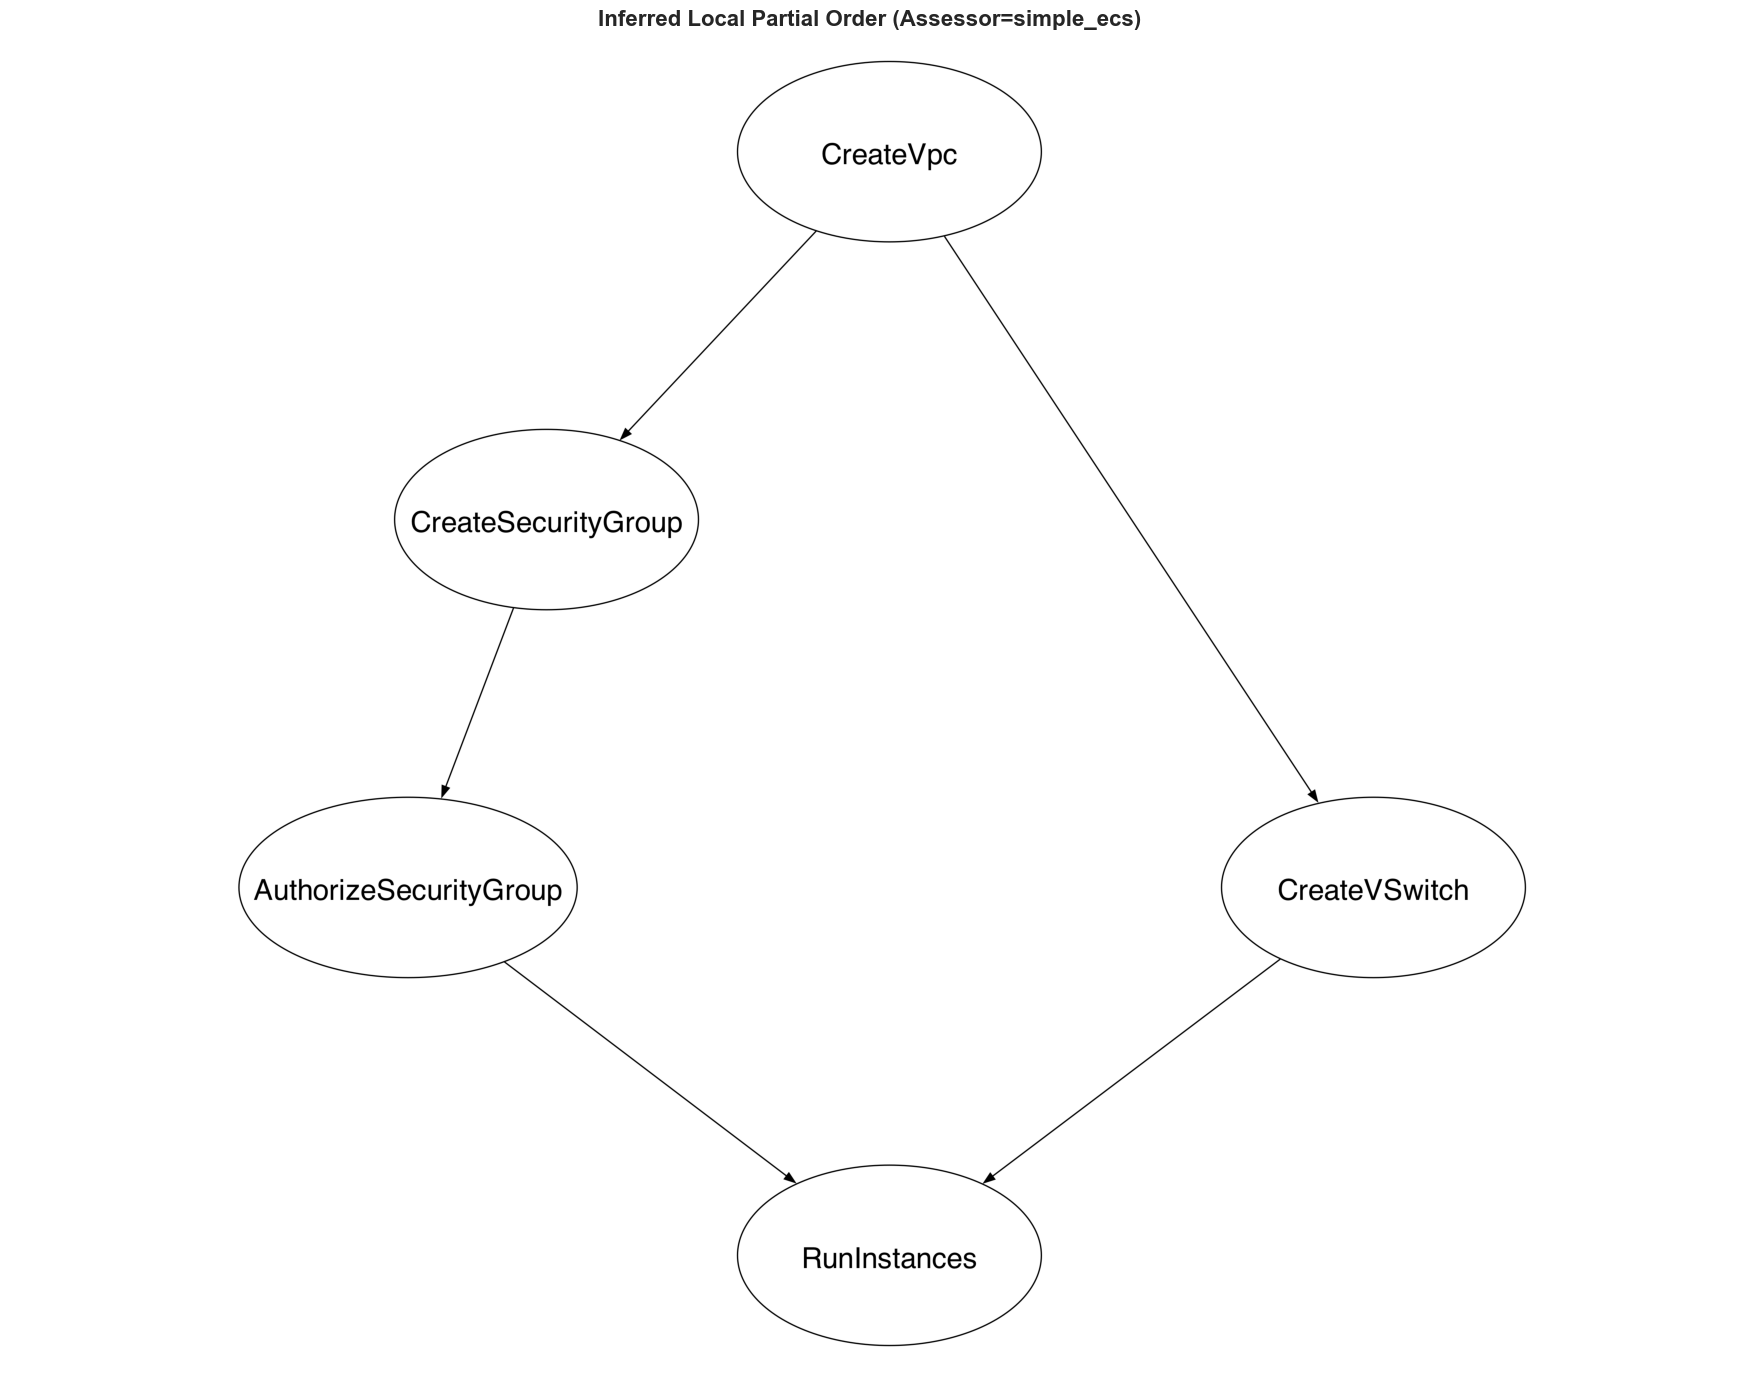


No missing edges for assessor simple_ecs.

No redundant edges for assessor simple_ecs.


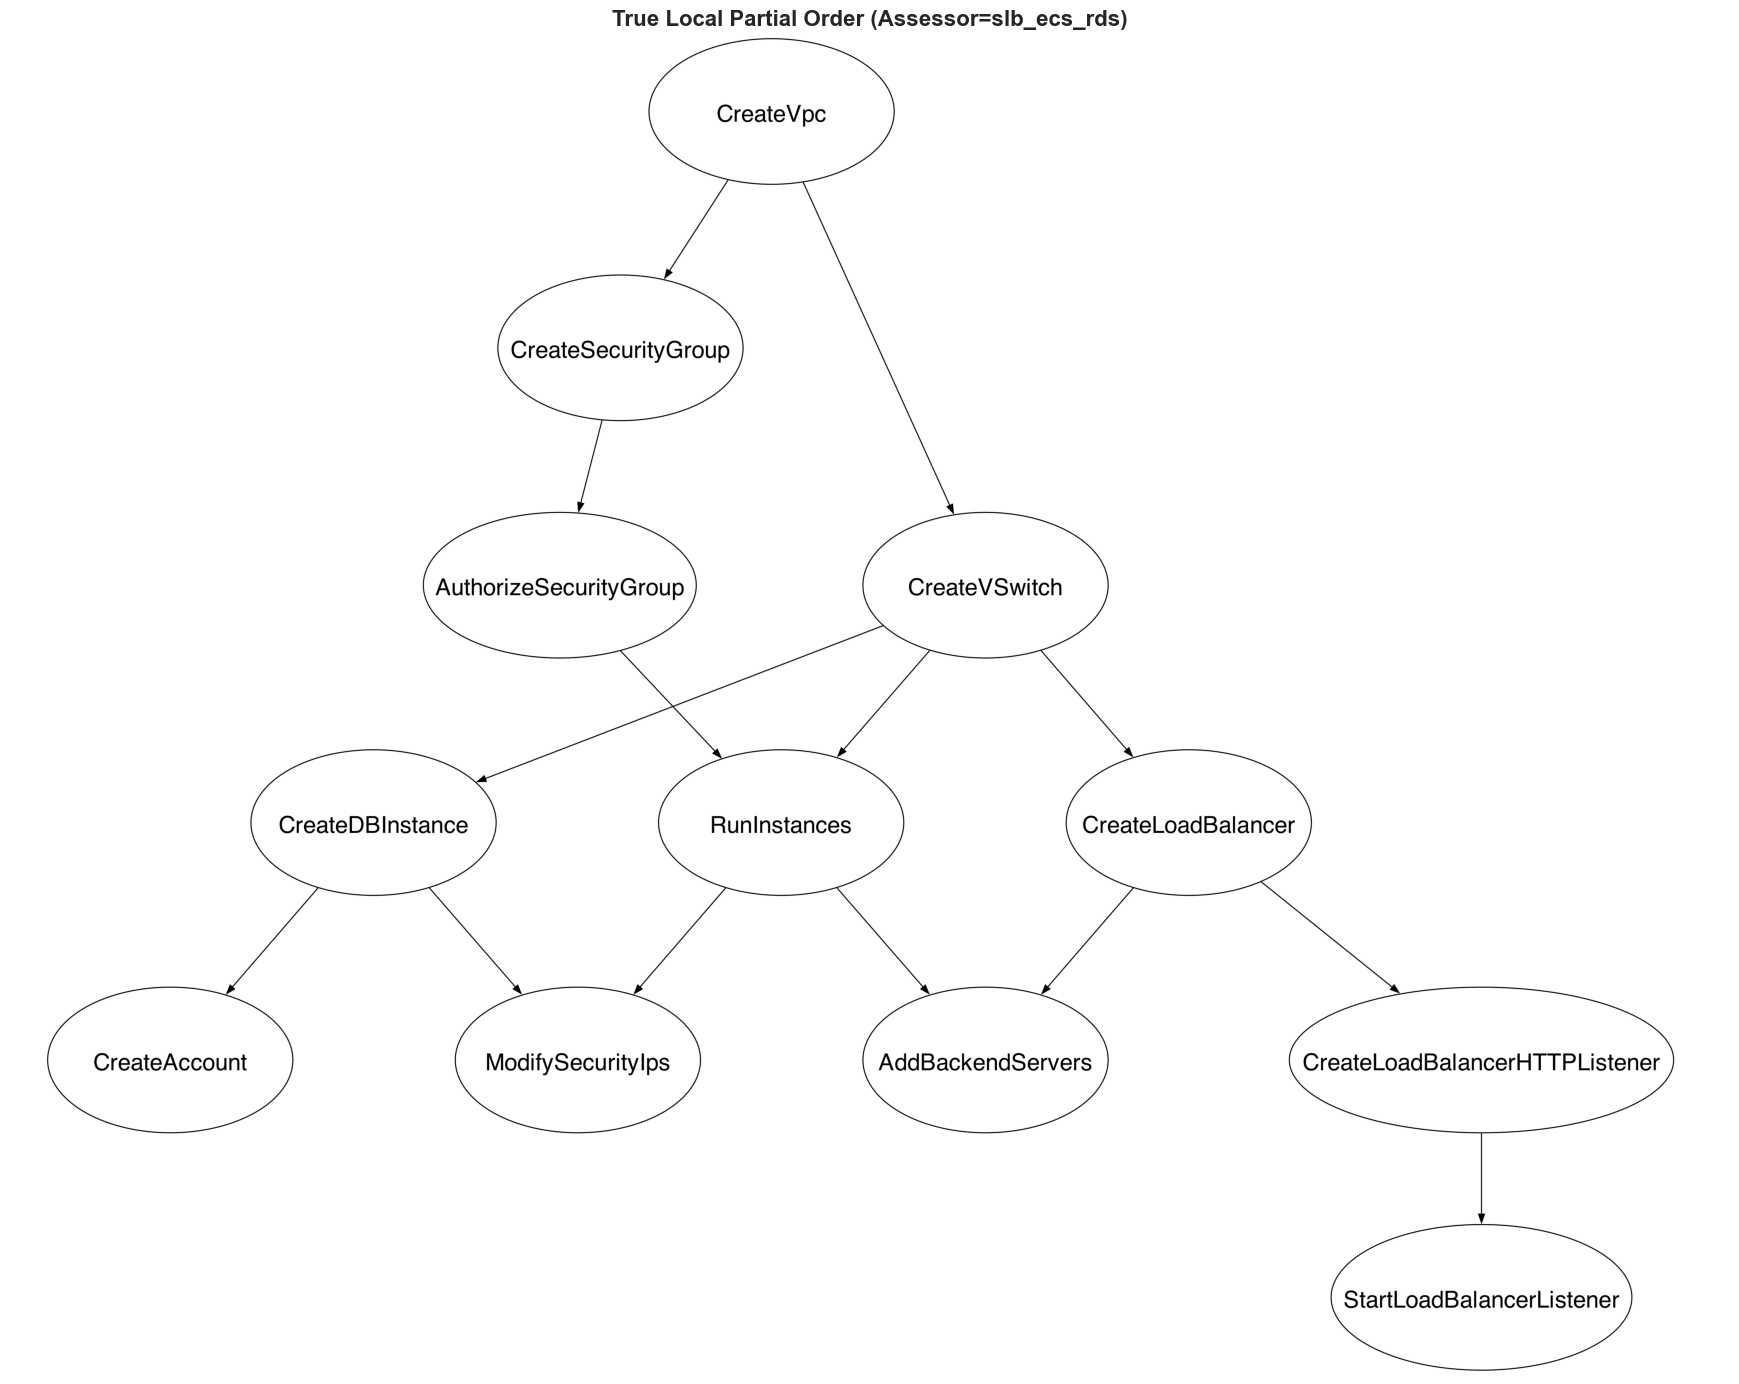

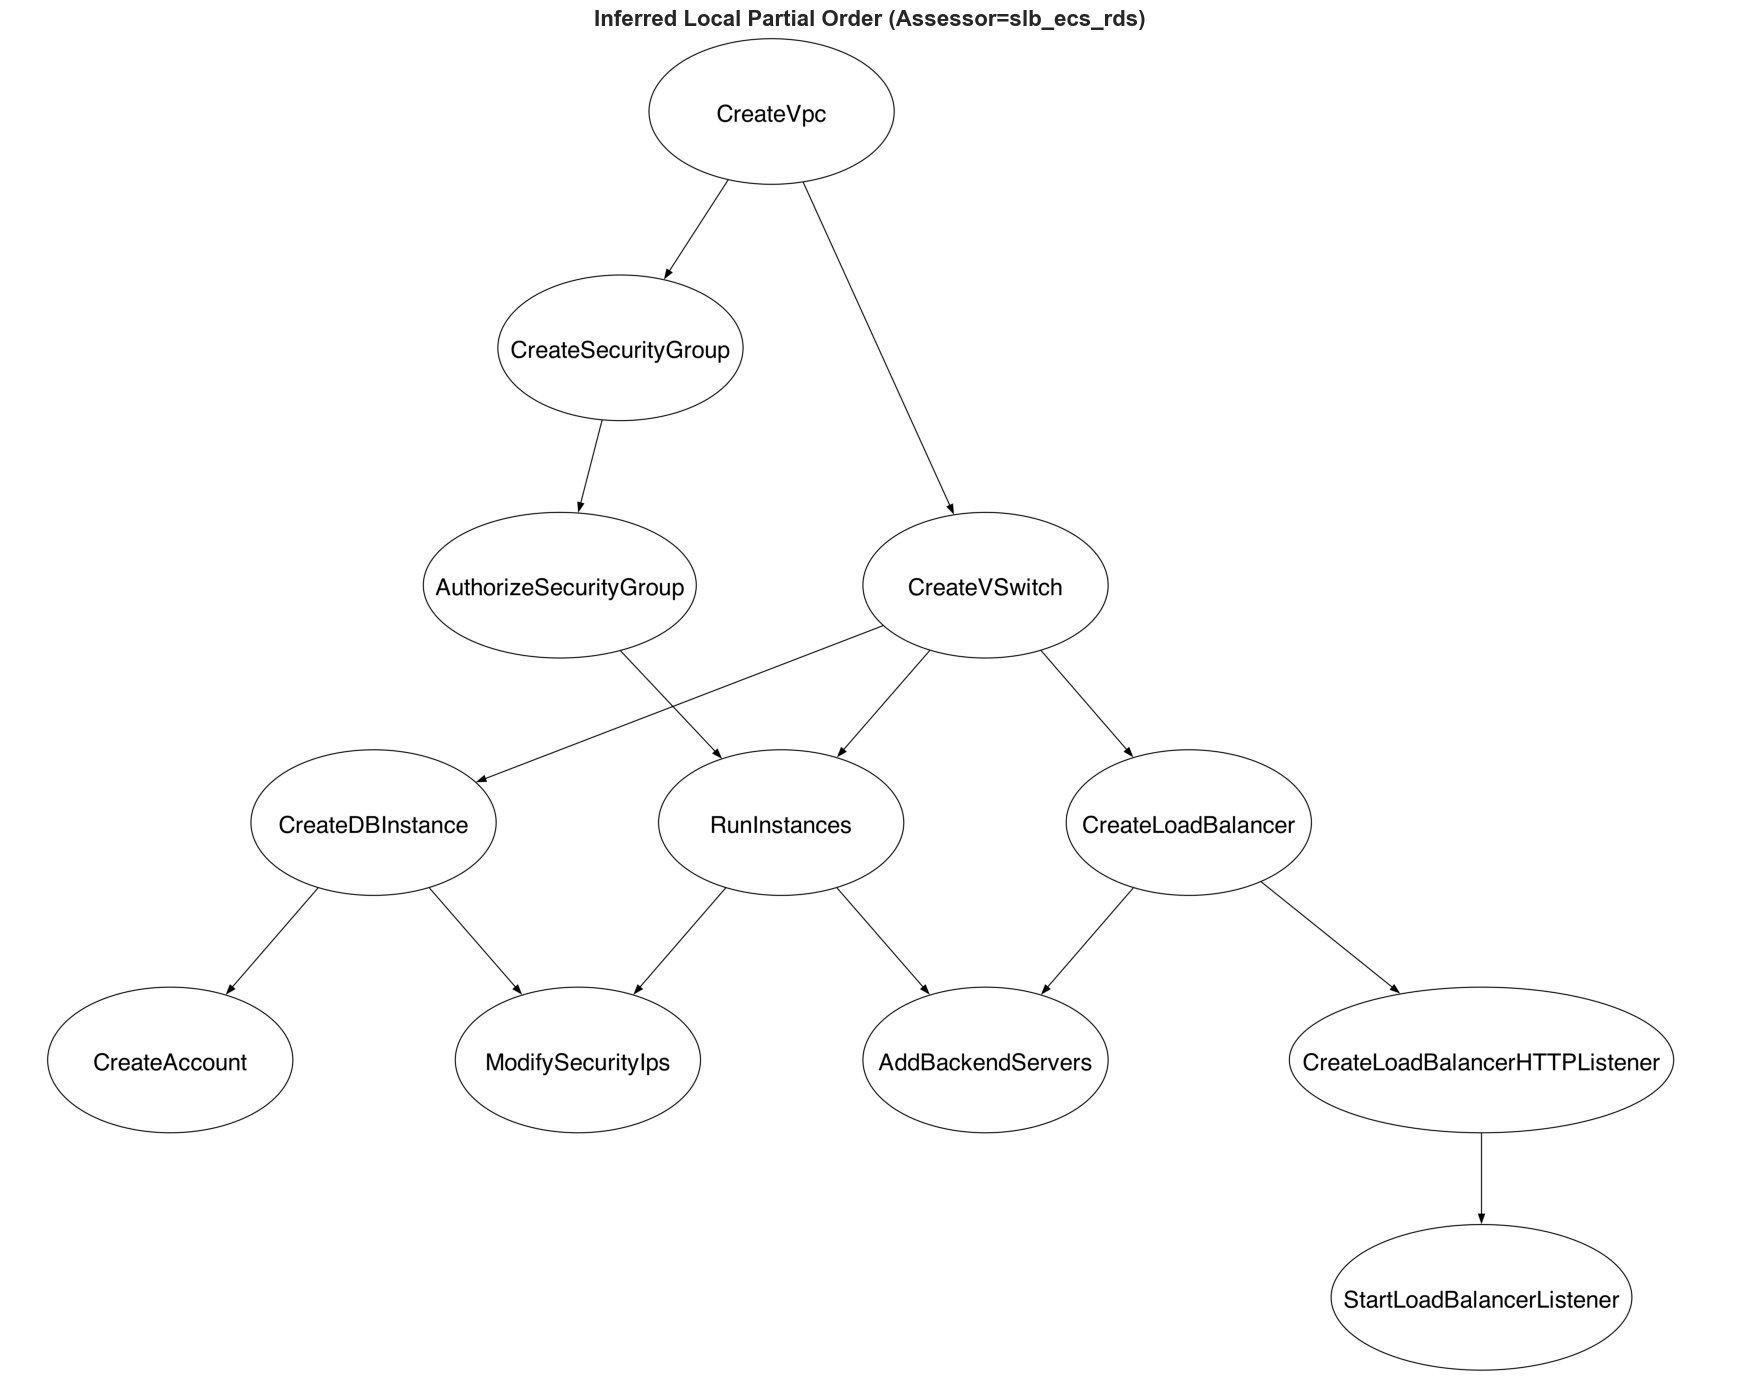


No missing edges for assessor slb_ecs_rds.

No redundant edges for assessor slb_ecs_rds.


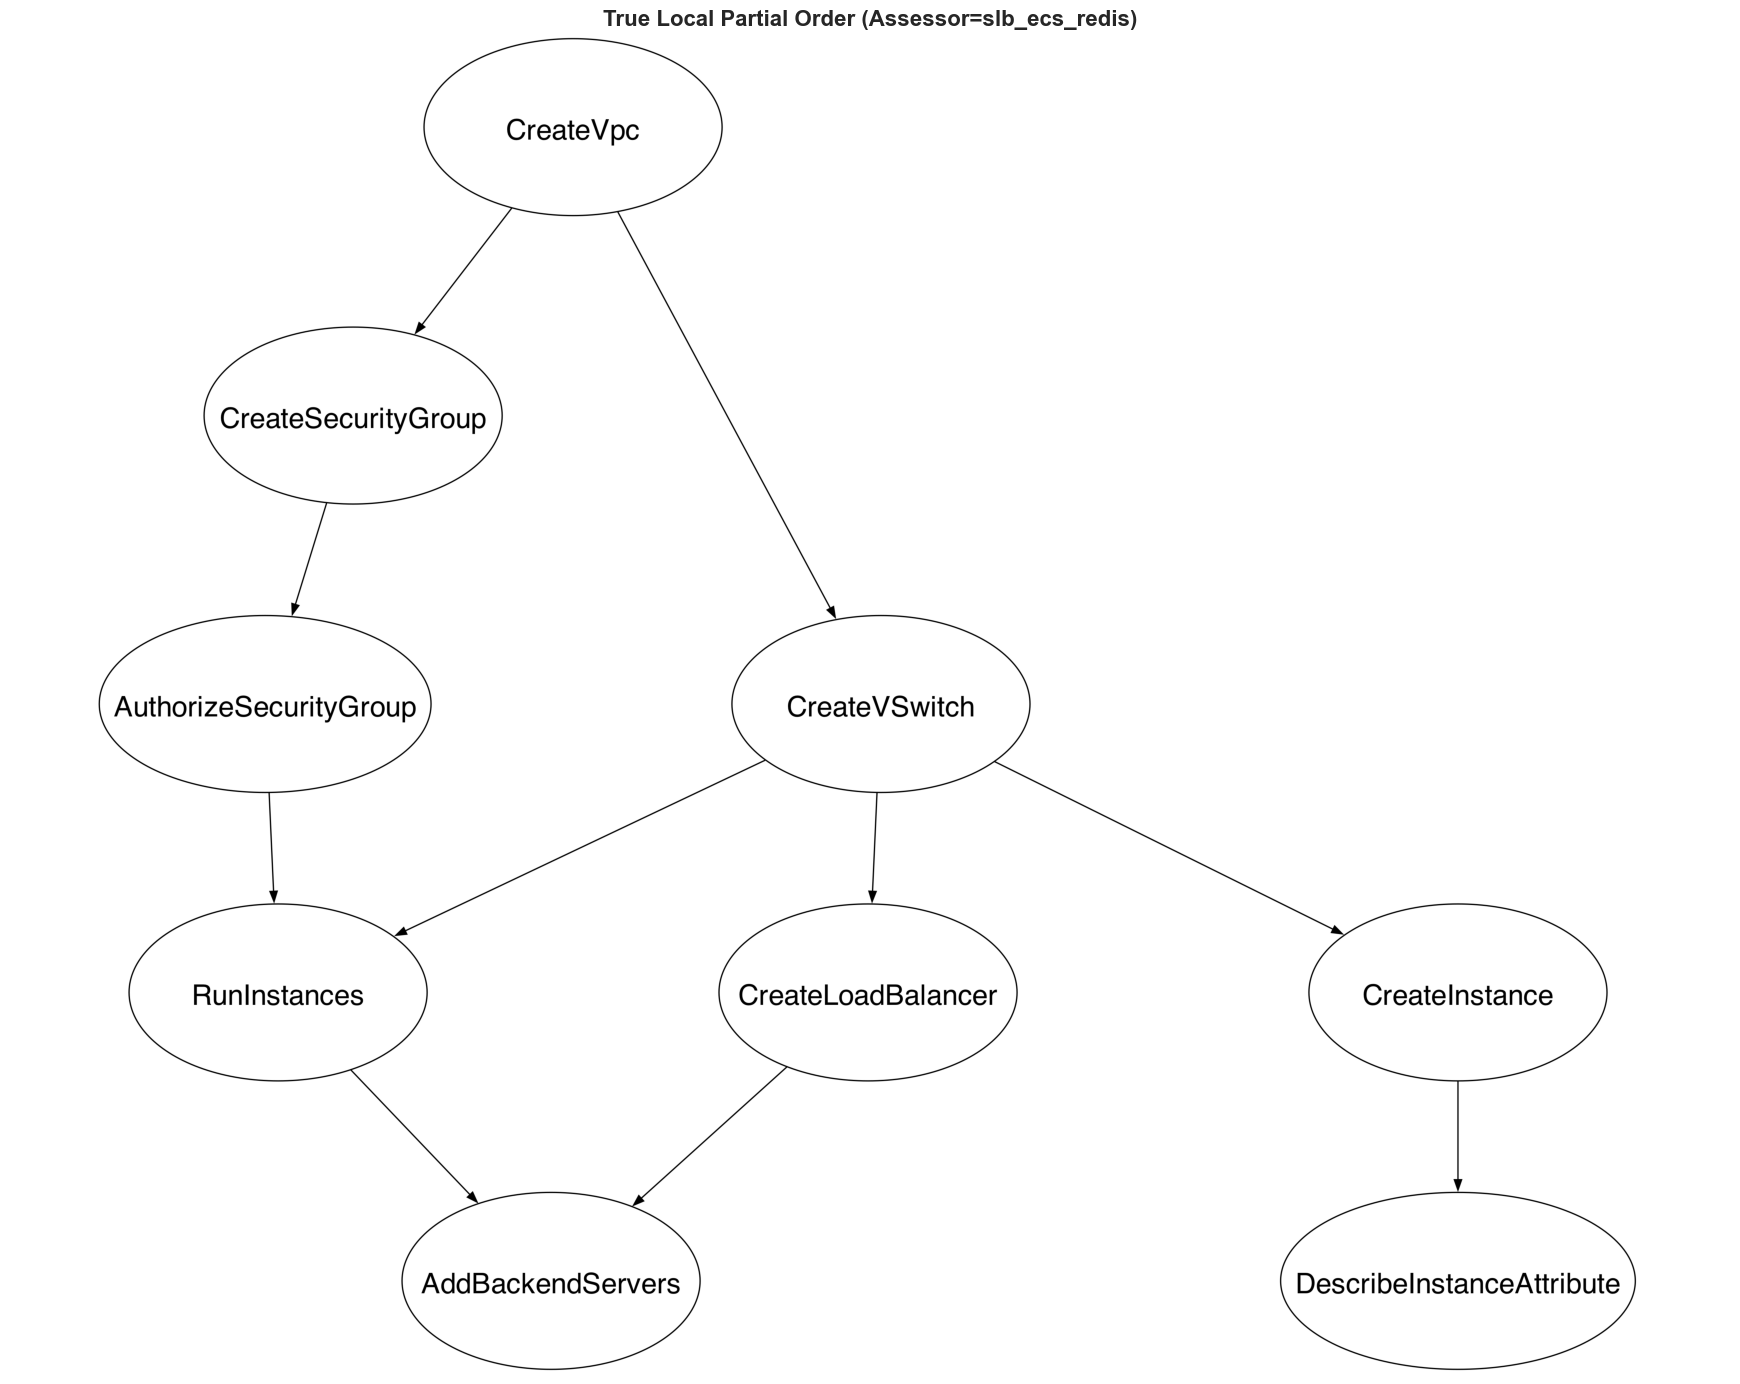

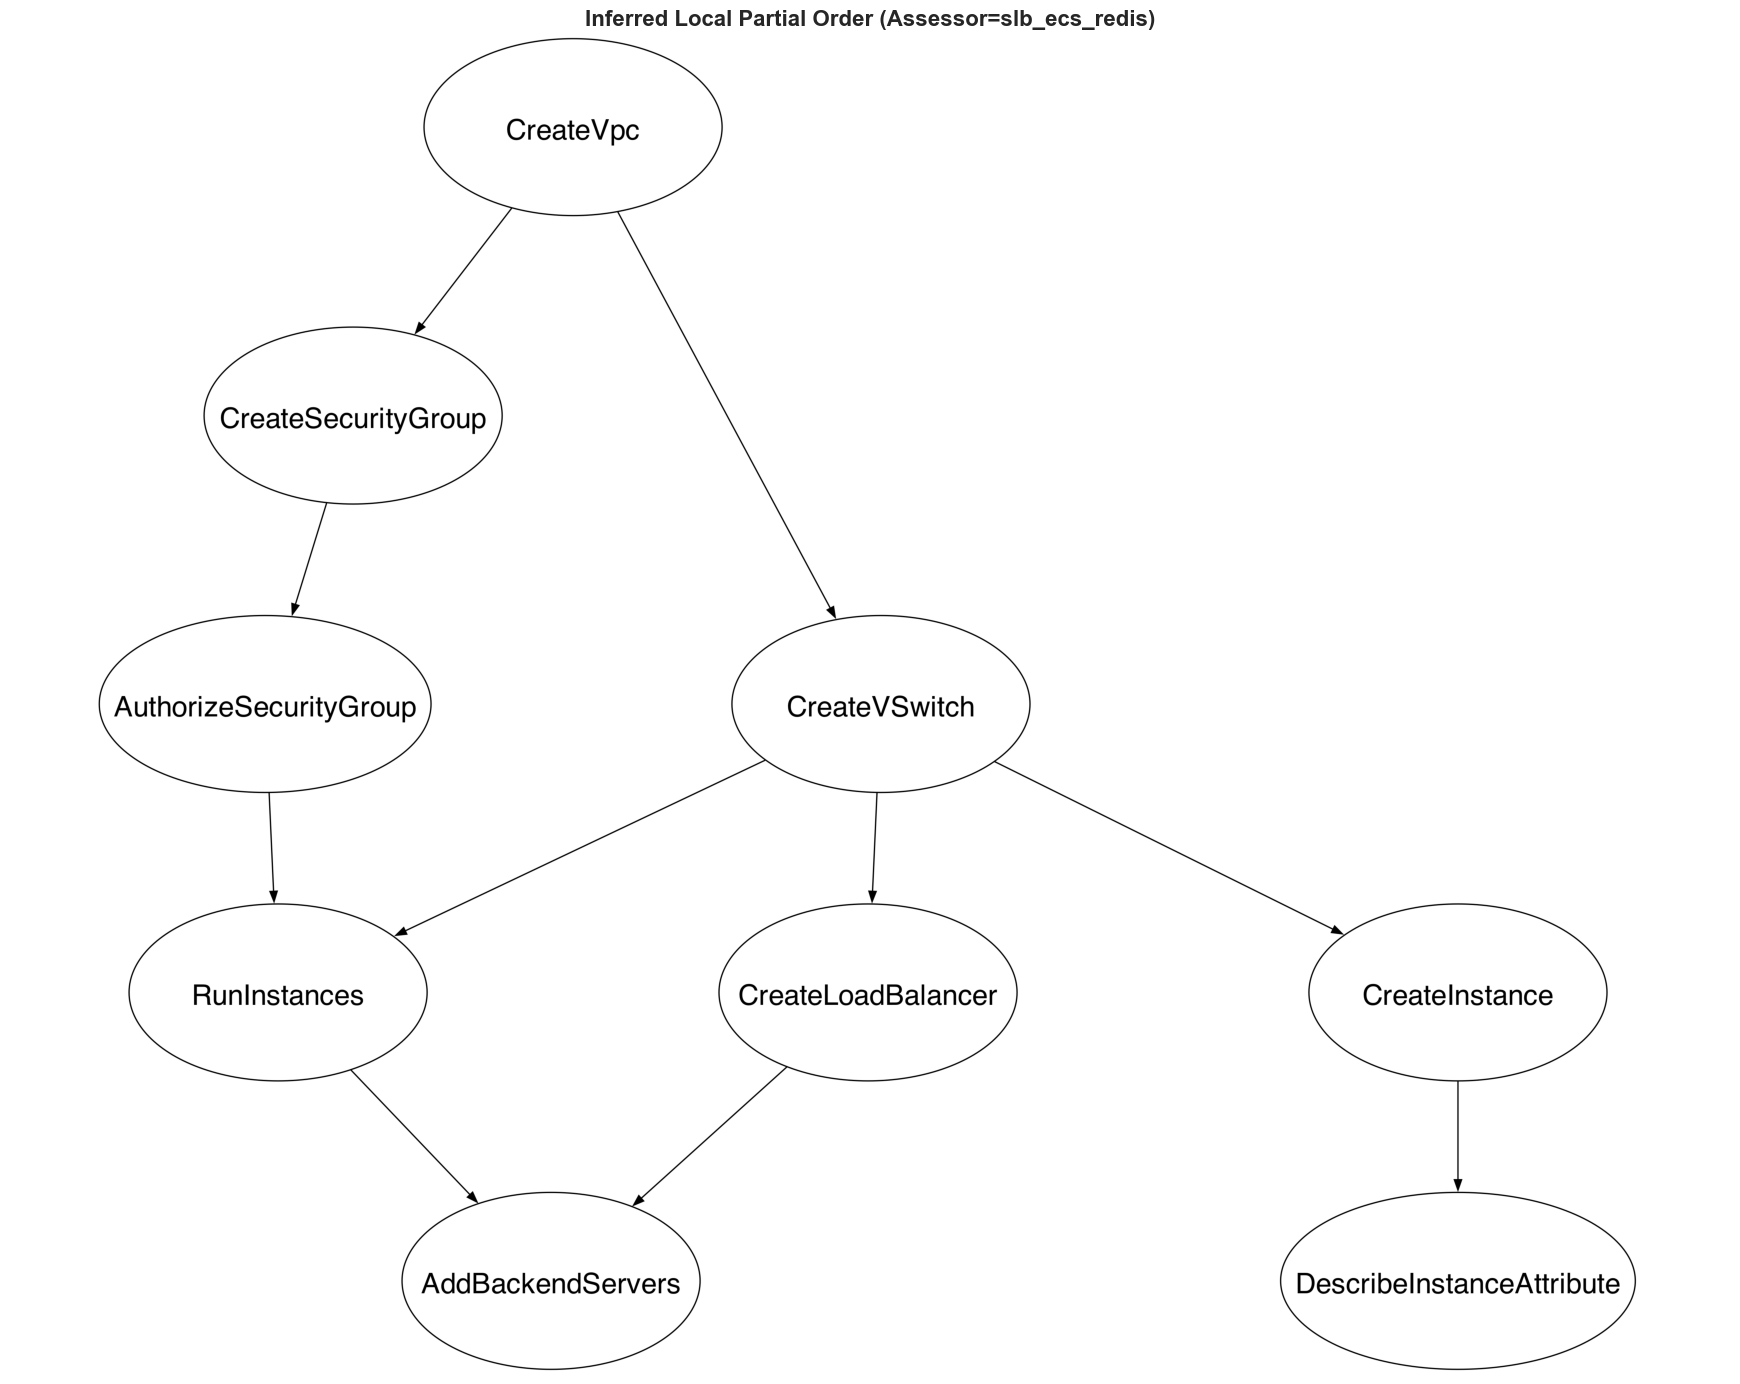


No missing edges for assessor slb_ecs_redis.

No redundant edges for assessor slb_ecs_redis.
Metrics by assessor:
dual_zone_ecs_slb: cover_F1=1.000  P=1.000  R=1.000  SHD=0
  crit_F1=1.000  P=1.000  R=1.000  Feas=1.000  Cov_crit=5/5 (1.000)
  Violations=0/13  Examples=[]
dual_zone_ecs_slb_rds: cover_F1=1.000  P=1.000  R=1.000  SHD=0
  crit_F1=1.000  P=1.000  R=1.000  Feas=0.958  Cov_crit=18/18 (1.000)
  Violations=1/24  Examples=[{'trace_idx': 6, 'trace_id': 'trace_T06_qwen-turbo_t0.7_20260104_140008_934362', 'length': 8}]
eip_slb_ecs: cover_F1=1.000  P=1.000  R=1.000  SHD=0
  crit_F1=1.000  P=1.000  R=1.000  Feas=1.000  Cov_crit=16/16 (1.000)
  Violations=0/17  Examples=[]
simple_ecs: cover_F1=1.000  P=1.000  R=1.000  SHD=0
  crit_F1=1.000  P=1.000  R=1.000  Feas=1.000  Cov_crit=2/2 (1.000)
  Violations=0/13  Examples=[]
slb_ecs_rds: cover_F1=1.000  P=1.000  R=1.000  SHD=0
  crit_F1=1.000  P=1.000  R=1.000  Feas=1.000  Cov_crit=32/32 (1.000)
  Violations=0/33  Examples=[]
slb_ecs_red

In [ ]:
from src.utils.po_fun_plot import PO_plot
from src.utils.hpo_model_evaluation import precision_recall, f1_score, structural_hamming_distance
from src.utils.po_fun import BasicUtils
import numpy as np

# Build posterior aggregated H if not already available
burn_in = int(len(mcmc_results["H_trace"]) * burn_in_fraction)
h_trace_k = mcmc_results["H_trace"][burn_in:]


def build_final_partial_orders(
    h_trace,
    *,
    method="threshold",
    threshold=0.3,
):
    if not h_trace:
        raise ValueError("Empty H_trace provided.")

    assessor_ids = list(h_trace[0].keys())
    final_H = {}

    for assessor in assessor_ids:
        mats = [iter_dict[assessor] for iter_dict in h_trace if assessor in iter_dict]
        if not mats:
            continue

        mats_arr = np.stack(mats, axis=0)
        _, n, _ = mats_arr.shape

        if method == "threshold":
            mean_mat = np.mean(mats_arr, axis=0)
            agg_mat = (mean_mat >= float(threshold)).astype(np.int8)
        elif method == "mode":
            counts_ij = (mats_arr > 0).sum(axis=0)
            counts_ji = counts_ij.T
            counts_inc = mats_arr.shape[0] - counts_ij - counts_ji

            agg_mat = np.zeros((n, n), dtype=np.int8)
            iu = np.triu_indices(n, 1)
            for i, j in zip(*iu):
                votes = {
                    (i, j): counts_ij[i, j],
                    (j, i): counts_ji[i, j],
                    None: counts_inc[i, j],
                }
                best = max(votes.items(), key=lambda kv: kv[1])[0]
                if best == (i, j):
                    agg_mat[i, j] = 1
                elif best == (j, i):
                    agg_mat[j, i] = 1
        else:
            raise ValueError(f"Unknown method '{method}'. Use 'mode' or 'threshold'.")

        np.fill_diagonal(agg_mat, 0)
        final_H[assessor] = BasicUtils.transitive_reduction(agg_mat.astype(int))

    return final_H


def _is_linear_extension_partial(order, closure):
    pos = {t: i for i, t in enumerate(order)}
    rows, cols = np.where(closure == 1)
    for i, j in zip(rows, cols):
        if i == j:
            continue
        if i in pos and j in pos and pos[i] >= pos[j]:
            return False
    return True


def _incomparable_pairs(closure):
    n = closure.shape[0]
    pairs = set()
    for i in range(n):
        for j in range(i + 1, n):
            if closure[i, j] or closure[j, i]:
                continue
            pairs.add((i, j))
    return pairs


def _critical_pair_coverage(orders, closure):
    pairs = _incomparable_pairs(closure)
    if not pairs:
        return 0, 0, 1.0

    seen = {}
    for order in orders:
        pos = {t: i for i, t in enumerate(order)}
        items = list(pos.keys())
        for i in range(len(items)):
            for j in range(i + 1, len(items)):
                a, b = items[i], items[j]
                pair = (a, b) if a < b else (b, a)
                if pair not in pairs:
                    continue
                u, v = pair
                mask = 1 if pos[u] < pos[v] else 2
                seen[pair] = seen.get(pair, 0) | mask

    covered = sum(1 for pair in pairs if seen.get(pair, 0) == 3)
    return covered, len(pairs), covered / max(1, len(pairs))


METHOD = "threshold"  # threshold | mode
THRESHOLD = 0.5
MAX_VIOLATIONS_TO_SHOW = 5

# Compute probability matrices (mean of posterior samples)
def build_probability_matrices(h_trace):
    """
    Compute mean probability matrices from MCMC trace.
    Returns dict mapping assessor_id -> probability matrix.
    """
    if not h_trace:
        raise ValueError("Empty H_trace provided.")
    
    assessor_ids = list(h_trace[0].keys())
    prob_matrices = {}
    
    for assessor in assessor_ids:
        mats = [iter_dict[assessor] for iter_dict in h_trace if assessor in iter_dict]
        if not mats:
            continue
        
        mats_arr = np.stack(mats, axis=0)
        # Compute mean probability (posterior mean)
        mean_prob = np.mean(mats_arr, axis=0)
        np.fill_diagonal(mean_prob, 0)  # diagonal should be 0
        prob_matrices[assessor] = mean_prob
    
    return prob_matrices

# Build probability matrices
H_probabilities = build_probability_matrices(h_trace_k)

# Also build final_H_mode for evaluation (if needed)
if "final_H_mode" not in globals() or not final_H_mode:
    final_H_mode = build_final_partial_orders(
        h_trace_k,
        method=METHOD,
        threshold=THRESHOLD,
    )

# Print probability matrices
print("Probability matrices (posterior means):")
print("="*60)
for assessor_id, prob_mat in H_probabilities.items():
    print(f"\n{assessor_id}:")
    print(f"Shape: {prob_mat.shape}")
    print("\nMatrix:")
    print(prob_mat)
    print(f"\nNon-zero entries: {np.count_nonzero(prob_mat)}")
    print(f"Max probability: {prob_mat.max():.4f}")
    print(f"Min probability: {prob_mat[prob_mat > 0].min() if np.any(prob_mat > 0) else 0:.4f}")
    print(f"Mean probability (non-zero): {prob_mat[prob_mat > 0].mean() if np.any(prob_mat > 0) else 0:.4f}")
    print("-"*60)

index_to_item_local_dict = {
    a: {i: M_a_dict[a][i] for i in range(len(M_a_dict[a]))}
    for a in M_a_dict.keys()
}

Ma_labels_dict = {
    a: scenario_data[a]["task_ids"]
    for a in M_a_dict.keys()
}

metrics_by_assessor = {}

for a in M_a_dict.keys():
    h_true_closure = scenario_data[a]["true_closure"]
    h_true_cover = scenario_data[a]["true_cover"]
    h_inferred = final_H_mode[a]

    PO_plot.compare_and_visualize_assessor(
        a,
        Ma_labels_dict[a],
        h_true_closure,
        h_inferred,
        index_to_item_local_dict[a],
        do_transitive_reduction=True,
    )

    h_eval = h_inferred.copy()
    np.fill_diagonal(h_eval, 0)

    # (i) Hasse-edge recovery (cover edges)
    shd = structural_hamming_distance(h_true_cover, h_eval)
    precision, recall = precision_recall(h_true_cover, h_eval)
    cover_f1 = f1_score(precision, recall)

    # (ii) Comparability recovery (critical pairs / incomparability)
    inferred_closure = BasicUtils.transitive_closure(h_eval.astype(np.int8))
    true_pairs = _incomparable_pairs(h_true_closure)
    inferred_pairs = _incomparable_pairs(inferred_closure)
    inter = true_pairs & inferred_pairs
    crit_precision = len(inter) / max(1, len(inferred_pairs))
    crit_recall = len(inter) / max(1, len(true_pairs))
    crit_f1 = f1_score(crit_precision, crit_recall)

    # Feasibility of inferred structure + violations
    orders_local = orders_local_by_assessor.get(a, [])
    invalid = [
        idx for idx, order in enumerate(orders_local)
        if not _is_linear_extension_partial(order, inferred_closure)
    ]
    feas = 1.0 - (len(invalid) / max(1, len(orders_local)))

    meta = trace_meta_by_assessor.get(a, [])
    invalid_examples = []
    for idx in invalid[:MAX_VIOLATIONS_TO_SHOW]:
        trace_id = meta[idx].get("trace_id") if idx < len(meta) else None
        invalid_examples.append({
            "trace_idx": idx,
            "trace_id": trace_id,
            "length": len(orders_local[idx]),
        })

    # Data adequacy / identifiability (pre-MCMC) from true poset
    covered, total_pairs, cov_frac = _critical_pair_coverage(orders_local, h_true_closure)

    metrics_by_assessor[a] = {
        "cover_precision": precision,
        "cover_recall": recall,
        "cover_f1": cover_f1,
        "shd": shd,
        "crit_precision": crit_precision,
        "crit_recall": crit_recall,
        "crit_f1": crit_f1,
        "feas": feas,
        "crit_pairs": total_pairs,
        "crit_covered": covered,
        "crit_cov": cov_frac,
        "violations": len(invalid),
        "violation_examples": invalid_examples,
        "num_traces": len(orders_local),
    }

print("Metrics by assessor:")
for a, m in metrics_by_assessor.items():
    print(
        f"{a}: cover_F1={m['cover_f1']:.3f}  P={m['cover_precision']:.3f}  R={m['cover_recall']:.3f}  SHD={m['shd']}"
    )
    print(
        f"  crit_F1={m['crit_f1']:.3f}  P={m['crit_precision']:.3f}  R={m['crit_recall']:.3f}"
        f"  Feas={m['feas']:.3f}  Cov_crit={m['crit_covered']}/{m['crit_pairs']} ({m['crit_cov']:.3f})"
    )
    print(
        f"  Violations={m['violations']}/{m['num_traces']}  Examples={m['violation_examples']}"
    )


# Baseline comparison 
We compare two baselines 

In [ ]:
def baseline_and(orders_local: List[List[int]], n: int) -> np.ndarray:
    """
    Edge i->j is included iff *every* trace that contains both i and j has i before j.
    Returns cover (transitive reduction of closure).
    """
    before_ok = np.ones((n, n), dtype=bool)
    seen = np.zeros((n, n), dtype=int)

    for o in orders_local:
        pos = {a: t for t, a in enumerate(o)}
        items = list(pos.keys())
        for i in items:
            for j in items:
                if i == j:
                    continue
                seen[i, j] += 1
                if pos[i] >= pos[j]:
                    before_ok[i, j] = False

    adj = np.zeros((n, n), dtype=np.int8)
    for i in range(n):
        for j in range(n):
            if i != j and seen[i, j] > 0 and before_ok[i, j]:
                adj[i, j] = 1

    closure = BasicUtils.transitive_closure(adj.astype(np.int8))
    cover = BasicUtils.transitive_reduction_optimized(closure.astype(np.int8))
    return cover.astype(np.int8)

def baseline_majority(orders_local: List[List[int]], n: int, thr: float = 0.5) -> np.ndarray:
    """
    For each unordered pair {i,j}, orient it in the direction that wins by majority
    (and exceeds threshold thr), then break cycles by removing weakest margins.
    Returns cover.
    """
    counts = np.zeros((n, n), dtype=int)
    totals = np.zeros((n, n), dtype=int)

    for o in orders_local:
        pos = {a: t for t, a in enumerate(o)}
        items = list(pos.keys())
        for i in items:
            for j in items:
                if i == j:
                    continue
                totals[i, j] += 1
                if pos[i] < pos[j]:
                    counts[i, j] += 1

    p = np.where(totals > 0, counts / np.maximum(1, totals), 0.0)

    adj = np.zeros((n, n), dtype=np.int8)
    margin = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i + 1, n):
            if totals[i, j] == 0 and totals[j, i] == 0:
                continue
            pij = p[i, j]
            pji = p[j, i]
            if pij > thr and pij > pji:
                adj[i, j] = 1
                margin[i, j] = abs(pij - 0.5)
            elif pji > thr and pji > pij:
                adj[j, i] = 1
                margin[j, i] = abs(pji - 0.5)

    # cycle finding
    def find_cycle(A: np.ndarray):
        n_ = A.shape[0]
        state = [0] * n_
        parent = [-1] * n_

        def dfs(u: int):
            state[u] = 1
            for v in np.where(A[u] == 1)[0]:
                v = int(v)
                if state[v] == 0:
                    parent[v] = u
                    cyc = dfs(v)
                    if cyc is not None:
                        return cyc
                elif state[v] == 1:
                    # back edge u->v
                    cycle = [v]
                    cur = u
                    while cur != v and cur != -1:
                        cycle.append(cur)
                        cur = parent[cur]
                    cycle.append(v)
                    cycle.reverse()
                    return cycle
            state[u] = 2
            return None

        for s in range(n_):
            if state[s] == 0:
                cyc = dfs(s)
                if cyc is not None:
                    return cyc
        return None

    # break cycles by removing weakest edge on a cycle
    while True:
        cyc = find_cycle(adj)
        if cyc is None:
            break
        weakest = None
        weakest_m = float("inf")
        for u, v in zip(cyc[:-1], cyc[1:]):
            if adj[u, v] == 1 and margin[u, v] < weakest_m:
                weakest_m = margin[u, v]
                weakest = (u, v)
        if weakest is None:
            break
        adj[weakest[0], weakest[1]] = 0

    closure = BasicUtils.transitive_closure(adj.astype(np.int8))
    cover = BasicUtils.transitive_reduction_optimized(closure.astype(np.int8))
    return cover.astype(np.int8)

def evaluate_baseline(H_true: np.ndarray, H_hat: np.ndarray) -> Dict[str, float]:
    p, r = precision_recall(H_true, H_hat)
    return dict(
        precision=float(p),
        recall=float(r),
        f1=float(f1_score(p, r)),
        shd=float(structural_hamming_distance(H_true, H_hat)),
    )


In [ ]:
import pandas as pd

rows = []

for sid in assessors:
    info = scenario_data[sid]
    true_cover = info["true_cover"]
    true_closure = info["true_closure"]
    n = len(info["task_ids"])

    orders_local = orders_local_by_assessor.get(sid, [])
    
    if not orders_local:
        print(f"  {sid}: no traces available; skipping")
        continue

    # Use all available orders (no CP target filtering needed)
    sampled_local = orders_local

    and_cover = baseline_and(sampled_local, n)
    maj_cover = baseline_majority(sampled_local, n)

    met_and = evaluate_baseline(true_cover, and_cover)
    met_maj = evaluate_baseline(true_cover, maj_cover)

    print(f"  {sid}: traces={len(sampled_local)}  "
            f"AND_f1={met_and['f1']:.3f}  MAJ_f1={met_maj['f1']:.3f}")

    # Add baseline results to DataFrame
    rows.append(dict(
        scenario=sid,
        method="baseline_and",
        num_traces=len(sampled_local),
        **met_and
    ))
    rows.append(dict(
        scenario=sid,
        method="baseline_majority",
        num_traces=len(sampled_local),
        **met_maj
    ))

baseline_df = pd.DataFrame(rows)
baseline_df.sort_values(["scenario", "method"], inplace=True)
baseline_df


  dual_zone_ecs_slb: traces=13  AND_f1=1.000  MAJ_f1=0.571
  dual_zone_ecs_slb_rds: traces=24  AND_f1=0.880  MAJ_f1=0.381
  eip_slb_ecs: traces=17  AND_f1=1.000  MAJ_f1=0.333
  simple_ecs: traces=13  AND_f1=1.000  MAJ_f1=0.667
  slb_ecs_rds: traces=33  AND_f1=1.000  MAJ_f1=0.240
  slb_ecs_redis: traces=30  AND_f1=0.900  MAJ_f1=0.222


,scenario,method,num_traces,precision,recall,f1,shd
0,dual_zone_ecs_slb,baseline_and,13,1.000000,1.000000,1.000000,0.0
1,dual_zone_ecs_slb,baseline_majority,13,0.666667,0.500000,0.571429,6.0
2,dual_zone_ecs_slb_rds,baseline_and,24,0.846154,0.916667,0.880000,3.0
3,dual_zone_ecs_slb_rds,baseline_majority,24,0.444444,0.333333,0.380952,13.0
4,eip_slb_ecs,baseline_and,17,1.000000,1.000000,1.000000,0.0
5,eip_slb_ecs,baseline_majority,17,0.375000,0.300000,0.333333,12.0
6,simple_ecs,baseline_and,13,1.000000,1.000000,1.000000,0.0
7,simple_ecs,baseline_majority,13,0.750000,0.600000,0.666667,3.0
8,slb_ecs_rds,baseline_and,33,1.000000,1.000000,1.000000,0.0
9,slb_ecs_rds,baseline_majority,33,0.272727,0.214286,0.240000,19.0
